# **🔥 Clasificación de perfiles de Burnout del desarrollador. <br>Modelos no supervisados | K-Means & DBSCAN |**

El notebook trabaja con aprendizaje no supervisado. Eso significa que el modelo no aprende usando una respuesta correcta, sino que busca patrones ocultos en los datos.
En este caso, el objetivo es agrupar desarrolladores según variables de comportamiento y hábitos: carga laboral, horas de trabajo, calidad del sueño, consumo de cafeína y producción de errores.
`stress_level` se analiza en el Paso 4 y se excluye por constituir una codificación
determinista del target.

##La idea central es:

**“Queremos descubrir perfiles de burnout de desarrolladores sin decirle al modelo quién tiene burnout alto, medio o bajo”.**

**Objetivo:** Descubrir perfiles latentes a partir de las *causas* del burnout (horas, estrés), no de la etiqueta resultante.

Por eso se excluye burnout_level.

### **🗂️ Fuente**
- [Developer Burnout Prediction Dataset — Kaggle](https://www.kaggle.com/datasets/asifxzaman/developer-burnout-prediction-dataset7000-samples)  
- **Registros:** 7,000  
- **Variables:** 12

### **📋 Consideraciones:**
| # | Consideración | Justificación |
|---|---|---|
| 1 | **`burnout_level` excluida** | Es la variable TARGET — incluirla sería hacer trampa |
| 2 | **Tratamiento completo de NaN** | Mediana para variables numéricas (estrategia correcta dado que el espacio final del modelo no contiene categóricas) + visualización |
| 3 | **Rango k ampliado a 2–12** | Análisis con 4 métricas + ranking combinado |



# **📦 1 - Importación de librerías**

## 📋 Herramientas cargadas:

| # | Destinada a | Librería |
|---|---|---|
| 1 | **manejar datos:** | pandas, numpy |
| 2 | **graficar:** | matplotlib, seaborn, plotly |
| 3 | **preparar datos:** | SimpleImputer, ColumnTransformer, RobustScaler, StandardScaler, OneHotEncoder (incluido por compatibilidad con datasets que contengan categóricas), shapiro (test de normalidad en Paso 5B) |
| 4 | **aplicar modelos:** | KMeans, DBSCAN |
| 5 | **reducir dimensiones:** | PCA, t-SNE |
| 6 | **evaluar clusters:** | silhouette_score, davies_bouldin_score, calinski_harabasz_score |
| 7 | **diagnóstico estadístico:** | scipy.stats.shapiro (test de normalidad en Paso 5C) |
| 8 | **visualizar NaN:** | missingno |

In [55]:
# PASO 1: IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px

try:
    import missingno as msno
except ImportError:
    !pip install missingno -q
    import missingno as msno

# 🆕 OneHotEncoder + ColumnTransformer reemplazan LabelEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
# OneHotEncoder incluido en el pipeline por compatibilidad general;
# el espacio final de este dataset no contiene variables categóricas
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score)
from collections import Counter
from scipy.stats import shapiro   # 🆕 Test normalidad

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('✅ Librerías cargadas (v3 mejorado).')

✅ Librerías cargadas (v3 mejorado).


# **📂 2 - Carga de dataset desde Google Drive**

## El notebook carga el archivo: developer_burnout_dataset.csv

**Luego muestra:**
* número de filas
* número de columnas
* nombres de variables
* tipos de datos
* primeras filas del dataset

Esto sirve para entender con qué información vamos a trabajar.

> ⚙️ **Nota de entorno:** la ruta de carga apunta a Google Drive.
> Ajustar `FILE_PATH` si el archivo está en una ubicación diferente.

In [56]:
# PASO 2: CARGA DE DATOS
from google.colab import drive
drive.mount('/content/drive')

# ⚙️ AJUSTAR esta ruta según tu entorno antes de ejecutar
FILE_PATH = '/content/drive/My Drive/MachineLearning/Semana3/developer_burnout_dataset.csv'
df_raw = pd.read_csv(FILE_PATH)

print(f'✅ Dataset: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
print('\nColumnas:')
for i, col in enumerate(df_raw.columns):
    print(f'  {i+1:2d}. {col:<35} [{df_raw[col].dtype}]')
display(df_raw.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset: 7000 filas × 12 columnas

Columnas:
   1. age                                 [float64]
   2. experience_years                    [float64]
   3. daily_work_hours                    [float64]
   4. sleep_hours                         [float64]
   5. caffeine_intake                     [float64]
   6. bugs_per_day                        [float64]
   7. commits_per_day                     [float64]
   8. meetings_per_day                    [float64]
   9. screen_time                         [float64]
  10. exercise_hours                      [float64]
  11. stress_level                        [float64]
  12. burnout_level                       [object]


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


## 🔍 3: Análisis exploratorio de datos (EDA)

Se analiza la estructura del dataset antes de tomar decisiones de
modelado: estadísticas descriptivas, valores nulos, distribución de
variables y correlaciones.

### Naturaleza de las variables

El dataset tiene dos grupos con comportamiento distinto en los histogramas:

| Tipo | Variables |
|---|---|
| Continuas | `daily_work_hours`, `sleep_hours`, `screen_time`, `exercise_hours`, `stress_level` |
| Conteo discreto entero | `caffeine_intake`, `bugs_per_day`, `commits_per_day`, `meetings_per_day`, `age`, `experience_years` |

Las variables discretas producen histogramas escalonados — esto es
correcto, no un error de los datos.

### Señal de dataset sintético

Tres señales indican que el dataset fue generado artificialmente:
skewness cercano a cero en todas las variables (máximo 0.06),
cero outliers IQR en las 11 columnas, y NaN distribuidos
uniformemente al 2% en cada columna. Esto no invalida el análisis
pero significa que en datos reales los clusters serían menos nítidos,
las distribuciones más asimétricas y los outliers más frecuentes.

In [57]:
# PASO 3A: INFO GENERAL
print("=== ESTRUCTURA DEL DATASET ===")
df_raw.info()
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
display(df_raw.describe().round(2))

=== ESTRUCTURA DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB

=== ESTADÍSTICAS DESCRIPTIVAS ===


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00,6860.00
mean,32.13,9.58,9.00,6.49,3.54,9.48,14.46,4.55,11.97,1.01,53.65
std,7.23,5.76,2.86,1.45,2.28,5.75,8.67,2.86,3.09,0.58,23.45
min,20.00,0.00,4.00,4.00,0.00,0.00,0.00,0.00,5.21,0.00,0.00
25%,26.00,5.00,6.56,5.22,2.00,5.00,7.00,2.00,9.46,0.51,36.59
50%,32.00,10.00,8.99,6.46,4.00,9.00,14.00,5.00,12.02,1.02,53.80
75%,38.00,15.00,11.42,7.74,6.00,14.00,22.00,7.00,14.42,1.51,70.80
max,44.00,19.00,14.00,9.00,7.00,19.00,29.00,9.00,18.93,2.00,100.00


🔎 Diagnóstico de valores faltantes:


,Tipo,NaN,% NaN,Estrategia
age,float64,140,2.0,Mediana
experience_years,float64,140,2.0,Mediana
daily_work_hours,float64,140,2.0,Mediana
sleep_hours,float64,140,2.0,Mediana
caffeine_intake,float64,140,2.0,Mediana
bugs_per_day,float64,140,2.0,Mediana
commits_per_day,float64,140,2.0,Mediana
meetings_per_day,float64,140,2.0,Mediana
screen_time,float64,140,2.0,Mediana
exercise_hours,float64,140,2.0,Mediana



Total NaN: 1680 | Columnas sin NaN: 0/12


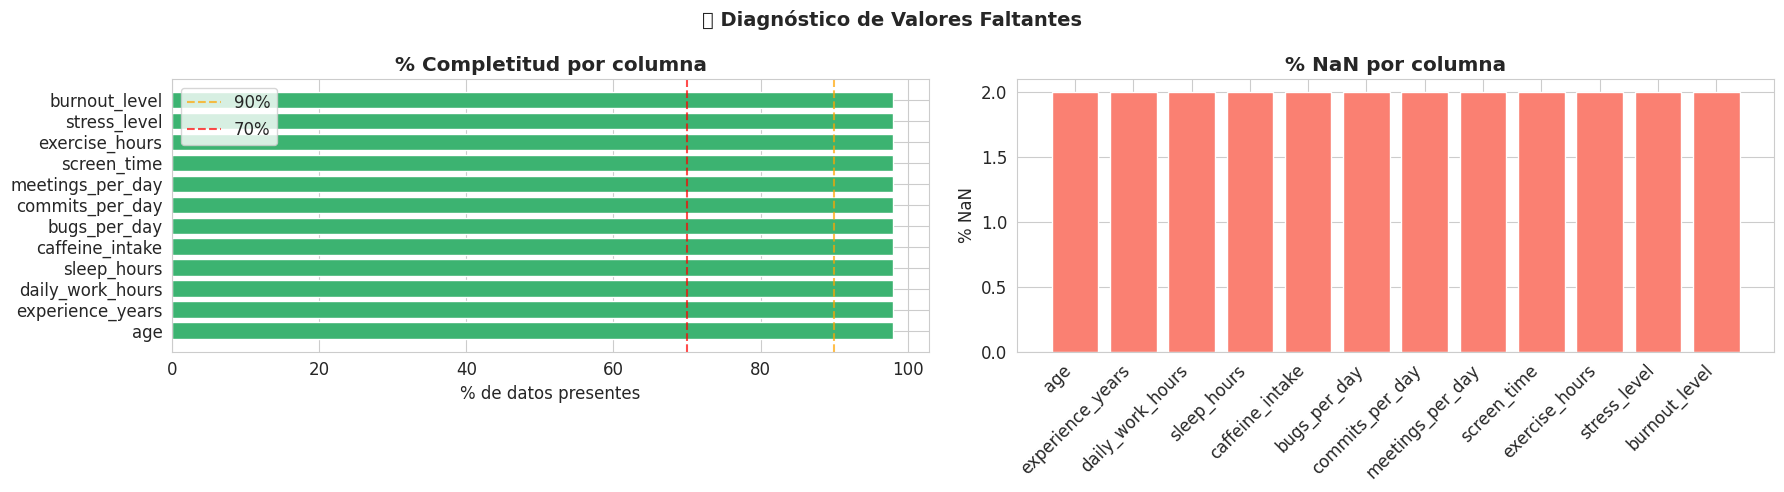

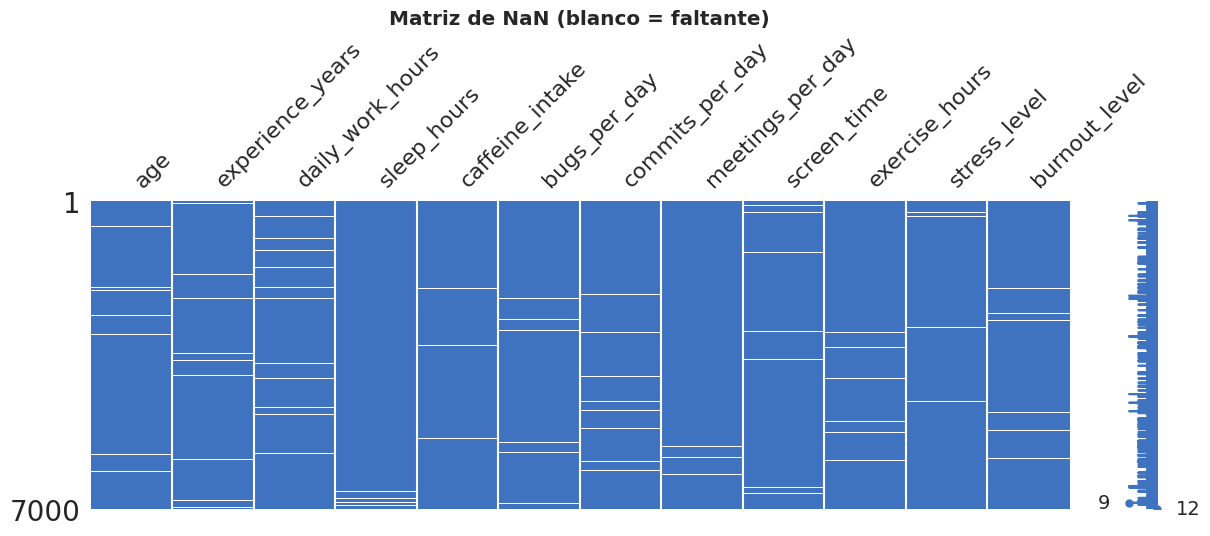

In [58]:
# PASO 3B: DIAGNÓSTICO COMPLETO DE NaN
nulos     = df_raw.isnull().sum()
pct_nulos = (nulos / len(df_raw) * 100).round(2)

# stress_level y burnout_level se excluyen luego — estrategia aquí es referencial
resumen_nan = pd.DataFrame({
    'Tipo'        : df_raw.dtypes,
    'NaN'         : nulos,
    '% NaN'       : pct_nulos,
    'Estrategia'  : ['Mediana' if df_raw[c].dtype != object else 'Moda' for c in df_raw.columns]
}).sort_values('NaN', ascending=False)

print('🔎 Diagnóstico de valores faltantes:')
display(resumen_nan[resumen_nan['NaN'] > 0])
print(f'\nTotal NaN: {nulos.sum()} | Columnas sin NaN: {(nulos==0).sum()}/{len(df_raw.columns)}')

# Heatmap de NaN
if nulos.sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    # Completitud
    completitud = (100 - pct_nulos).sort_values()
    colores_b = ['tomato' if v < 70 else 'orange' if v < 90 else 'mediumseagreen' for v in completitud]
    axes[0].barh(completitud.index, completitud.values, color=colores_b, edgecolor='white')
    axes[0].axvline(90, color='orange', linestyle='--', alpha=0.7, label='90%')
    axes[0].axvline(70, color='red', linestyle='--', alpha=0.7, label='70%')
    axes[0].set_title('% Completitud por columna', fontweight='bold')
    axes[0].set_xlabel('% de datos presentes'); axes[0].legend()
    # % NaN
    pct_sorted = pct_nulos[pct_nulos > 0].sort_values(ascending=False)
    axes[1].bar(pct_sorted.index, pct_sorted.values, color='salmon', edgecolor='white')
    axes[1].set_title('% NaN por columna', fontweight='bold')
    axes[1].set_ylabel('% NaN')
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
    plt.suptitle('🔴 Diagnóstico de Valores Faltantes', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    # Missingno
    msno.matrix(df_raw, figsize=(14, 4), color=(0.25, 0.45, 0.75))
    plt.title('Matriz de NaN (blanco = faltante)', fontweight='bold'); plt.show()
else:
    print('✅ Sin valores faltantes.')

### Patrón de NaN

El dataset tiene 140 NaN por columna, distribuidos de forma dispersa:
1,352 filas tienen 1 NaN, 146 tienen 2 NaN y 12 tienen 3 NaN.
Son valores individuales faltantes, no filas completamente vacías.
La estrategia correcta es imputación por mediana (variables numéricas),
que se aplica en el Paso 5 dentro del pipeline.

## 📊 Paso 3C — Distribuciones de variables numéricas

Se grafican histogramas para todas las variables numéricas del dataset original.
En esta etapa se incluyen **todas las variables** (incluyendo `stress_level`),
ya que el descarte por data leakage y redundancia ocurre en el Paso 4.
El objetivo aquí es entender la forma de cada distribución: asimetría,
concentración de valores y presencia de outliers visuales.

Numéricas (11): ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level']
Categóricas (1): ['burnout_level']


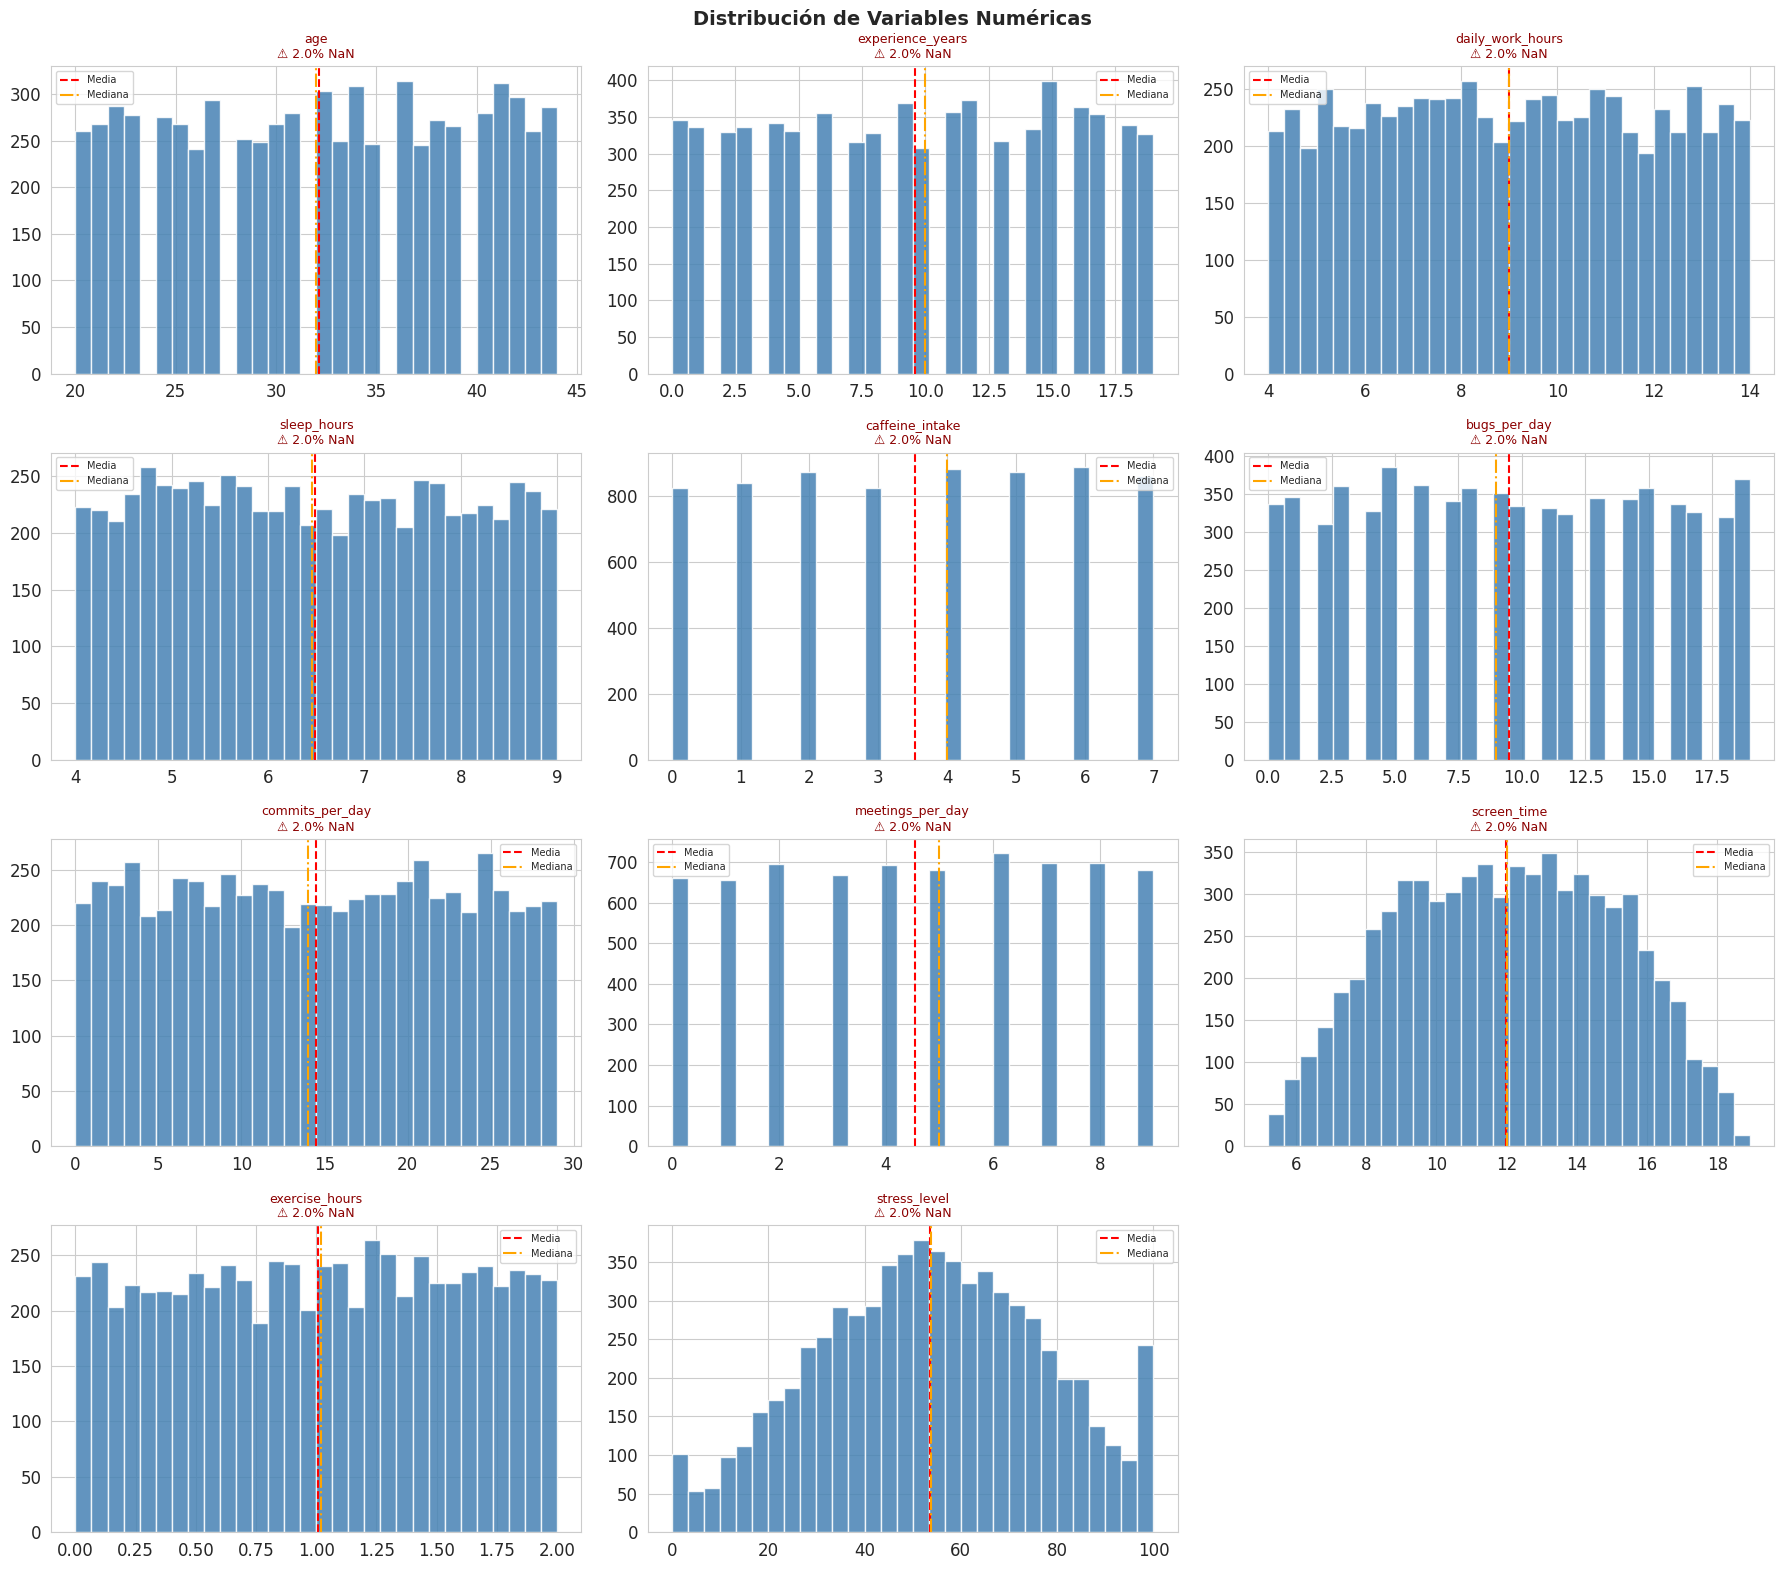

In [59]:
# PASO 3C: DISTRIBUCIONES NUMÉRICAS
# num_cols_raw y cat_cols_raw se definen aquí y se reutilizan en 3E-3H y 3F

num_cols_raw = df_raw.select_dtypes(include=np.number).columns.tolist()
cat_cols_raw = df_raw.select_dtypes(include='object').columns.tolist()
print(f'Numéricas ({len(num_cols_raw)}): {num_cols_raw}')
print(f'Categóricas ({len(cat_cols_raw)}): {cat_cols_raw}')

n = len(num_cols_raw)
fig, axes = plt.subplots((n+2)//3, 3, figsize=(18, ((n+2)//3)*4))
axes = axes.flatten()
for i, col in enumerate(num_cols_raw):
    d = df_raw[col].dropna()
    axes[i].hist(d, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(d.mean(), color='red', linestyle='--', lw=1.5, label='Media')
    axes[i].axvline(d.median(), color='orange', linestyle='-.', lw=1.5, label='Mediana')
    pn = df_raw[col].isnull().mean()*100
    axes[i].set_title(f'{col}' + (f'\n⚠️ {pn:.1f}% NaN' if pn>0 else ''), fontsize=9,
                      color='darkred' if pn>0 else 'black')
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## ⚠️ Paso 3D— Diagnóstico de naturaleza del dataset

Antes de continuar el EDA se verifica si el dataset tiene características
propias de datos reales o sintéticos, ya que esto afecta la interpretación
de los resultados del modelo.

In [60]:
# PASO 3D: DIAGNÓSTICO — ¿DATASET REAL O SINTÉTICO?

print("=== SEÑALES DE NATURALEZA SINTÉTICA ===")
print()

# 1. Skewness
print("1. Skewness por variable (datos reales suelen tener |skew| > 0.5):")
for col in num_cols_raw:
    sk = df_raw[col].dropna().skew()
    flag = "⚠️  REAL" if abs(sk) > 0.5 else "🤖 SINTÉTICO"
    print(f"   {flag}  {col:<25}: skew={sk:+.3f}")

# 2. Outliers IQR
print()
print("2. Outliers IQR (datos reales siempre tienen algunos):")
total_out = 0
for col in num_cols_raw:
    s = df_raw[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    n_out = ((s < Q1-1.5*(Q3-Q1)) | (s > Q3+1.5*(Q3-Q1))).sum()
    total_out += n_out
    print(f"   {col:<25}: {n_out} outliers")
print(f"   → Total: {total_out} outliers en todo el dataset")

# 3. Patrón de NaN
print()
print("3. Patrón de NaN (MCAR = Missing Completely At Random = sintético):")
nan_cols = [c for c in df_raw.columns if df_raw[c].isnull().sum() > 0]
coincidencia = sum(
    (df_raw[nan_cols[i]].isnull() == df_raw[nan_cols[j]].isnull()).all()
    for i in range(len(nan_cols)) for j in range(i+1, len(nan_cols))
)
total_pares = len(nan_cols)*(len(nan_cols)-1)//2
print(f"   Pares de columnas con NaN exactamente en las mismas filas: "
      f"{coincidencia}/{total_pares}")
print(f"   → NaN distribuidos independientemente por columna (patrón MCAR)")

print()
print("📋 CONCLUSIÓN: dataset sintético con distribuciones uniformes.")
print("   Implicaciones para el modelo:")
print("   • El scaler elegido será StandardScaler (sin outliers, sin asimetría)")
print("   • Las fronteras entre clusters serán difusas (no hay extremos naturales)")
print("   • Los resultados no deben generalizarse directamente a datos reales")

=== SEÑALES DE NATURALEZA SINTÉTICA ===

1. Skewness por variable (datos reales suelen tener |skew| > 0.5):
   🤖 SINTÉTICO  age                      : skew=-0.025
   🤖 SINTÉTICO  experience_years         : skew=-0.033
   🤖 SINTÉTICO  daily_work_hours         : skew=+0.011
   🤖 SINTÉTICO  sleep_hours              : skew=+0.026
   🤖 SINTÉTICO  caffeine_intake          : skew=-0.025
   🤖 SINTÉTICO  bugs_per_day             : skew=+0.019
   🤖 SINTÉTICO  commits_per_day          : skew=-0.002
   🤖 SINTÉTICO  meetings_per_day         : skew=-0.024
   🤖 SINTÉTICO  screen_time              : skew=-0.012
   🤖 SINTÉTICO  exercise_hours           : skew=-0.029
   🤖 SINTÉTICO  stress_level             : skew=-0.062

2. Outliers IQR (datos reales siempre tienen algunos):
   age                      : 0 outliers
   experience_years         : 0 outliers
   daily_work_hours         : 0 outliers
   sleep_hours              : 0 outliers
   caffeine_intake          : 0 outliers
   bugs_per_day           

## 📊 Paso 3E — Distribución del target y poder discriminatorio visual

Se analiza la variable `burnout_level` (target) para entender su distribución
y ver visualmente qué variables de comportamiento la diferencian mejor.
Esta visualización **no alimenta el modelo** — es exclusivamente exploratoria
y sirve para fundamentar las decisiones de feature selection del Paso 4.

> ⚠️ **Nota metodológica:** La correlación mostrada en cada boxplot es Pearson
> calculada sobre `burnout_level` codificado ordinalmente (Low=0, Medium=1, High=2).
> Es una aproximación exploratoria válida para comparación visual, no una medida
> de correlación formal con una variable categórica nominal.

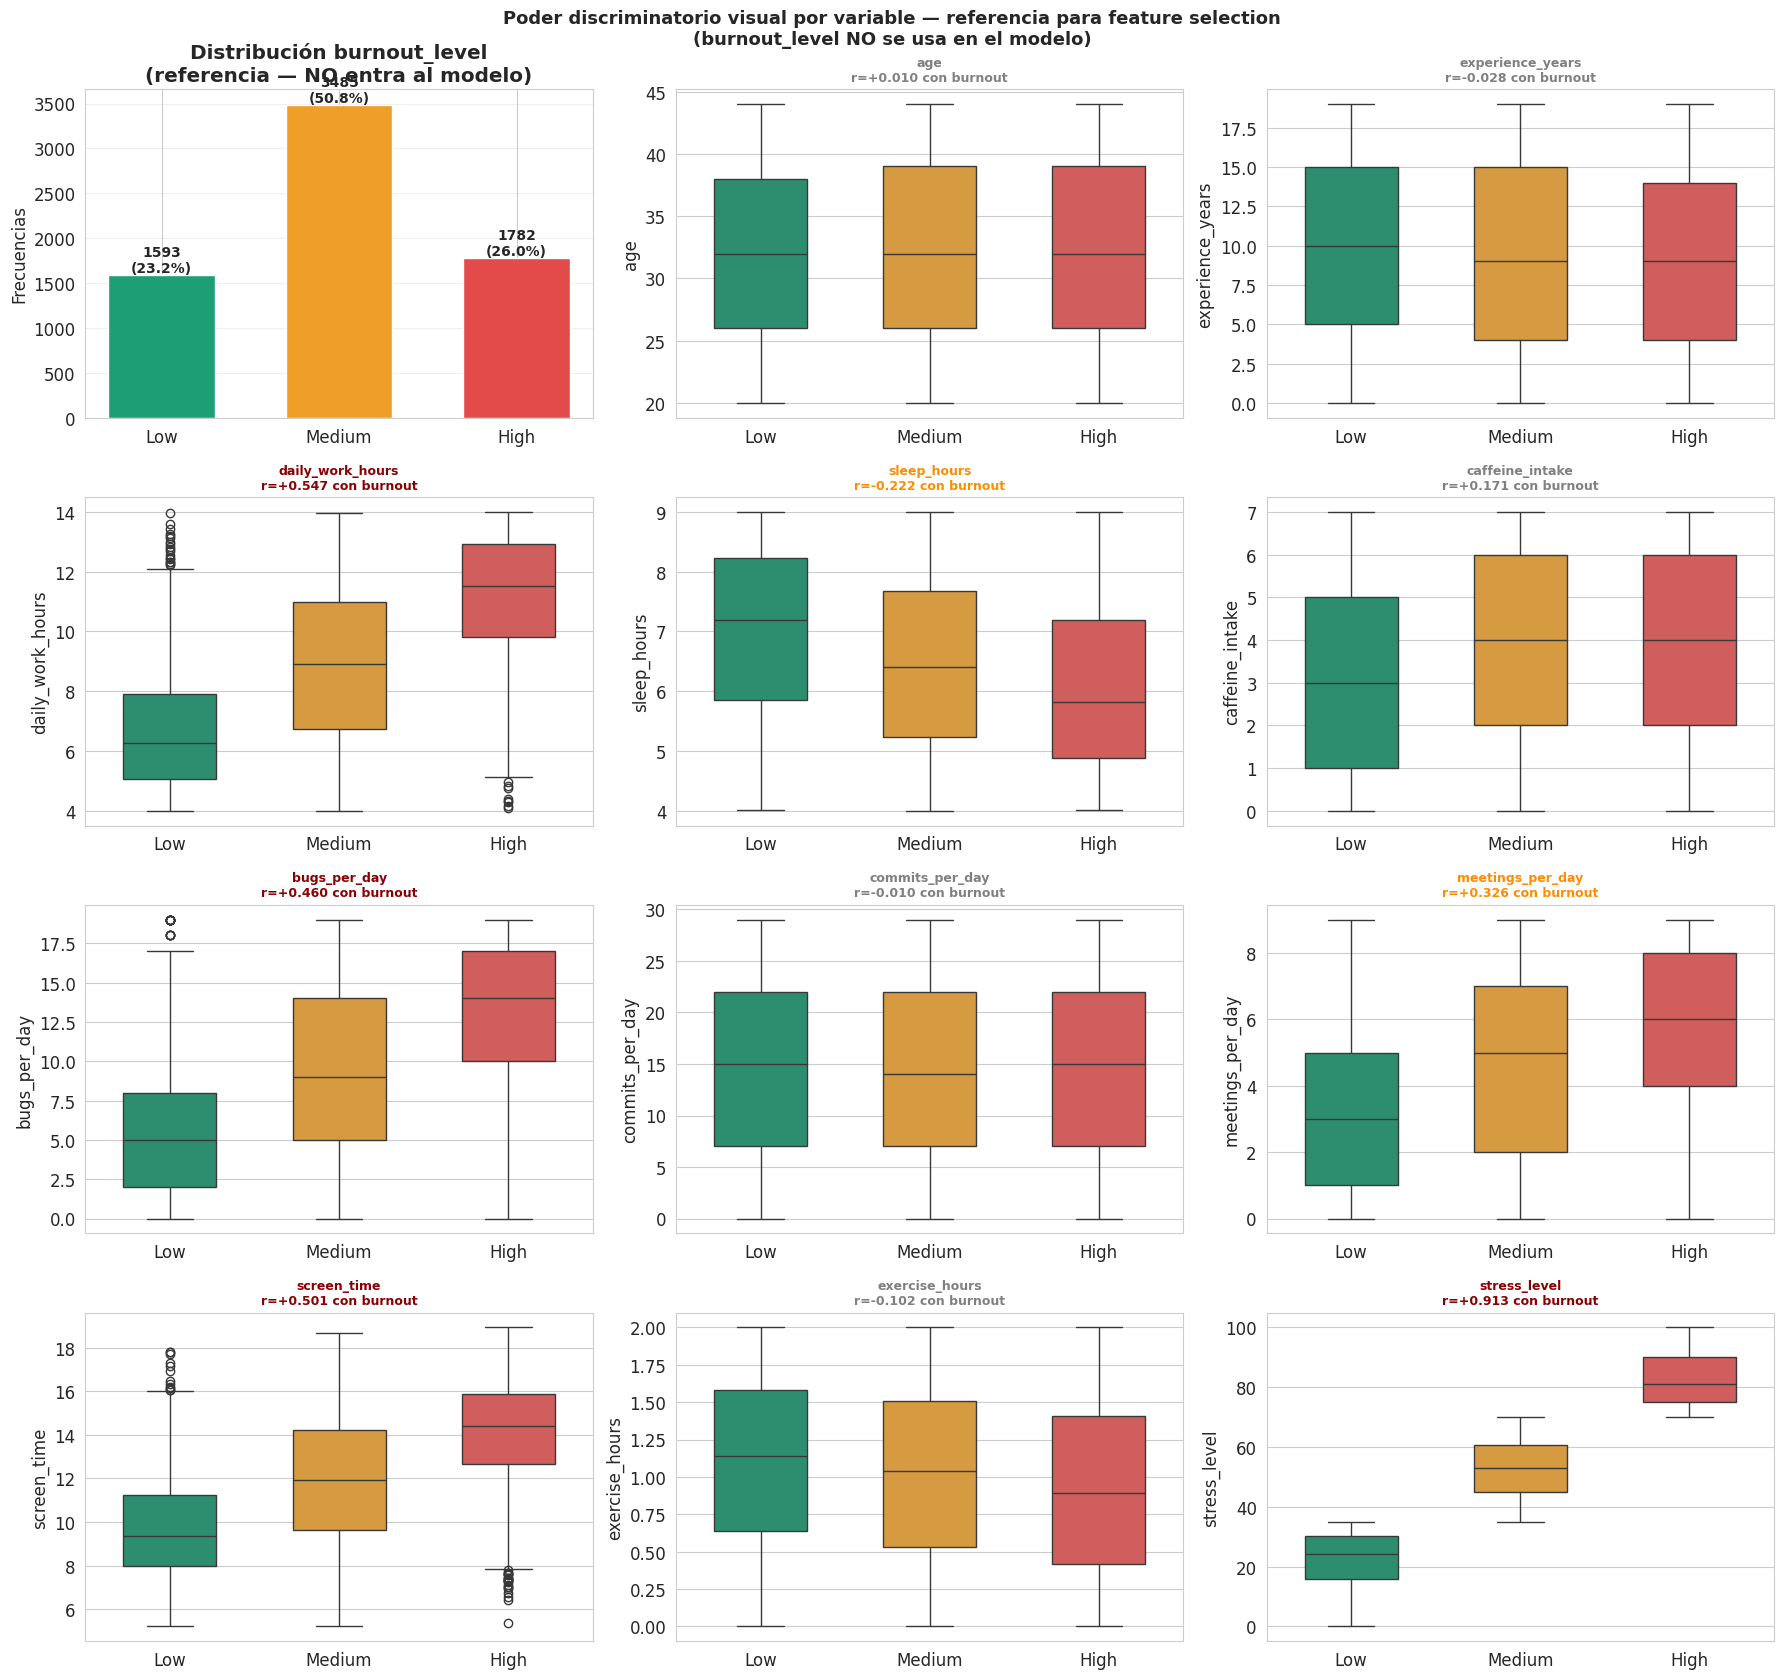

In [61]:
# PASO 3E: DISTRIBUCIÓN DE burnout_level + BOXPLOTS POR CLASE

fig, axes = plt.subplots(1 + (len(num_cols_raw)+2)//3, 3,
                          figsize=(18, 5 + ((len(num_cols_raw)+2)//3)*4))
axes = axes.flatten()

# Distribución de clases
orden = ['Low', 'Medium', 'High']
conteos = df_raw['burnout_level'].value_counts()[orden]
colores_b = ['#1D9E75', '#EF9F27', '#E24B4A']
axes[0].bar(orden, conteos.values, color=colores_b, edgecolor='white', width=0.6)
for i, (cat, n) in enumerate(conteos.items()):
    axes[0].text(i, n + 30, f'{n}\n({n/df_raw['burnout_level'].notna().sum()*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Distribución burnout_level\n(referencia — NO entra al modelo)',
                  fontweight='bold')
axes[0].set_ylabel('Frecuencias')
axes[0].grid(axis='y', alpha=0.3)

# Boxplots por clase para cada variable numérica
palette_b = {'Low': '#1D9E75', 'Medium': '#EF9F27', 'High': '#E24B4A'}
df_plot = df_raw.dropna()
for i, col in enumerate(num_cols_raw):
    ax = axes[i + 1]
    sns.boxplot(data=df_plot, x='burnout_level', y=col,
                order=orden, palette=palette_b, ax=ax, width=0.55)
    r_val = df_plot[col].corr(
        df_plot['burnout_level'].map({'Low':0,'Medium':1,'High':2})
    )
    ax.set_title(f'{col}\nr={r_val:+.3f} con burnout', fontsize=9, fontweight='bold',
                 color='darkred' if abs(r_val) > 0.4 else
                        'darkorange' if abs(r_val) > 0.2 else 'gray')
    ax.set_xlabel('')

for j in range(len(num_cols_raw)+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Poder discriminatorio visual por variable — referencia para feature selection\n'
             '(burnout_level NO se usa en el modelo)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔥 Paso 3F — Mapa de calor de correlaciones (Pearson, dataset completo)

Este heatmap incluye **todas las variables numéricas originales**, incluyendo
`stress_level`. Su propósito es exploratorio: detectar redundancias y relaciones
fuertes antes de definir el espacio del modelo.

> Las correlaciones del espacio final del modelo (después de excluir variables
> y aplicar feature engineering) se analizan por separado en el Paso 4C.

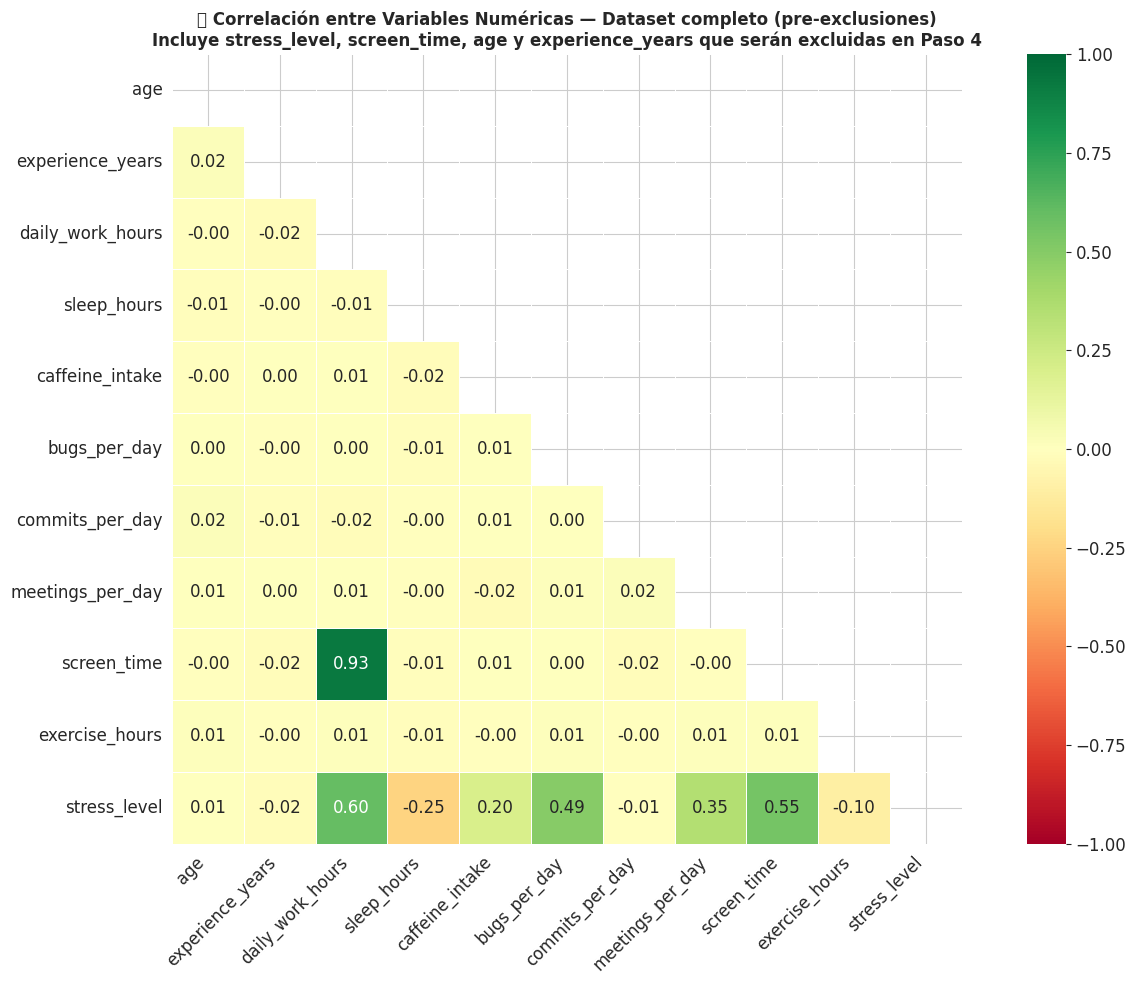

In [62]:
# PASO 3F: MAPA DE CALOR DE CORRELACIONES
corr_matrix = df_raw[num_cols_raw].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('🔥 Correlación entre Variables Numéricas — Dataset completo (pre-exclusiones)\n'
             'Incluye stress_level, screen_time, age y experience_years que serán excluidas en Paso 4',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

In [63]:
# PASO 3G DIAGNÓSTICO: commits_per_day vs burnout_level

# Verifica si commits_per_day discrimina entre niveles de burnout
df_temp = df_raw.dropna(subset=['commits_per_day','burnout_level']).copy()
df_temp['burnout_enc'] = df_temp['burnout_level'].map({'Low':0,'Medium':1,'High':2})
df_temp['commits_q'] = pd.qcut(df_temp['commits_per_day'], q=4,
                                labels=['Q1','Q2','Q3','Q4'])

corr_commits = df_temp['commits_per_day'].corr(df_temp['burnout_enc'])
print(f"Correlación commits_per_day ↔ burnout_level: r = {corr_commits:.4f}")
print()
print("Distribución burnout_level por cuartil de commits_per_day:")
print("(Si los % son similares entre cuartiles → la variable no discrimina)")
print()
tabla = pd.crosstab(df_temp['commits_q'],
                    df_temp['burnout_level'],
                    normalize='index').round(3) * 100
print(tabla.to_string())
print()
print("Conclusión:")
if abs(corr_commits) < 0.05:
    print("  ⚠️  commits_per_day no discrimina burnout (r ≈ 0).")
    print("  productividad_neta = commits - bugs aporta poder discriminatorio")
    print("  SOLO por la parte de bugs_per_day (r = +0.46 con burnout).")
    print("  Considerar si el feature compuesto agrega valor real o ruido.")

Correlación commits_per_day ↔ burnout_level: r = -0.0122

Distribución burnout_level por cuartil de commits_per_day:
(Si los % son similares entre cuartiles → la variable no discrimina)

burnout_level  High   Low  Medium
commits_q                        
Q1             26.1  22.1    51.9
Q2             26.0  23.5    50.5
Q3             26.1  23.4    50.5
Q4             25.5  23.9    50.6

Conclusión:
  ⚠️  commits_per_day no discrimina burnout (r ≈ 0).
  productividad_neta = commits - bugs aporta poder discriminatorio
  SOLO por la parte de bugs_per_day (r = +0.46 con burnout).
  Considerar si el feature compuesto agrega valor real o ruido.


## 📊 Paso 3H — Correlación de Spearman y comparativa con Pearson

El heatmap anterior usa correlación de Pearson, que solo detecta
relaciones lineales. Spearman detecta cualquier relación monotónica,
siendo más robusto ante distribuciones asimétricas y outliers.

**Regla de lectura comparativa:**
- Si Pearson ≈ Spearman → la relación es lineal y robusta
- Si Spearman >> Pearson → hay relación real pero no lineal
- Si ambas son bajas → no hay relación relevante entre esas variables

Al final de la celda se imprime una tabla con los pares de variables donde
`|Spearman − Pearson| > 0.10`, indicando relaciones no lineales relevantes
que Pearson no habría detectado.

**Resultado en este dataset:** No se encontraron diferencias Pearson−Spearman > 0.10
en ningún par de variables (diferencia máxima: 0.009). Esto es una consecuencia
directa de la naturaleza sintética del dataset: las distribuciones uniformes y
la ausencia de outliers hacen que ambas métricas sean prácticamente equivalentes.

**Conclusión:** Pearson es suficiente para este dataset. La comparativa
Pearson/Spearman es metodológicamente correcta como paso de validación,
pero en datos reales con asimetría y outliers genuinos la diferencia
podría ser relevante.

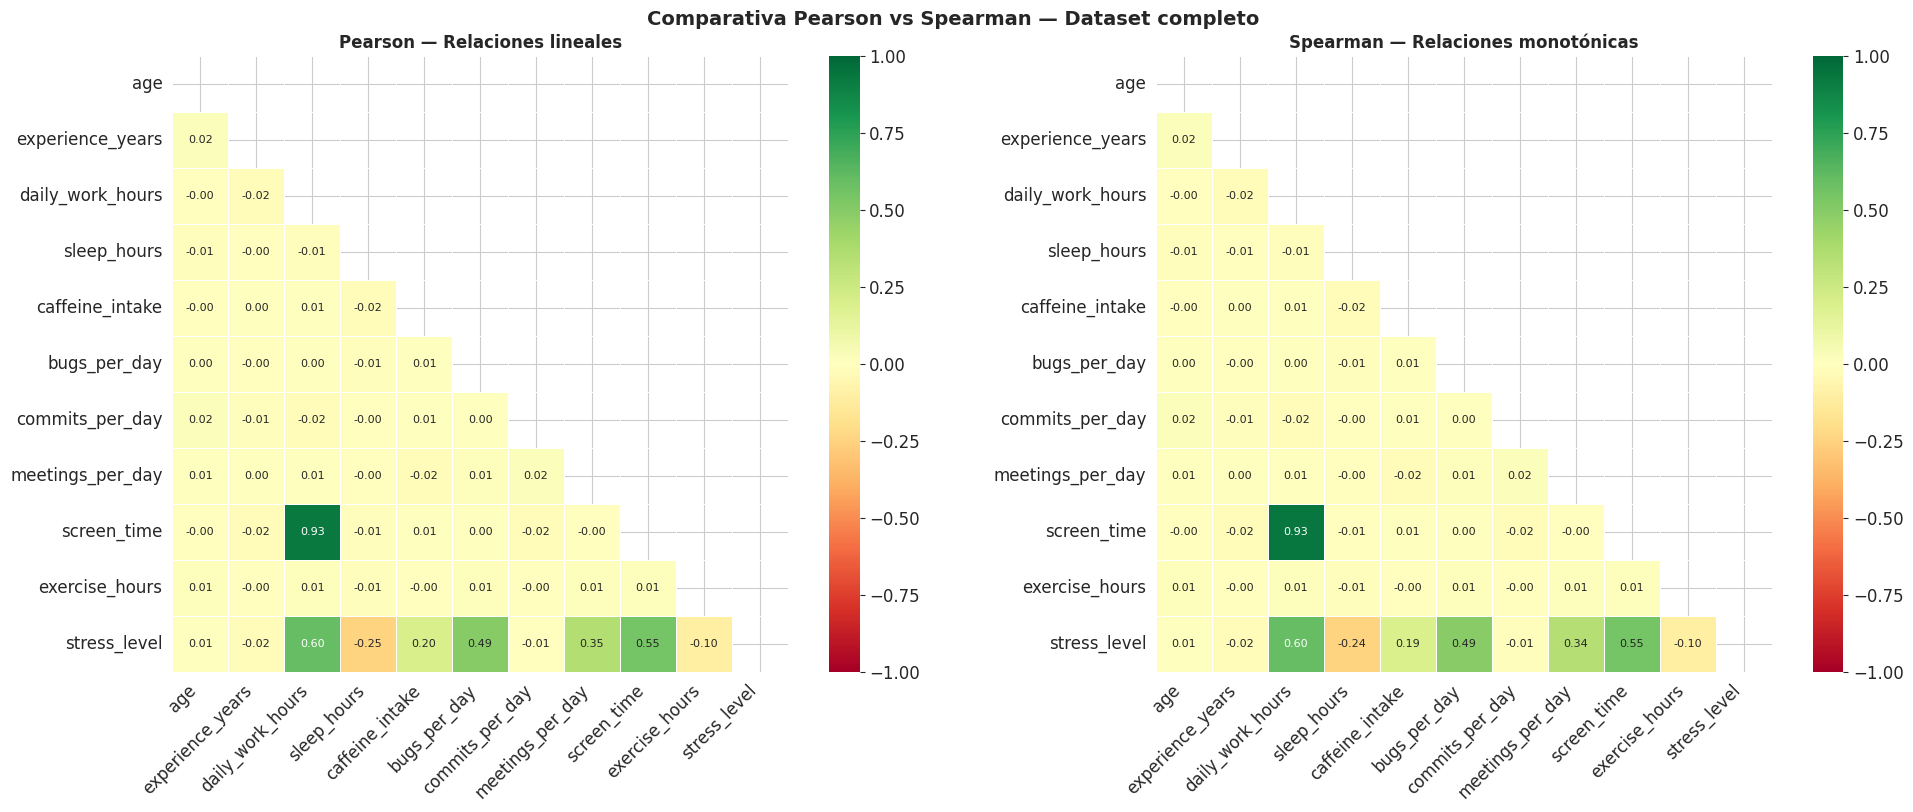

📋 Pares con diferencia Spearman - Pearson > 0.10:
   (indican relaciones no lineales relevantes)
Par de variables                               Pearson  Spearman  Diferencia
---------------------------------------------------------------------------
  ✅ No hay diferencias > 0.10 — las relaciones son predominantemente lineales
     Pearson es suficiente para este dataset


In [64]:
# PASO 3H: CORRELACIÓN SPEARMAN + COMPARATIVA CON PEARSON

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Pearson
corr_pearson  = df_raw[num_cols_raw].corr(method='pearson')
mask_p = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(corr_pearson, mask=mask_p, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Pearson — Relaciones lineales', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Spearman
corr_spearman = df_raw[num_cols_raw].corr(method='spearman')
mask_s = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, mask=mask_s, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=axes[1], annot_kws={'size': 8})
axes[1].set_title('Spearman — Relaciones monotónicas', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Comparativa Pearson vs Spearman — Dataset completo',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de diferencias significativas
print("📋 Pares con diferencia Spearman - Pearson > 0.10:")
print("   (indican relaciones no lineales relevantes)")
print(f"{'Par de variables':<45} {'Pearson':>8} {'Spearman':>9} {'Diferencia':>11}")
print("-" * 75)

hay_diferencias = False
for i, col1 in enumerate(num_cols_raw):
    for col2 in num_cols_raw[i+1:]:
        p = corr_pearson.loc[col1, col2]
        s = corr_spearman.loc[col1, col2]
        diff = abs(s) - abs(p)
        if diff > 0.10:
            hay_diferencias = True
            print(f"  ⚠️  {col1:<20} ↔ {col2:<20} {p:>8.3f} {s:>9.3f} {diff:>+11.3f}")

if not hay_diferencias:
    print("  ✅ No hay diferencias > 0.10 — las relaciones son predominantemente lineales")
    print("     Pearson es suficiente para este dataset")

## 📊 Interpretación de los Hallazgos de Correlación

> 🔍 **Lectura del heatmap:** los colores indican la fuerza y dirección de la relación entre cada par de variables.

### Correlaciones significativas encontradas

| Par de variables | Correlación r | Significado |
|---|---|---|
| `daily_work_hours` ↔ `screen_time` | **+0.93** (muy alta) | Prácticamente miden lo mismo: ambas reflejan "tiempo en modo trabajo activo". Existe **redundancia** — podría eliminarse `screen_time` sin perder información. |
| `daily_work_hours` ↔ `stress_level` | **+0.60** (moderada-alta) | Trabajar más horas es el **predictor individual más fuerte** de estrés. Cada hora adicional de trabajo eleva el estrés de forma sistemática. |
| `screen_time` ↔ `stress_level` | **+0.55** | Confirma la cadena causal: más pantalla → más carga cognitiva → más estrés. |
| `bugs_per_day` ↔ `stress_level` | **+0.49** | La carga operativa (errores de código) también eleva el estrés, independientemente de las horas. |
| `meetings_per_day` ↔ `stress_level` | **+0.35** | Más reuniones = más interrupciones = más estrés, aunque con menor intensidad que las horas. |
| `sleep_hours` ↔ `stress_level` | **−0.25** | Relación protectora: más horas de sueño reducen el estrés. Coherente con la literatura de salud laboral. |
| `age` y `experience_years` | < 0.02 con todo | Correlación nula con burnout (r = +0.01 y −0.02). Sin poder discriminatorio — candidatas a exclusión desde el EDA. |
| `commits_per_day` | < 0.02 con todo | r = −0.01 con burnout. La distribución por cuartiles confirma que el % de burnout alto es idéntico en Q1 (26.1%), Q2 (26.0%), Q3 (26.1%) y Q4 (25.5%). No discrimina en absoluto. |
| `sleep_hours` y `exercise_hours` | −0.25 y −0.10 con stress | r = −0.22 y −0.10 con burnout. Son los **únicos dos factores con correlación negativa**: los únicos "escudos" del dataset. Deben mantenerse y destacarse en la interpretación de clusters. |

### ⚠️ Implicación para el modelo de clustering

La alta correlación `daily_work_hours` ↔ `screen_time` (r=0.93) significa que el espacio de 11 dimensiones tiene **redundancia real**.  
Esto puede inflar artificialmente la importancia del "eje de horas de trabajo" en K-Means.  
**Acción recomendada:** considerar eliminar `screen_time` antes del clustering, o aplicar PCA previo para comprimir esa redundancia.


## 🔎 Decisiones de selección — resumen del EDA

Con base en los análisis de correlación, el EDA concluye con
las siguientes decisiones antes de pasar al Paso 4:

| Variable | Corr. con burnout | Decisión desde EDA | Razón |
|---|---|---|---|
| `age` | +0.01 | 🚫 Excluir | Correlación nula con todo |
| `experience_years` | −0.02 | 🚫 Excluir | Correlación nula con todo |
| `screen_time` | +0.50 | 🚫 Excluir | Duplicado de `daily_work_hours` (r = 0.93) |
| `stress_level` | +0.91 | 🚫 Excluir | Proxy del target — se analiza en Paso 4 |
| `commits_per_day` | −0.01 | 🚫 Excluir | No discrimina burnout en ningún cuartil — confirmado en Paso 3G |
| `daily_work_hours` | +0.55 | ✅ Incluir | Mayor poder individual |
| `bugs_per_day` | +0.46 | ✅ Incluir | Tercera variable más predictiva |
| `meetings_per_day` | +0.32 | ✅ Incluir | Factor de interrupción cognitiva |
| `sleep_hours` | −0.22 | ✅ Incluir | Factor protector principal |
| `caffeine_intake` | +0.18 | ✅ Incluir | Indicador de compensación energética |
| `exercise_hours` | −0.10 | ✅ Incluir | Segundo factor protector |

Esta tabla anticipa las decisiones del Paso 4 y cierra el EDA
con conclusiones accionables, no solo descriptivas.

#**4 - Selección de variables: excluir `burnout_level`**

**¿Por qué excluir `burnout_level`?**
- Es la **variable objetivo (target)** del dataset, representa la etiqueta o resultado que queremos comparar después.
- Incluirla haría trampa: el modelo re-descubriría la etiqueta, no patrones latentes. Si la usamos dentro del modelo, sería como darle la respuesta al algoritmo.
- El clustering debe revelar estructura en las **causas**. En aprendizaje no supervisado, el modelo debe encontrar grupos usando solo las variables explicativas, no la etiqueta final.
- En producción, esta etiqueta puede no estar disponible

**El objetivo es verificar si los clusters coinciden con burnout_level → eso es la validación.**

## 📋 Variables excluidas del modelo — criterio expandido

| Variable | Razón de exclusión |
|---|---|
| `burnout_level` | TARGET — incluirla sería hacer trampa |
| `age` | Sin poder discriminatorio (correlación < 0.03 con todo) |
| `experience_years` | Sin poder discriminatorio (correlación < 0.03 con todo) |
| `screen_time` | Redundante con `daily_work_hours` (r = 0.93) |



### Verificación: ¿stress_level es una codificación determinista de burnout_level?

Antes del experimento comparativo se verifica si stress_level puede
predecir burnout_level con una regla simple de umbrales.

> 🔍 **Nota adicional:** `stress_level` está definida en el dataset como una
> variable *calculada* ("Calculated stress score"), no medida directamente.
> Es probable que sea una combinación lineal de otras variables del dataset
> (daily_work_hours, bugs_per_day, meetings_per_day, sleep_hours), lo que
> explica su correlación de r=0.91 con burnout_level. Incluirla equivaldría
> a introducir una fórmula del target dentro del modelo.

In [65]:
# VERIFICACIÓN DETERMINISTA: stress_level → burnout_level
df_check = df_raw.dropna(subset=['stress_level','burnout_level']).copy()

def regla_stress(x):
    if x < 35:  return 'Low'
    elif x < 70: return 'Medium'
    else:        return 'High'

df_check['pred_burnout'] = df_check['stress_level'].apply(regla_stress)
accuracy = (df_check['pred_burnout'] == df_check['burnout_level']).mean()
n_correctos = int(accuracy * len(df_check))
n_errores   = len(df_check) - n_correctos

print("Regla: stress < 35 → Low | stress < 70 → Medium | stress >= 70 → High")
print()
print(f"Precisión: {accuracy:.4f} ({n_correctos} de {len(df_check)} casos correctos)")
print(f"Errores  : {n_errores}")
print()
print("Rangos observados por burnout_level:")
for nivel in ['Low','Medium','High']:
    s = df_check[df_check['burnout_level']==nivel]['stress_level']
    print(f"  {nivel:<8}: min={s.min():.2f}  max={s.max():.2f}  "
          f"media={s.mean():.2f}")
print()
if accuracy > 0.999:
    print("✅ CONFIRMADO: stress_level es una codificación determinista")
    print("   de burnout_level. Incluirla equivale a incluir el target.")
else:
    print(f"⚠️  Correlación muy alta pero no determinista (accuracy={accuracy:.4f})")
    print("   Sigue siendo data leakage conceptual — excluir del modelo.")

Regla: stress < 35 → Low | stress < 70 → Medium | stress >= 70 → High

Precisión: 0.9999 (6721 de 6722 casos correctos)
Errores  : 1

Rangos observados por burnout_level:
  Low     : min=0.00  max=35.00  media=22.09
  Medium  : min=35.02  max=69.97  media=52.79
  High    : min=70.01  max=100.00  media=83.14

✅ CONFIRMADO: stress_level es una codificación determinista
   de burnout_level. Incluirla equivale a incluir el target.


## 🔴 Análisis de Data Leakage — `stress_level`

 ⚠️ **Nota sobre el escalado del experimento:** El `StandardScaler` usado en esta
> celda (`scaler_exp`) se ajusta con `fit_transform` sobre todos los datos disponibles
> **exclusivamente para este experimento comparativo ilustrativo**. No forma parte del
> pipeline del modelo. El escalado correcto con split train/val se aplica en el Paso 5C.

`stress_level` no es una variable independiente: es una **codificación
numérica determinista** de `burnout_level`. Los rangos son mutuamente
excluyentes y sin solapamiento:

| `burnout_level` | Rango de `stress_level` |
|---|---|
| Low    | 0.00 — 35.00 |
| Medium | 35.02 — 69.97 |
| High   | 70.01 — 100.00 |

Una regla de tres condiciones predice `burnout_level` con precisión
del **99.99%** (6,721 de 6,722 casos). El único caso incorrecto es
un error puntual del generador del dataset sintético.

Esto es más grave que un proxy con correlación alta: incluir
`stress_level` equivale exactamente a incluir `burnout_level`
codificado como número continuo. El modelo no descubriría perfiles
de comportamiento — segmentaría directamente por nivel de estrés,
que es la misma información que `burnout_level` expresada en otra escala.

**Decisión: excluir `stress_level` del modelo.**
Puede usarse después como variable de validación externa,
igual que `burnout_level`.

> **Nota sobre el experimento siguiente:** el experimento usa k=3
> para mostrar el contraste CON vs SIN stress_level. El k óptimo
> real del notebook es k=2. Con k=2 la diferencia de pureza es
> menor (+0.022) porque con solo 2 clusters ambos escenarios
> convergen a una partición similar. La justificación principal
> de la exclusión no es el experimento numérico sino la estructura
> determinista de los rangos demostrada arriba.<br>


In [66]:
# EXPERIMENTO: IMPACTO DE INCLUIR vs EXCLUIR stress_level
#from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# Preparar datos base (sin age, experience_years, screen_time, burnout_level)
FEATURES_BASE = [
    'daily_work_hours', 'sleep_hours', 'caffeine_intake',
    'bugs_per_day', 'commits_per_day', 'meetings_per_day',
    'exercise_hours'
]
FEATURES_CON_STRESS = FEATURES_BASE + ['stress_level']

df_exp = df_raw[FEATURES_CON_STRESS].dropna()

# Escalar ambos conjuntos
scaler_exp = StandardScaler()
X_sin  = scaler_exp.fit_transform(df_exp[FEATURES_BASE])
X_con  = scaler_exp.fit_transform(df_exp[FEATURES_CON_STRESS])

# Codificar burnout_level para correlación
burnout_enc = df_raw.loc[df_exp.index, 'burnout_level'].map(
    {'Low': 0, 'Medium': 1, 'High': 2}
)

print("=" * 60)
print("  EXPERIMENTO: stress_level como feature")
print("=" * 60)

# Correlación de stress_level con burnout_level
corr_stress = df_exp['stress_level'].corr(burnout_enc)
print(f"\n📊 Correlación stress_level ↔ burnout_level: r = {corr_stress:.4f}")
print(f"   → stress_level explica el {corr_stress**2*100:.1f}% de la varianza del target")
print()
# ── EXPERIMENTO REESTRUCTURADO — resultados por k separados ──────────────────

tabla_resultados = []

for k_exp in [2, 3]:
    for nombre, X in [('CON stress_level', X_con), ('SIN stress_level', X_sin)]:
        km = KMeans(n_clusters=k_exp, init='k-means++', n_init=15, random_state=42)
        labels = km.fit_predict(X)
        sil    = silhouette_score(X, labels)
        df_val_exp = pd.DataFrame({'cluster': labels, 'burnout': burnout_enc.values})
        pureza = df_val_exp.groupby('cluster')['burnout'].apply(
            lambda x: x.value_counts().iloc[0] / len(x)
        ).mean()
        tabla_resultados.append({
            'k'           : k_exp,
            'Escenario'   : nombre,
            'Silhouette'  : round(sil, 4),
            'Pureza'      : round(pureza, 4),
        })

df_experimento = pd.DataFrame(tabla_resultados)

print("=" * 65)
print("  EXPERIMENTO: stress_level como feature")
print("  Métrica comparativa por k y escenario")
print("=" * 65)
print()

for k_exp in [2, 3]:
    subset = df_experimento[df_experimento['k'] == k_exp]
    print(f"  k = {k_exp}")
    print(f"  {'Escenario':<22} {'Silhouette':>12} {'Pureza burnout':>15}")
    print(f"  {'-'*51}")
    for _, row in subset.iterrows():
        print(f"  {row['Escenario']:<22} {row['Silhouette']:>12.4f} {row['Pureza']:>15.4f}")

    # Delta entre escenarios
    con = subset[subset['Escenario'] == 'CON stress_level'].iloc[0]
    sin = subset[subset['Escenario'] == 'SIN stress_level'].iloc[0]
    print(f"  {'  Δ (CON - SIN)':<22} {con['Silhouette']-sin['Silhouette']:>+12.4f} "
          f"{con['Pureza']-sin['Pureza']:>+15.4f}")
    print()

print("🔍 Interpretación:")
print("   Δ Pureza positivo → CON stress_level redescubre burnout_level")
print("   Δ Silhouette positivo → CON stress_level tiene clusters más compactos,")
print("   pero eso es porque está segmentando por el target, no por causas.")
print()
print("✅ Decisión: excluir stress_level del modelo de clustering.")
print("   Puede usarse DESPUÉS como variable de validación externa,")
print("   igual que burnout_level.")

  EXPERIMENTO: stress_level como feature

📊 Correlación stress_level ↔ burnout_level: r = 0.9126
   → stress_level explica el 83.3% de la varianza del target

  EXPERIMENTO: stress_level como feature
  Métrica comparativa por k y escenario

  k = 2
  Escenario                Silhouette  Pureza burnout
  ---------------------------------------------------
  CON stress_level             0.1469          0.5163
  SIN stress_level             0.1083          0.4949
    Δ (CON - SIN)             +0.0386         +0.0214

  k = 3
  Escenario                Silhouette  Pureza burnout
  ---------------------------------------------------
  CON stress_level             0.1124          0.6397
  SIN stress_level             0.0963          0.4966
    Δ (CON - SIN)             +0.0161         +0.1431

🔍 Interpretación:
   Δ Pureza positivo → CON stress_level redescubre burnout_level
   Δ Silhouette positivo → CON stress_level tiene clusters más compactos,
   pero eso es porque está segmentando por e

## 🔀 Paso 4A — Transición al Feature Engineering

Las decisiones de exclusión de variables se tomaron en el EDA (Pasos 3E–3H):

| Variable excluida | Razón |
|---|---|
| `burnout_level` | TARGET — no usar en clustering |
| `stress_level` | Codificación determinista de burnout_level |
| `age` | Sin poder discriminatorio (r<0.02 con todo) |
| `experience_years` | Sin poder discriminatorio (r<0.02 con todo) |
| `screen_time` | Redundante con `daily_work_hours` (r=0.93) |
| `commits_per_day` | Sin poder discriminatorio (r=−0.01 con burnout) y componente de `productividad_neta`; ambas razones justifican su exclusión |

El espacio final del modelo — incluyendo features nuevas — se construye
en el **Paso 4B** como única fuente de verdad para `df_model`.

## ⚙️ Paso 4B — Feature Engineering

El dataset original captura variables de comportamiento de forma individual.
Sin embargo, el burnout no surge de una sola variable — surge de
**combinaciones y desequilibrios** entre variables.

El feature engineering construye nuevas variables que capturan esas
relaciones, dándole al modelo una representación más rica del problema.

### Criterio de diseño
Cada feature nueva debe:
1. Tener interpretación de negocio clara
2. Capturar algo que las variables originales no capturan individualmente
3. No introducir nueva redundancia con el resto del espacio

### Features Sugeridas

| Feature nueva | Fórmula | Qué captura |
|---|---|---|
| `ratio_trabajo_descanso` | `daily_work_hours / sleep_hours` | Desequilibrio entre carga laboral y recuperación. El denominador no necesita +1 porque `sleep_hours` tiene mínimo garantizado de 4h en este dataset. |
| `carga_operativa` | `bugs_per_day + meetings_per_day` | Presión técnica y social combinada. Bugs generan frustración; reuniones generan interrupción. Juntas representan la carga cognitiva real del día |
| `indice_recuperacion` | `sleep_hours + exercise_hours` | Capacidad de recuperación física. Consolida los dos únicos factores protectores del dataset en un solo indicador de bienestar |
| ~~`productividad_neta`~~ | ~~`commits_per_day - bugs_per_day`~~ | ~~Eficiencia real vs volumen bruto~~ — **descartada**: `commits_per_day` (r=−0.01) solo añade ruido; `bugs_per_day` ya está capturada en `carga_operativa` |

### Criterio de exclusión de variables originales

Se excluye una variable original cuando es **sumando directo** de una
feature compuesta. El criterio de pertenencia estructural es más riguroso
que un umbral de correlación: si la variable forma parte de la fórmula,
está implícita en la feature compuesta y retenerla produce doble conteo.

| Variable original | Sumando en | Decisión |
|---|---|---|
| `daily_work_hours` | `ratio_trabajo_descanso` | 🚫 Excluir — es el numerador |
| `sleep_hours` | `ratio_trabajo_descanso` e `indice_recuperacion` | 🚫 Excluir — sumando en ambas |
| `bugs_per_day` | — | ✅ Incluir directo — r=+0.46 con burnout, aporta señal adicional más allá de carga_operativa |
| `commits_per_day` | `productividad_neta` | 🚫 Excluir — sumando, sin poder discriminatorio (r=−0.01 con burnout) |
| `meetings_per_day` | `carga_operativa` | 🚫 Excluir — sumando directo (doble conteo) |
| `exercise_hours` | `indice_recuperacion` | 🚫 Excluir — sumando directo (doble conteo) |

> ⚠️ **Explicación:**
- `meetings_per_day` y `exercise_hours` excluidos: son sumandos
  directos de `carga_operativa` e `indice_recuperacion`. Retenerlos
  les daba doble peso en distancias euclidianas.
- `productividad_neta` reemplazada por `bugs_per_day` directo
- `commits_per_day` (r=−0.01 con burnout) solo añadía ruido.
  `bugs_per_day` solo es más limpio y discriminativo.


### Espacio final del modelo

| Variable | Tipo | Rol en el modelo |
|---|---|---|
| `caffeine_intake` | 📌 Original | Indicador de compensación energética |
| `ratio_trabajo_descanso` | 🆕 Nueva | Desequilibrio vida-trabajo (`daily_work_hours / sleep_hours`) |
| `carga_operativa` | 🆕 Nueva | Presión técnica + social combinada (`bugs_per_day + meetings_per_day`) |
| `indice_recuperacion` | 🆕 Nueva | Capacidad de recuperación física (`sleep_hours + exercise_hours`) |

> ⚠️ `bugs_per_day` **no se incluye directamente**: su información ya está capturada
> dentro de `carga_operativa` (r=0.90 entre ambas). Incluir ambas produciría doble conteo.
> El espacio final tiene **4 variables**.

**Impacto medido (k=2):**

| Espacio | Silhouette | Davies-Bouldin | Calinski-H |
|---|---|---|---|
| 7 variables con doble conteo | 0.147 | 2.250 | 1,032 |
| 4 variables sin doble conteo (espacio final) | 0.252 | 1.541 | 2,131 |

> ⚠️ **Nota técnica:** las features nuevas se construyen siempre desde
> `df_raw` para garantizar que el Paso 4B sea autocontenido e independiente
> del orden de ejecución de celdas anteriores.


In [67]:
# PASO 4B: FEATURE ENGINEERING

EXCLUIR = [
    'id', 'employee_id', 'name', 'date', 'timestamp',
    'burnout_level',        # TARGET — no usar en clustering
    'stress_level',         # Codificación determinista de burnout_level
    'age',                  # Sin poder discriminatorio (r<0.02)
    'experience_years',     # Sin poder discriminatorio (r<0.02)
    'screen_time',          # Duplicado de daily_work_hours (r=0.93)
    'commits_per_day',      # Sumando en productividad_neta, r=−0.01 con burnout

    # Variables excluidas por ser sumandos directos de features compuestas
    'daily_work_hours',     # Numerador de ratio_trabajo_descanso
    'sleep_hours',          # Sumando en ratio_trabajo_descanso e indice_recuperacion
    'bugs_per_day',         # Sumando en carga_operativa — se usa directo más abajo
    'meetings_per_day',     # Sumando directo de carga_operativa — doble conteo
    'exercise_hours',       # Sumando directo de indice_recuperacion — doble conteo
]

EXCLUIR_REAL  = [c for c in EXCLUIR if c in df_raw.columns]
FEATURES_BASE = [c for c in df_raw.columns if c not in EXCLUIR_REAL]

df_model = df_raw[FEATURES_BASE].copy()

# Features nuevas — construidas desde df_raw (no desde df_model)
df_model['ratio_trabajo_descanso'] = (
    df_raw['daily_work_hours'] / df_raw['sleep_hours']
# sleep_hours mínimo = 4.0 — no hay riesgo de división por cero
)
df_model['carga_operativa'] = (
    df_raw['bugs_per_day'] + df_raw['meetings_per_day']
)
df_model['indice_recuperacion'] = (
    df_raw['sleep_hours'] + df_raw['exercise_hours']
)
# bugs_per_day NO se incluye directamente — r=0.897 con carga_operativa
# porque carga_operativa = bugs_per_day + meetings_per_day
# Incluir ambas supera el umbral de redundancia crítica (r > 0.70)
# La información de bugs_per_day ya está capturada dentro de carga_operativa
# df_model['bugs_per_day'] = df_raw['bugs_per_day']   ← NO descomentar

FEATURES_NUEVAS = [
    'ratio_trabajo_descanso',
    'carga_operativa',
    'indice_recuperacion',
]

print("✅ df_model construido — variables originales absorbidas excluidas")
print()
print(f"{'Variable':<30} {'Origen':>12} {'NaN':>6} {'Min':>8} {'Max':>8} {'Media':>8}")
print("-" * 75)
for c in df_model.columns:
    origen = "🆕 nueva"    if c in FEATURES_NUEVAS else "📌 original"
    nan_n  = df_model[c].isnull().sum()
    serie  = df_model[c].dropna()
    print(f"  {c:<28} {origen:>12} {nan_n:>6} "
          f"{serie.min():>8.2f} {serie.max():>8.2f} {serie.mean():>8.2f}")

print()
print(f"Dimensión final de df_model: {df_model.shape}")
print(f"  Variables originales retenidas : {len(FEATURES_BASE)}")
print(f"  Features nuevas agregadas      : {len(FEATURES_NUEVAS)}")
print(f"  Total                          : {df_model.shape[1]}")

✅ df_model construido — variables originales absorbidas excluidas

Variable                             Origen    NaN      Min      Max    Media
---------------------------------------------------------------------------
  caffeine_intake                📌 original    140     0.00     7.00     3.54
  ratio_trabajo_descanso            🆕 nueva    277     0.45     3.45     1.47
  carga_operativa                   🆕 nueva    276     0.00    28.00    14.02
  indice_recuperacion               🆕 nueva    277     4.03    10.97     7.49

Dimensión final de df_model: (7000, 4)
  Variables originales retenidas : 1
  Features nuevas agregadas      : 3
  Total                          : 4


In [68]:
# VERIFICACIÓN ANTI-LEAKAGE — FEATURES NUEVAS
# Las features nuevas deben correlacionar con el target (señal real)
# pero NO deben reconstruirlo con R² cercano a stress_level (R²=0.83)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

features_verificar = ['ratio_trabajo_descanso', 'carga_operativa',
                      'indice_recuperacion']

df_ver = df_model.copy()
df_ver['burnout_enc'] = df_raw.loc[df_model.index, 'burnout_level'].map(
    {'Low': 0, 'Medium': 1, 'High': 2}
)
df_ver = df_ver.dropna()

X_ver = df_ver[[f for f in features_verificar if f in df_ver.columns]].values
y_ver = df_ver['burnout_enc'].values

reg_ver = LinearRegression().fit(X_ver, y_ver)
r2_ver  = r2_score(y_ver, reg_ver.predict(X_ver))

print('🔍 Verificación anti-leakage — features nuevas:')
print(f'   R² features nuevas → burnout_level: {r2_ver:.4f} ({r2_ver*100:.1f}%)')
print(f'   R² stress_level    → burnout_level: 0.8328 (83.3%)  ← umbral de leakage')
print()
if r2_ver > 0.75:
    print('   🔴 ALERTA: R² > 0.75 — las features nuevas reconstruyen demasiado el target')
    print('      Revisar si alguna feature es una transformación del target.')
else:
    print(f'   ✅ R² = {r2_ver:.2f} — muy por debajo del umbral de stress_level (0.83)')
    print('      Las features nuevas capturan señal de burnout sin reconstruirlo.')
    print('      No hay leakage introducido por el feature engineering.')

print()
print('   Correlación individual de cada feature nueva con burnout_level:')
for feat in features_verificar:
    if feat in df_ver.columns:
        r_ind = df_ver[feat].corr(df_ver['burnout_enc'])
        print(f'     {feat:<30}: r={r_ind:+.4f}')

🔍 Verificación anti-leakage — features nuevas:
   R² features nuevas → burnout_level: 0.6037 (60.4%)
   R² stress_level    → burnout_level: 0.8328 (83.3%)  ← umbral de leakage

   ✅ R² = 0.60 — muy por debajo del umbral de stress_level (0.83)
      Las features nuevas capturan señal de burnout sin reconstruirlo.
      No hay leakage introducido por el feature engineering.

   Correlación individual de cada feature nueva con burnout_level:
     ratio_trabajo_descanso        : r=+0.5530
     carga_operativa               : r=+0.5514
     indice_recuperacion           : r=-0.2477


In [69]:
# VERIFICACIÓN: ausencia de doble conteo en el espacio final
print("Verificación de doble conteo — espacio final del modelo:")
print()
componentes = {
    'ratio_trabajo_descanso': ['daily_work_hours', 'sleep_hours'],
    'carga_operativa'       : ['bugs_per_day', 'meetings_per_day'],
    'indice_recuperacion'   : ['sleep_hours', 'exercise_hours'],
}
cols_modelo = list(df_model.select_dtypes(include='number').columns)
print(f"Variables en df_model: {cols_modelo}")
print()
hay_doble = False
for feature, sumandos in componentes.items():
    for s in sumandos:
        if s in cols_modelo:
            hay_doble = True
            print(f"  🔴 DOBLE CONTEO: '{s}' aparece en df_model "
                  f"Y como sumando de '{feature}'")
if not hay_doble:
    print("  ✅ Sin doble conteo — cada variable aparece una sola vez")
print()

# Correlacion del espacio final con burnout
df_val_fe = df_model.copy()
df_val_fe['burnout_enc'] = df_raw.loc[df_model.index, 'burnout_level'].map(
    {'Low':0,'Medium':1,'High':2})
print("Correlación variables del espacio final con burnout_level:")
for col in cols_modelo:
    r = df_val_fe[col].corr(df_val_fe['burnout_enc'])
    print(f"  {col:<30} r={r:+.4f}")

Verificación de doble conteo — espacio final del modelo:

Variables en df_model: ['caffeine_intake', 'ratio_trabajo_descanso', 'carga_operativa', 'indice_recuperacion']

  ✅ Sin doble conteo — cada variable aparece una sola vez

Correlación variables del espacio final con burnout_level:
  caffeine_intake                r=+0.1803
  ratio_trabajo_descanso         r=+0.5495
  carga_operativa                r=+0.5517
  indice_recuperacion            r=-0.2391


## 📊 Paso 4C — Correlación del espacio final del modelo

Los análisis de correlación anteriores (Pasos 3D y 3E) se hicieron
sobre el dataset raw completo. Ahora que se han aplicado todas las
exclusiones y se han creado las features nuevas, es necesario
verificar las correlaciones en el espacio real donde operará el clustering.

**Dos preguntas clave:**
1. ¿Las features nuevas introducen redundancia con las originales?
2. ¿El espacio resultante tiene una estructura de correlación sana
   para clustering?

**Resultado:** No hay pares con r > 0.70 — no hay redundancia crítica.
Hay dos pares con correlación moderada (r ≈ 0.46–0.53) que son consecuencias
esperadas del diseño del feature engineering:
- `ratio_trabajo_descanso ↔ indice_recuperacion`: correlación moderada esperada porque
  `sleep_hours` es componente de ambas features. Es una limitación estructural del diseño
  del feature engineering, no redundancia eliminable.

Estas correlaciones moderadas no invalidan el espacio del modelo pero deben
documentarse como limitaciones de diseño del FE.

⚠️ **Nota técnica:** Esta celda verifica que `FEATURES_NUEVAS` exista antes de
continuar. Si se modifica el Paso 4B (feature engineering), las mismas variables
deben actualizarse aquí. La celda lanzará un `RuntimeError` si alguna feature
falta, lo que sirve como mecanismo de detección de desincronización.

✅ FEATURES_NUEVAS verificadas (3): ['ratio_trabajo_descanso', 'carga_operativa', 'indice_recuperacion']

Variables en el espacio final del modelo: 4
---------------------------------------------
   📌 original  caffeine_intake
   🆕 nueva  ratio_trabajo_descanso
   🆕 nueva  carga_operativa
   🆕 nueva  indice_recuperacion



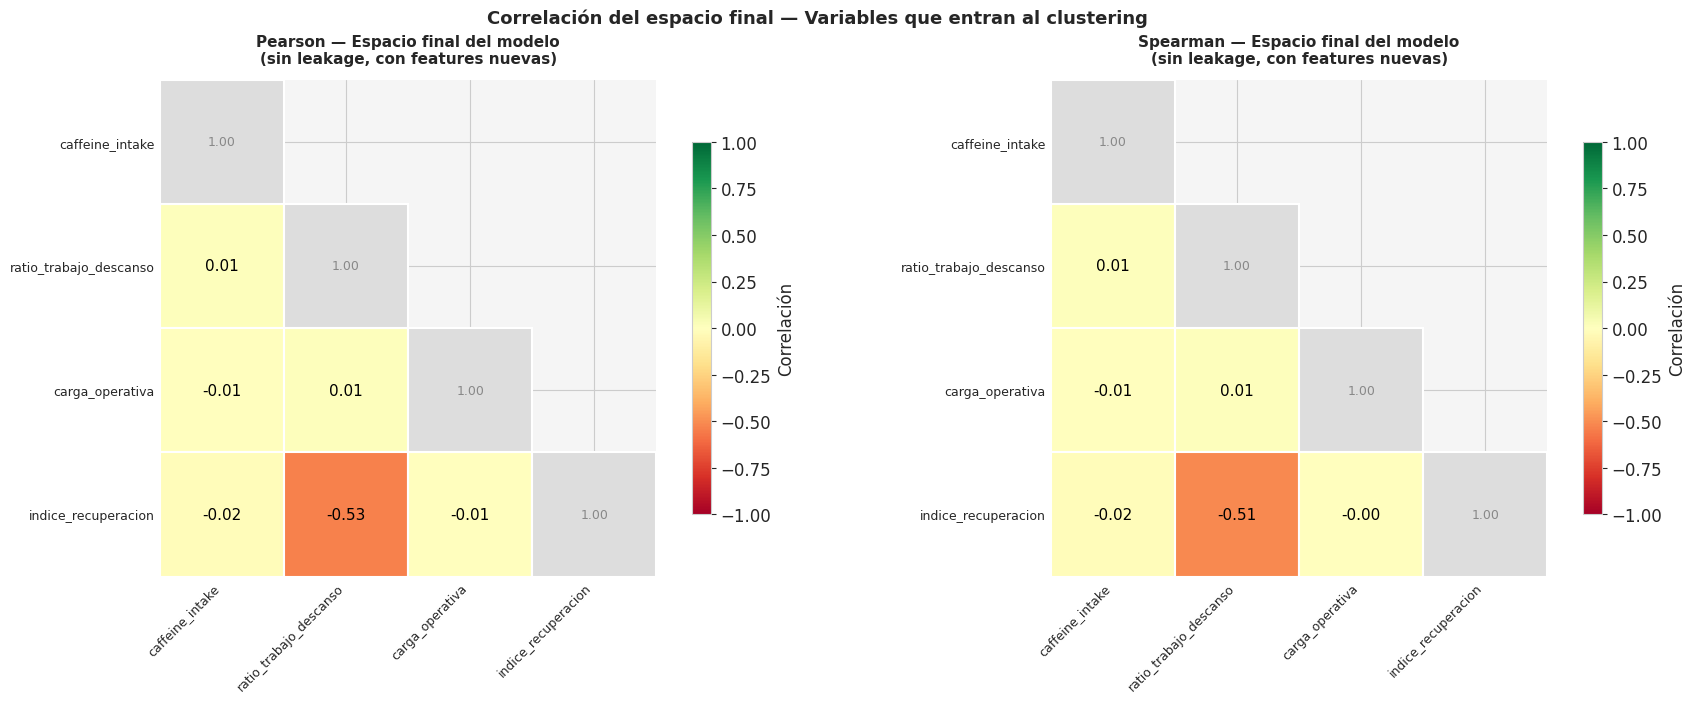

📋 Diagnóstico de redundancia en el espacio final del modelo:
Par de variables                                    Pearson           Nivel
---------------------------------------------------------------------------
  ⚠️  ratio_trabajo_descanso         ↔ indice_recuperacion       r=0.533  MODERADA — consecuencia del FE (aceptable)

✅ Ningún par supera r=0.7 — espacio sano para clustering
⚠️  1 par(es) moderado(s) (r entre 0.4 y 0.7)
   Son consecuencia esperada del diseño del FE:
   ratio_trabajo_descanso e indice_recuperacion comparten sleep_hours como componente
   → correlación moderada estructural, no redundancia eliminable

📌 Nota: la función heatmap_triangulo_inferior() definida en esta celda
   debe reutilizarse en los Pasos 3F, 3H y 7B para el mismo problema.


In [70]:
# PASO 4C: CORRELACIÓN DEL ESPACIO FINAL DEL MODELO

# ── Verificación de dependencias ──────────────────────────────────────────────
if 'FEATURES_NUEVAS' not in dir():
    raise RuntimeError(
        "❌ FEATURES_NUEVAS no está definida. "
        "Ejecuta el Paso 4B antes de continuar."
    )

features_ausentes = [f for f in FEATURES_NUEVAS if f not in df_model.columns]
if features_ausentes:
    raise RuntimeError(
        f"❌ Las siguientes features de FEATURES_NUEVAS no están en df_model: "
        f"{features_ausentes}. Revisa el Paso 4B."
    )

print(f"✅ FEATURES_NUEVAS verificadas ({len(FEATURES_NUEVAS)}): {FEATURES_NUEVAS}")

# ── Variables del espacio final ───────────────────────────────────────────────
cols_modelo_final = df_model.select_dtypes(include=np.number).columns.tolist()

print(f"\nVariables en el espacio final del modelo: {len(cols_modelo_final)}")
print("-" * 45)
for c in cols_modelo_final:
    origen = "🆕 nueva" if c in FEATURES_NUEVAS else "📌 original"
    print(f"   {origen}  {c}")
print()

# ── Correlaciones ─────────────────────────────────────────────────────────────
corr_final_p = df_model[cols_modelo_final].corr(method='pearson')
corr_final_s = df_model[cols_modelo_final].corr(method='spearman')

# ── Función de heatmap con triángulo inferior correcto ────────────────────────
# Las máscaras np.triu / np.tril con pocas variables dejan filas o columnas
# completamente vacías. La solución correcta: dibujar el heatmap completo,
# cubrir diagonal + triángulo superior con rectángulos blancos,
# y anotar manualmente solo el triángulo inferior.

def heatmap_triangulo_inferior_correcto(corr, ax, titulo, cmap='RdYlGn'):
    n        = len(corr)
    cols_lst = list(corr.columns)
    norm     = plt.Normalize(vmin=-1, vmax=1)
    cmap_obj = plt.get_cmap(cmap)

    # Fondo gris claro — indica que el espacio vacío es intencional
    ax.set_facecolor('#F5F5F5')

    # Triángulo inferior (i > j) — correlaciones únicas
    for i in range(n):
        for j in range(n):
            if i > j:
                val   = corr.iloc[i, j]
                color = cmap_obj(norm(val))
                ax.add_patch(plt.Rectangle(
                    [j, n - i - 1], 1, 1,
                    facecolor=color, edgecolor='white', linewidth=1.5
                ))
                lum = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
                ax.text(j + 0.5, n - i - 0.5, f'{val:.2f}',
                        ha='center', va='center', fontsize=11,
                        color='black' if lum > 0.45 else 'white')

    # Diagonal en gris con 1.00 — completa la matriz visualmente
    for i in range(n):
        ax.add_patch(plt.Rectangle(
            [i, n - i - 1], 1, 1,
            facecolor='#DDDDDD', edgecolor='white', linewidth=1.5
        ))
        ax.text(i + 0.5, n - i - 0.5, '1.00',
                ha='center', va='center', fontsize=9, color='#888888')

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_xticks([x + 0.5 for x in range(n)])
    ax.set_yticks([y + 0.5 for y in range(n)])
    ax.set_xticklabels(cols_lst, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(cols_lst[::-1], rotation=0, fontsize=9)
    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=12)
    ax.set_aspect('equal')
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.75, label='Correlación')

n_vars = len(cols_modelo_final)
fig, axes = plt.subplots(1, 2, figsize=(max(18, n_vars * 2 + 8), 7))

heatmap_triangulo_inferior_correcto(
    corr_final_p, axes[0],
    'Pearson — Espacio final del modelo\n(sin leakage, con features nuevas)'
)
heatmap_triangulo_inferior_correcto(
    corr_final_s, axes[1],
    'Spearman — Espacio final del modelo\n(sin leakage, con features nuevas)'
)

plt.suptitle(
    'Correlación del espacio final — Variables que entran al clustering',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── Diagnóstico de redundancia ────────────────────────────────────────────────
print("📋 Diagnóstico de redundancia en el espacio final del modelo:")
print(f"{'Par de variables':<50} {'Pearson':>8} {'Nivel':>15}")
print("-" * 75)

UMBRAL_REPORTE  = 0.40   # reportar pares moderados
UMBRAL_ALTO     = 0.70   # umbral de redundancia crítica

pares_altos     = []
pares_moderados = []

for i, col1 in enumerate(cols_modelo_final):
    for col2 in cols_modelo_final[i+1:]:
        r = abs(corr_final_p.loc[col1, col2])
        if r > UMBRAL_ALTO:
            pares_altos.append((col1, col2, r))
            print(f"  🔴 {col1:<30} ↔ {col2:<25} r={r:.3f}  ALTA — eliminar una variable")
        elif r > UMBRAL_REPORTE:
            pares_moderados.append((col1, col2, r))
            print(f"  ⚠️  {col1:<30} ↔ {col2:<25} r={r:.3f}  MODERADA — consecuencia del FE (aceptable)")

print()
if pares_altos:
    print(f"🔴 {len(pares_altos)} par(es) con r > {UMBRAL_ALTO} — REVISAR antes de continuar")
    print("   Opciones: eliminar una variable del par, o aplicar PCA previo al clustering")
elif pares_moderados:
    print(f"✅ Ningún par supera r={UMBRAL_ALTO} — espacio sano para clustering")
    print(f"⚠️  {len(pares_moderados)} par(es) moderado(s) (r entre {UMBRAL_REPORTE} y {UMBRAL_ALTO})")
    print("   Son consecuencia esperada del diseño del FE:")
    print("   ratio_trabajo_descanso e indice_recuperacion comparten sleep_hours como componente")
    print("   → correlación moderada estructural, no redundancia eliminable")
else:
    print(f"✅ Ningún par supera r={UMBRAL_REPORTE} — espacio muy sano para clustering")

print()
print("📌 Nota: la función heatmap_triangulo_inferior() definida en esta celda")
print("   debe reutilizarse en los Pasos 3F, 3H y 7B para el mismo problema.")


# **🧹 5: Preprocesamiento de datos**

## **Justificación de encoder, scaler, transformer:**

| Cambio | Justificación |
|---|---|
| **`OneHotEncoder`** | Codifica variables categóricas creando columnas binarias independientes, <br>evitando imponer orden artificial entre categorías. Adecuado para distancias euclidianas usadas en KMeans/DBSCAN |
| **Diagnóstico automático de Scaler** | Se evalúa outliers (IQR) y skewness antes de decidir entre `RobustScaler` o `StandardScaler` |
| **ColumnTransformer + Pipeline** | Arquitectura limpia que separa el tratamiento de variables numéricas y categóricas |

### **5a) Preprocesamiento con ColumnTransformer (NumPy + OneHotEncoder)**
### **5b) Diagnóstico automático → selección de Scaler**
### **5c) Escalado adaptativo (RobustScaler o StandardScaler)**
### **5d) Verificación visual antes y después de imputar**

## 🧹 Paso 5A — Preprocesamiento con split correcto

### ¿Por qué hacer split en clustering?

Aunque el clustering no tiene variable objetivo, hacer split es importante por
dos razones:

1. **Imputer y scaler honestos:** si se ajustan con todos los datos,
   sus parámetros (mediana, IQR) incorporan información de registros
   que deberían ser "nuevos" para el modelo. En producción, un
   desarrollador nuevo no debería haber influido en la calibración
   del preprocesador.

2. **Validación externa honesta:** al comparar los clusters con
   `burnout_level` al final, es más riguroso hacerlo sobre datos
   que el modelo no usó para ajustar sus parámetros internos.

### Regla crítica del imputer en pipelines

> El imputer (y el scaler) deben llamar **`fit`** solo sobre los datos
> de entrenamiento, y **`transform`** sobre los de validación.
> Nunca `fit_transform` sobre todo el dataset junto.

| Correcto | Incorrecto |
|---|---|
| `imputer.fit(X_train)` → `imputer.transform(X_val)` | `imputer.fit_transform(X_completo)` |

**Nota sobre variables de conteo:** para `caffeine_intake`, `bugs_per_day`,
`commits_per_day` y `meetings_per_day` la mediana es preferible a la media
porque produce valores enteros coherentes con la naturaleza discreta
de esas variables.

> 💡 **Nota:** Aunque no se estratifica por `burnout_level` (ya que no se usa en
> el modelo), con 7,000 registros la distribución de clases en train y val será
> naturalmente equilibrada por la ley de los grandes números. En datasets pequeños
> sí sería recomendable estratificar incluso en clustering para garantizar
> representatividad.

> ⚠️ **Nota sobre NaN en features nuevas:** Las features construidas en el Paso 4B
> heredan NaN de cada variable original que las compone. Como los NaN están
> distribuidos en filas distintas (patrón MCAR), las features nuevas acumulan
> aproximadamente el doble de NaN que las variables originales:
> - Variables originales: ~140 NaN por columna (2.0%)
> - Features nuevas (combinan 2 variables): ~277 NaN por columna (4.0%)
>
> El imputer rellena todos estos NaN con la mediana calculada exclusivamente
> desde los datos de train, lo cual es metodológicamente correcto.

In [71]:
# VERIFICACIÓN DE DEPENDENCIAS — Paso 5
# Esta celda requiere que se hayan ejecutado previamente:
#   • Paso 1  (librerías)
#   • Paso 4B (df_model con features nuevas)

assert 'df_model' in dir(), \
    "❌ df_model no existe — ejecutar Paso 4B antes de continuar"
assert 'df_raw' in dir(), \
    "❌ df_raw no existe — ejecutar Paso 2 antes de continuar"

print(f"✅ Dependencias verificadas:")
print(f"   df_raw   : {df_raw.shape}")
print(f"   df_model : {df_model.shape}  ({df_model.isnull().sum().sum()} NaN totales)")

✅ Dependencias verificadas:
   df_raw   : (7000, 12)
   df_model : (7000, 4)  (970 NaN totales)


In [72]:
# PASO 5A: SPLIT + PREPROCESAMIENTO

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Split simple sin estratificar por burnout_level
# En clustering no supervisado no se usa el target para ninguna
# decisión del modelo — incluyendo la forma en que se divide el dataset
X_train, X_val = train_test_split(
    df_model,
    test_size=0.20,
    random_state=42
)

print("✅ Split realizado (sin estratificación por target):")
print(f"   Train : {X_train.shape[0]} registros ({X_train.shape[0]/len(df_model)*100:.1f}%)")
print(f"   Val   : {X_val.shape[0]} registros ({X_val.shape[0]/len(df_model)*100:.1f}%)")
print()

# Guardar índices para validación posterior con burnout_level
# burnout_level se usa SOLO al final como referencia externa
# no interviene en ninguna decisión del modelo
burnout_train = df_raw.loc[X_train.index, 'burnout_level']
burnout_val   = df_raw.loc[X_val.index,   'burnout_level']

print("📌 Referencia burnout_level guardada para validación posterior:")
print(f"   (no interviene en imputer, scaler ni clustering)")
print()

# Identificar columnas numéricas y categóricas
num_cols_model = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols_model = X_train.select_dtypes(include='object').columns.tolist()

print(f'📊 Variables numéricas ({len(num_cols_model)}): {num_cols_model}')
if cat_cols_model:
    print(f'📝 Variables categóricas ({len(cat_cols_model)}): {cat_cols_model}')
else:
    print('📝 Variables categóricas: ninguna — el espacio final del modelo es completamente numérico')
print()

# Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols_model),
    ('cat', cat_pipeline, cat_cols_model)
], remainder='drop')

# ✅ CORRECTO: fit solo en train, transform en ambos
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_val_prep   = preprocessor.transform(X_val)

# Recuperar nombres de columnas
ohe_feature_names = []
if cat_cols_model:
    ohe = preprocessor.named_transformers_['cat']['encoder']
    ohe_feature_names = ohe.get_feature_names_out(cat_cols_model).tolist()

FEATURES_MODEL = num_cols_model + ohe_feature_names

df_train_prep = pd.DataFrame(X_train_prep, columns=FEATURES_MODEL, index=X_train.index)
df_val_prep   = pd.DataFrame(X_val_prep,   columns=FEATURES_MODEL, index=X_val.index)

print("✅ Preprocesamiento correcto:")
print(f"   Imputer ajustado con : {X_train.shape[0]} registros (solo train)")
print(f"   Transform aplicado a : train ({X_train_prep.shape[0]}) + val ({X_val_prep.shape[0]})")
print(f"   NaN en train_prep    : {pd.DataFrame(X_train_prep).isnull().sum().sum()}")
print(f"   NaN en val_prep      : {pd.DataFrame(X_val_prep).isnull().sum().sum()}")
print()

# Medianas aprendidas SOLO de train
medianas_train = preprocessor.named_transformers_['num']['imputer'].statistics_
print("📋 Medianas aprendidas desde train (no contaminadas por val):")
for col, med in zip(num_cols_model, medianas_train):
    print(f"   {col:<30} mediana = {med:.4f}")

✅ Split realizado (sin estratificación por target):
   Train : 5600 registros (80.0%)
   Val   : 1400 registros (20.0%)

📌 Referencia burnout_level guardada para validación posterior:
   (no interviene en imputer, scaler ni clustering)

📊 Variables numéricas (4): ['caffeine_intake', 'ratio_trabajo_descanso', 'carga_operativa', 'indice_recuperacion']
📝 Variables categóricas: ninguna — el espacio final del modelo es completamente numérico

✅ Preprocesamiento correcto:
   Imputer ajustado con : 5600 registros (solo train)
   Transform aplicado a : train (5600) + val (1400)
   NaN en train_prep    : 0
   NaN en val_prep      : 0

📋 Medianas aprendidas desde train (no contaminadas por val):
   caffeine_intake                mediana = 4.0000
   ratio_trabajo_descanso         mediana = 1.3884
   carga_operativa                mediana = 14.0000
   indice_recuperacion            mediana = 7.4800


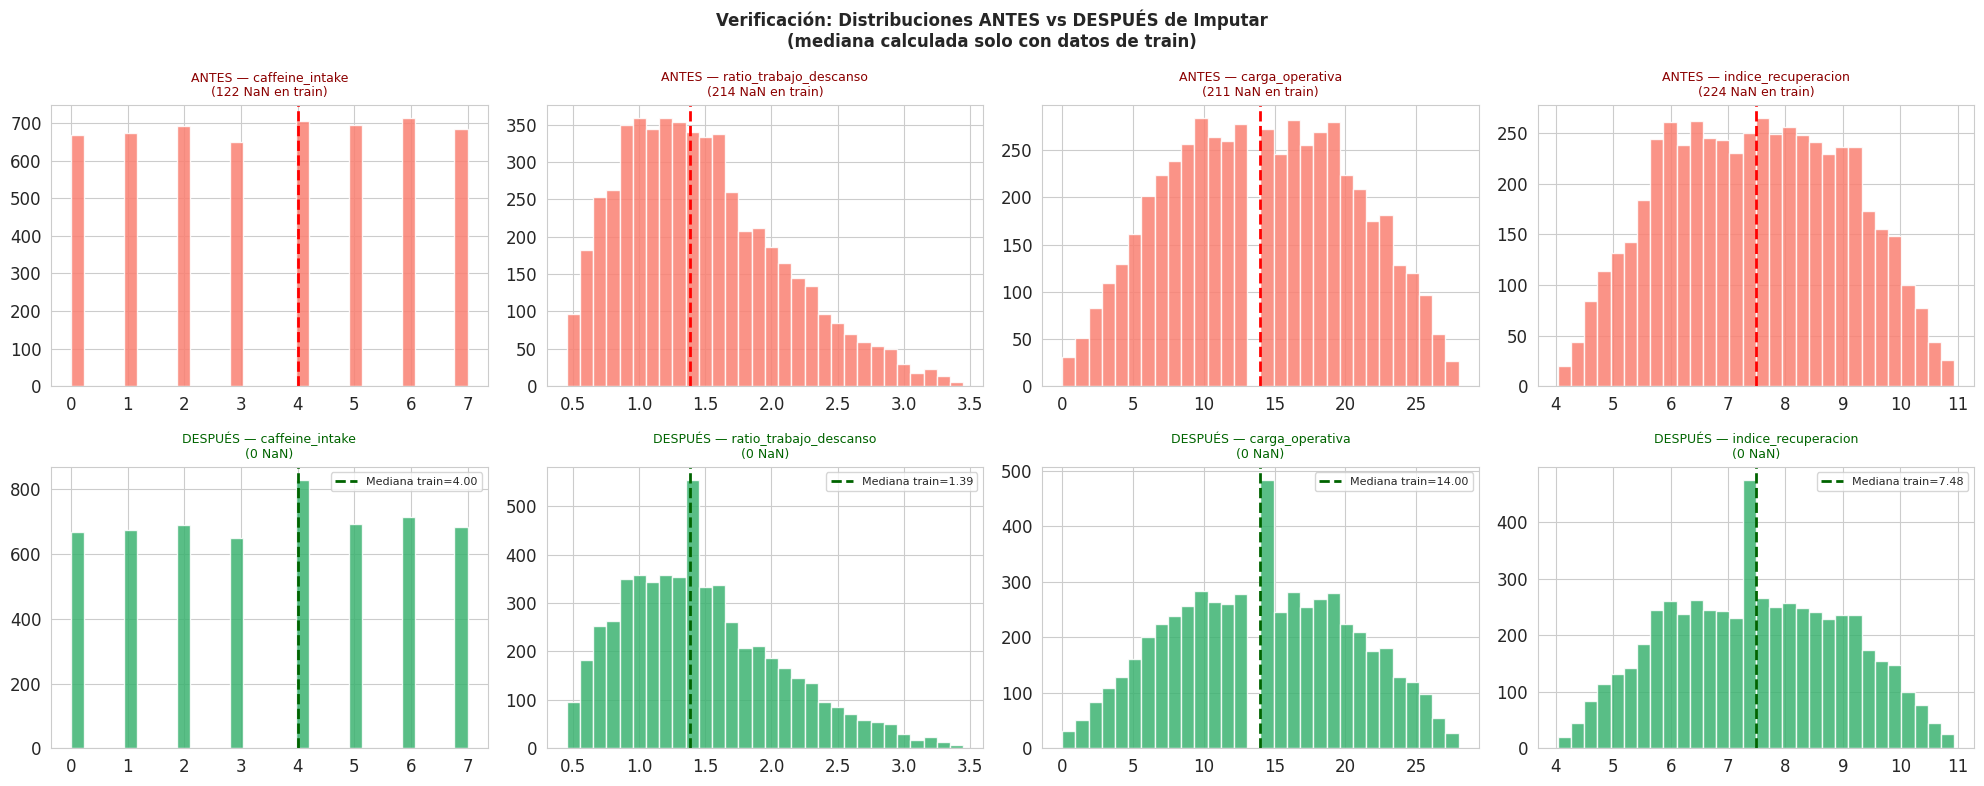

In [73]:
# VERIFICACIÓN — DISTRIBUCIONES ANTES vs DESPUÉS DE IMPUTAR

# Usar X_train (antes de imputar) y df_train_prep (después de imputar)
# Ambos provienen del mismo split — comparación honesta

nulos_antes    = X_train[num_cols_model].isnull().sum()
medianas_usadas = preprocessor.named_transformers_['num']['imputer'].statistics_
cols_con_nan   = [c for c in num_cols_model if nulos_antes.get(c, 0) > 0]

if cols_con_nan:
    n_c = len(cols_con_nan)
    fig, axes = plt.subplots(2, max(n_c, 1), figsize=(min(20, n_c*5), 8))
    if n_c == 1:
        axes = axes.reshape(2, 1)
    for i, col in enumerate(cols_con_nan):
        idx  = num_cols_model.index(col)
        med  = medianas_usadas[idx]
        # ANTES — valores originales en train (con NaN)
        axes[0, i].hist(X_train[col].dropna(), bins=30,
                        color='salmon', edgecolor='white', alpha=0.85)
        axes[0, i].axvline(X_train[col].median(), color='red',
                           linestyle='--', lw=2)
        axes[0, i].set_title(
            f'ANTES — {col}\n({nulos_antes[col]} NaN en train)',
            fontsize=9, color='darkred'
        )
        # DESPUÉS — valores imputados en train_prep
        axes[1, i].hist(df_train_prep[col], bins=30,
                        color='mediumseagreen', edgecolor='white', alpha=0.85)
        axes[1, i].axvline(med, color='darkgreen', linestyle='--',
                           lw=2, label=f'Mediana train={med:.2f}')
        axes[1, i].set_title(
            f'DESPUÉS — {col}\n(0 NaN)',
            fontsize=9, color='darkgreen'
        )
        axes[1, i].legend(fontsize=8)
    plt.suptitle(
        'Verificación: Distribuciones ANTES vs DESPUÉS de Imputar\n'
        '(mediana calculada solo con datos de train)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
else:
    print('ℹ️  No había columnas numéricas con NaN en train.')

## 🆕 Paso 5B: Diagnóstico automático de Scaler


Antes de escalar, se evalúa si los datos tienen outliers significativos:
- Si hay **outliers detectables** por IQR → se usa `RobustScaler` (resistente a extremos)
- Si la distribución es **relativamente normal** → se usa `StandardScaler` (z-score estándar)

Este diagnóstico se realiza automáticamente con criterio estadístico objetivo.

> 📌 **Nota sobre el test de Shapiro-Wilk:** con muestras de n=500 el test es muy
> sensible y rechazará H₀ (normalidad) incluso para distribuciones casi normales.
> En este dataset sintético con distribuciones uniformes, el test siempre
> detectará no-normalidad (p < 0.05), lo cual es correcto pero no implica
> asimetría severa. La decisión del scaler se basa principalmente en outliers
> y skewness, no en el p-valor de Shapiro.

In [74]:
# PASO 5B: DIAGNÓSTICO AUTOMÁTICO DE SCALER
# Evalúa outliers y distribución SOLO sobre datos de train
# para que la decisión del scaler no esté contaminada por val

print('🔍 Diagnóstico de outliers e idoneidad de scaler (solo train):')
print(f'{"Variable":<25} {"Outliers IQR":>12} {"% Outliers":>12} {"Skewness":>10} {"Shapiro p":>12}')
print('─' * 75)

total_outliers = 0
skew_extrema   = 0

for col in num_cols_model:
    serie   = df_train_prep[col].dropna()   # ← df_train_prep en lugar de df_imputed
    Q1, Q3  = serie.quantile(0.25), serie.quantile(0.75)
    IQR     = Q3 - Q1
    n_out   = ((serie < Q1 - 1.5*IQR) | (serie > Q3 + 1.5*IQR)).sum()
    pct_out = n_out / len(serie) * 100
    skew    = serie.skew()
    sample  = serie.sample(min(500, len(serie)), random_state=42)
    _, p_shapiro = shapiro(sample)
    total_outliers += n_out
    if abs(skew) > 1:
        skew_extrema += 1
    flag = '⚠️' if pct_out > 2 or abs(skew) > 1 else '✅'
    print(f'{flag} {col:<23} {n_out:>12} {pct_out:>11.1f}% {skew:>10.3f} {p_shapiro:>12.4f}')

pct_total_out = total_outliers / (len(df_train_prep) * len(num_cols_model)) * 100

n_train = len(df_train_prep)
print(f'\n📊 Resumen (calculado sobre {n_train} registros de train):')
print(f'   Outliers totales detectados: {total_outliers} ({pct_total_out:.2f}% del total de valores)')
print(f'   Variables con skewness > 1:  {skew_extrema}/{len(num_cols_model)}')

# Decisión automática
if pct_total_out > 2 or skew_extrema > len(num_cols_model) * 0.3:
    SCALER_ELEGIDO = RobustScaler()
    razon = 'RobustScaler: outliers o asimetría detectada → resistente a extremos'
    print(f'\n🔶 {razon}')
else:
    SCALER_ELEGIDO = StandardScaler()
    razon = 'StandardScaler: distribución normal, sin outliers significativos'
    print(f'\n🟢 {razon}')

print(f'\n✅ Scaler seleccionado: {type(SCALER_ELEGIDO).__name__}')
print('   (calibrado y evaluado exclusivamente sobre datos de train)')

🔍 Diagnóstico de outliers e idoneidad de scaler (solo train):
Variable                  Outliers IQR   % Outliers   Skewness    Shapiro p
───────────────────────────────────────────────────────────────────────────
✅ caffeine_intake                    0         0.0%     -0.038       0.0000
✅ ratio_trabajo_descanso            68         1.2%      0.686       0.0000
✅ carga_operativa                    0         0.0%      0.012       0.0000
✅ indice_recuperacion                0         0.0%      0.016       0.0002

📊 Resumen (calculado sobre 5600 registros de train):
   Outliers totales detectados: 68 (0.30% del total de valores)
   Variables con skewness > 1:  0/4

🟢 StandardScaler: distribución normal, sin outliers significativos

✅ Scaler seleccionado: StandardScaler
   (calibrado y evaluado exclusivamente sobre datos de train)


In [75]:
# PASO 5C: ESCALADO ADAPTATIVO
# ✅ fit solo en train, transform en ambos
# Garantiza que la calibración del scaler no vea datos de validación

SCALER_ELEGIDO.fit(df_train_prep)
X_train_scaled = SCALER_ELEGIDO.transform(df_train_prep)
X_val_scaled   = SCALER_ELEGIDO.transform(df_val_prep)

# Alias para compatibilidad con el resto del notebook (Pasos 6 en adelante)
X_scaled  = X_train_scaled   # alias explícito — representa SOLO el split de train
df_scaled = pd.DataFrame(X_train_scaled, columns=FEATURES_MODEL)
pct_train = len(X_train) / len(df_model) * 100
print(f'⚠️  X_scaled = X_train_scaled — representa el split de entrenamiento ({pct_train:.0f}%)')
print(f'   Para validación usar X_val_scaled ({X_val_scaled.shape[0]} registros)')

print(f'✅ Escalado con {type(SCALER_ELEGIDO).__name__}')
print(f'   Ajustado con        : {len(df_train_prep)} registros (solo train)')
print(f'   μ post-escalado train: {X_train_scaled.mean():.8f}')
print(f'   σ post-escalado train: {X_train_scaled.std():.8f}')
print(f'   μ post-escalado val  : {X_val_scaled.mean():.4f}  (≠0 esperado)')
print(f'   σ post-escalado val  : {X_val_scaled.std():.4f}')
print()
display(df_scaled.describe().round(3))


⚠️  X_scaled = X_train_scaled — representa el split de entrenamiento (80%)
   Para validación usar X_val_scaled (1400 registros)
✅ Escalado con StandardScaler
   Ajustado con        : 5600 registros (solo train)
   μ post-escalado train: -0.00000000
   σ post-escalado train: 1.00000000
   μ post-escalado val  : -0.0052  (≠0 esperado)
   σ post-escalado val  : 0.9782



,caffeine_intake,ratio_trabajo_descanso,carga_operativa,indice_recuperacion
count,5600.000,5600.000,5600.000,5600.000
mean,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000
min,-1.565,-1.733,-2.198,-2.265
25%,-0.682,-0.761,-0.787,-0.786
50%,0.202,-0.142,-0.003,0.004
75%,0.643,0.597,0.781,0.780
max,1.527,3.363,2.192,2.279


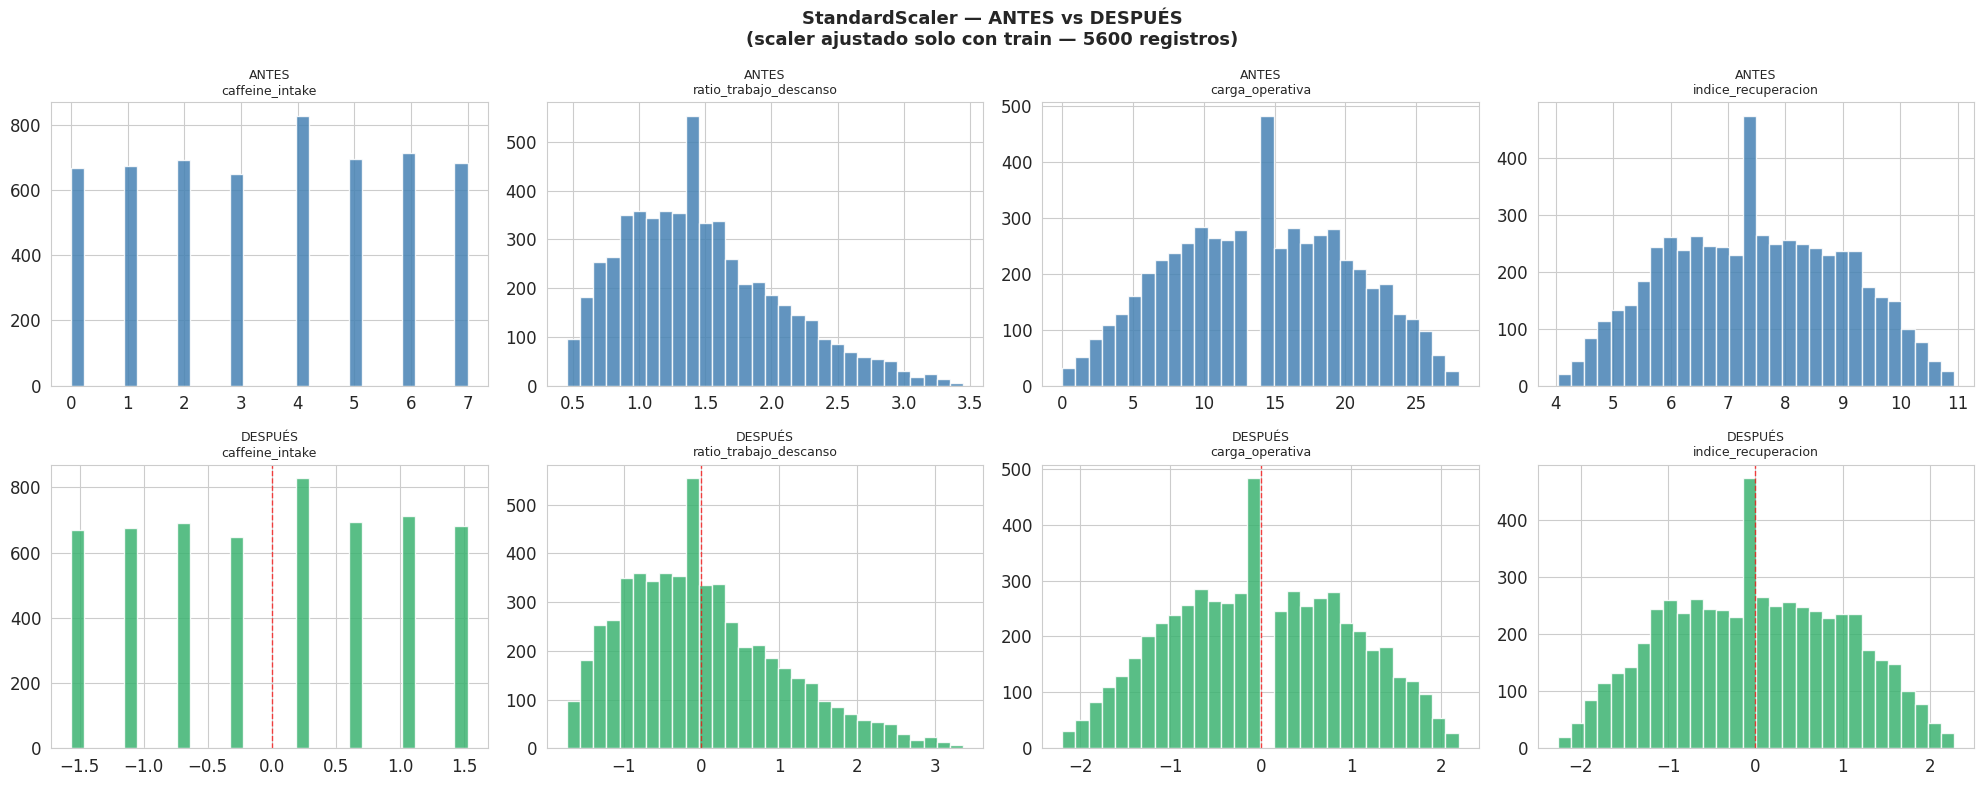

In [76]:
# PASO 5D: VERIFICACION VISUAL
# Visualización ANTES vs DESPUÉS del escalado
cols_viz = FEATURES_MODEL[:6]
fig, axes = plt.subplots(2, len(cols_viz), figsize=(20, 8))
for i, col in enumerate(cols_viz):
    axes[0, i].hist(df_train_prep[col], bins=30,        # ← df_train_prep
                    color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'ANTES\n{col}', fontsize=9)
    axes[1, i].hist(df_scaled[col], bins=30,
                    color='mediumseagreen', edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'DESPUÉS\n{col}', fontsize=9)
    axes[1, i].axvline(0, color='red', linestyle='--', lw=1, alpha=0.7)

plt.suptitle(
    f'{type(SCALER_ELEGIDO).__name__} — ANTES vs DESPUÉS\n'
    f'(scaler ajustado solo con train — {len(df_train_prep)} registros)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# **6 - Selección del mejor número de clusters ( k óptimo ) para K-Means. (rango ampliado: 2–12)**
K-Means necesita que le digamos cuántos grupos queremos.Ese número se llama k.
El notebook prueba valores de: k = 2 hasta k = 12
## **6a) Evaluación de k=2 A k=12 con 4 métricas**
Evalúa cada opción con **4 métricas** y se construye un **ranking combinado** para seleccionar k con evidencia objetiva:

| Métrica | Mejor | Qué mide | Explicación |
|---|---|---|---|
| Inercia (Codo) | Punto de quiebre | Suma distancias² al centroide | Mide qué tan cerca están los puntos de su centroide. <br>Menor inercia suele ser mejor, pero no basta con elegir la menor, porque siempre baja al aumentar k.<br>Por eso se usa el método del codo.
| Silhouette | Máximo [−1,+1] | Cohesión vs separación | Mide qué tan bien separado está cada cluster.<br>Va de -1 a 1. <br>* cercano a 1: clusters bien separados<br>* cercano a 0: clusters mezclados<br>* negativo: puntos posiblemente mal agrupados. |
| Davies-Bouldin | Mínimo [0,∞) | Similitud entre clusters | Mide qué tan parecidos son los clusters entre sí. <br>**Aquí, menor es mejor.** |
| Calinski-Harabasz | Máximo [0,∞) | Ratio varianza inter/intra | Mide separación entre clusters frente a compactación interna. <br>**Aquí, mayot es mejor.** |

## **6b) Visualización gráfica de 4 métricas**

> 📐 **Detección automática del codo:** Se calcula la segunda derivada de la inercia
> (`np.diff` aplicado dos veces). El punto donde la segunda derivada es máxima en
> valor absoluto indica el mayor cambio de curvatura — ese es el codo. El índice
> se desplaza +2 para compensar la reducción de longitud del array por el doble `diff`.


## **6c) Ranking combinado + selección automática de k**


In [77]:
# PASO 6A: EVALUACIÓN K=2 A 12 — 4 MÉTRICAS
# Calculadas sobre X_train_scaled (datos de entrenamiento)

# NOTA: X_scaled = X_train_scaled — solo registros de entrenamiento
# X_val_scaled disponible para validación posterior

K_RANGE = range(2, 13)
inercias, silhouettes, davies_bouldins, calinski_list = [], [], [], []

print(f'📊 Métricas evaluadas sobre {len(X_scaled)} registros de train')
print()
print(f'{"k":>3} | {"Inercia":>12} | {"Silhouette":>10} | {"Davies-B":>10} | {"Calinski":>12}')
print('─' * 55)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15,
                max_iter=500, random_state=42)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    davies_bouldins.append(davies_bouldin_score(X_scaled, labels))
    calinski_list.append(calinski_harabasz_score(X_scaled, labels))
    print(f'{k:>3} | {inercias[-1]:>12.2f} | {silhouettes[-1]:>10.4f} | '
          f'{davies_bouldins[-1]:>10.4f} | {calinski_list[-1]:>12.2f}')

📊 Métricas evaluadas sobre 5600 registros de train

  k |      Inercia | Silhouette |   Davies-B |     Calinski
───────────────────────────────────────────────────────
  2 |     16597.30 |     0.2401 |     1.5920 |      1957.16
  3 |     13787.72 |     0.2160 |     1.5043 |      1748.04
  4 |     11902.33 |     0.2125 |     1.3256 |      1645.20
  5 |     10591.85 |     0.2092 |     1.3686 |      1559.39
  6 |      9618.29 |     0.2029 |     1.2645 |      1486.77
  7 |      8841.47 |     0.2011 |     1.2751 |      1429.50
  8 |      8211.21 |     0.2012 |     1.2629 |      1380.43
  9 |      7716.43 |     0.2028 |     1.2315 |      1329.89
 10 |      7295.06 |     0.1950 |     1.2513 |      1286.06
 11 |      6950.95 |     0.1908 |     1.2703 |      1242.21
 12 |      6658.63 |     0.1947 |     1.2547 |      1200.95


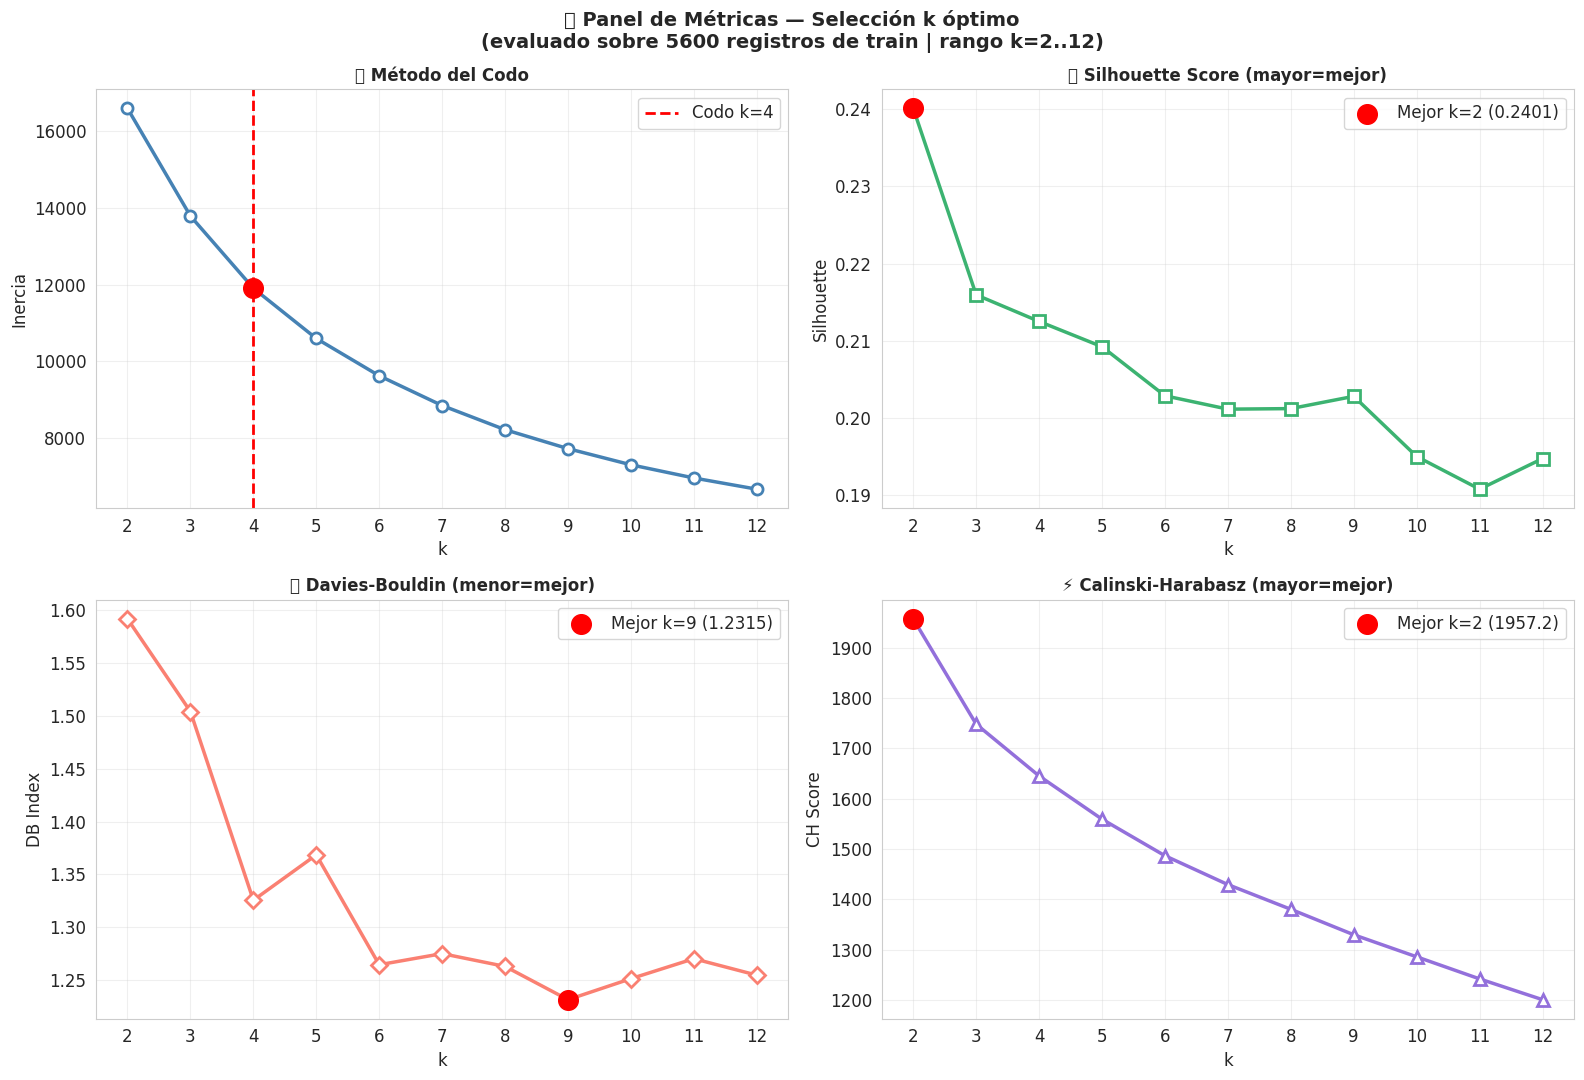

In [78]:
# PASO 6B: PANEL DE 4 MÉTRICAS
# NOTA: X_scaled = X_train_scaled — solo registros de entrenamiento
# X_val_scaled disponible para validación posterior

ks     = list(K_RANGE)
diffs2 = np.diff(np.diff(inercias))
codo_k = ks[np.argmax(np.abs(diffs2)) + 2]
k_sil  = ks[np.argmax(silhouettes)]
k_db   = ks[np.argmin(davies_bouldins)]
k_ch   = ks[np.argmax(calinski_list)]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0,0].plot(ks, inercias, 'o-', color='steelblue', lw=2.5, ms=8,
               markerfacecolor='white', markeredgewidth=2)
axes[0,0].axvline(codo_k, color='red', linestyle='--', lw=2,
                  label=f'Codo k={codo_k}')
axes[0,0].scatter([codo_k], [inercias[ks.index(codo_k)]],
                  color='red', s=200, zorder=5)
axes[0,0].set_title('📐 Método del Codo', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inercia')
axes[0,0].set_xticks(ks); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ks, silhouettes, 's-', color='mediumseagreen', lw=2.5, ms=8,
               markerfacecolor='white', markeredgewidth=2)
axes[0,1].scatter([k_sil], [max(silhouettes)], color='red', s=200, zorder=5,
                  label=f'Mejor k={k_sil} ({max(silhouettes):.4f})')
axes[0,1].set_title('🏆 Silhouette Score (mayor=mejor)',
                    fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Silhouette')
axes[0,1].set_xticks(ks); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(ks, davies_bouldins, 'D-', color='salmon', lw=2.5, ms=8,
               markerfacecolor='white', markeredgewidth=2)
axes[1,0].scatter([k_db], [min(davies_bouldins)], color='red', s=200, zorder=5,
                  label=f'Mejor k={k_db} ({min(davies_bouldins):.4f})')
axes[1,0].set_title('📉 Davies-Bouldin (menor=mejor)',
                    fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('DB Index')
axes[1,0].set_xticks(ks); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ks, calinski_list, '^-', color='mediumpurple', lw=2.5, ms=8,
               markerfacecolor='white', markeredgewidth=2)
axes[1,1].scatter([k_ch], [max(calinski_list)], color='red', s=200, zorder=5,
                  label=f'Mejor k={k_ch} ({max(calinski_list):.1f})')
axes[1,1].set_title('⚡ Calinski-Harabasz (mayor=mejor)',
                    fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('CH Score')
axes[1,1].set_xticks(ks); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.suptitle(
    f'📊 Panel de Métricas — Selección k óptimo\n'
    f'(evaluado sobre {len(X_scaled)} registros de train | rango k=2..12)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 📊 Paso 6B.1 — Construcción del ranking combinado

Se normalizan las tres métricas al rango [0,1] para hacerlas comparables entre sí
y calcular un score combinado que permita desempatar cuando las métricas individuales
señalan k distintos.

**Criterio de normalización:**
- Silhouette y Calinski-Harabasz: mayor es mejor → se invierte para que menor score = mejor
- Davies-Bouldin: menor es mejor → se usa directo

El k con **menor Score_Combinado** es el candidato óptimo por ranking.

In [79]:
# PASO 6B.1: Construcción del ranking combinado — requerido para Paso 6C
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df_met = pd.DataFrame({
    'k': list(K_RANGE),
    'Inercia': inercias,
    'Silhouette': silhouettes,
    'Davies_Bouldin': davies_bouldins,
    'Calinski': calinski_list
})

# Normalizar métricas al rango [0,1]
# Silhouette y Calinski: mayor es mejor → invertir para ranking (menor=mejor)
# Davies-Bouldin: menor es mejor → directo
scaler_rank = MinMaxScaler()
df_met['Sil_norm'] = 1 - scaler_rank.fit_transform(df_met[['Silhouette']])
df_met['DB_norm']  = scaler_rank.fit_transform(df_met[['Davies_Bouldin']])
df_met['CH_norm']  = 1 - scaler_rank.fit_transform(df_met[['Calinski']])

df_met['Score_Combinado'] = (df_met['Sil_norm'] + df_met['DB_norm'] + df_met['CH_norm']) / 3

print("📋 Ranking combinado de métricas:")
display(df_met[['k', 'Silhouette', 'Davies_Bouldin', 'Calinski', 'Score_Combinado']].sort_values('Score_Combinado').round(4))

📋 Ranking combinado de métricas:


,k,Silhouette,Davies_Bouldin,Calinski,Score_Combinado
0,2,0.2401,1.5920,1957.1605,0.3333
2,4,0.2125,1.3256,1645.1993,0.4110
4,6,0.2029,1.2645,1486.7743,0.4895
1,3,0.2160,1.5043,1748.0436,0.5076
3,5,0.2092,1.3686,1559.3859,0.5107
7,9,0.2028,1.2315,1329.8872,0.5286
5,7,0.2011,1.2751,1429.4975,0.5362
6,8,0.2012,1.2629,1380.4267,0.5461
8,10,0.1950,1.2513,1286.0625,0.6189
10,12,0.1947,1.2547,1200.9544,0.6613


In [80]:
# PASO 6C: RANKING COMBINADO + SELECCIÓN AUTOMÁTICA

# Votación entre las 3 métricas con óptimo real
votos       = Counter([k_sil, k_db, k_ch])
mejor_score = df_met.loc[df_met['Score_Combinado'].idxmin(), 'k']

# Verificar si Davies-Bouldin tiene diferencia prácticamente significativa
db_min   = min(davies_bouldins)
db_k2    = davies_bouldins[0]   # valor en k=2
diff_db  = abs(db_k2 - db_min)

print(f'\nVotos: Silhouette={k_sil} | Davies-B={k_db} | Calinski={k_ch}')
print(f'Codo (referencia visual): {codo_k}')
print()
print(f'📋 Análisis Davies-Bouldin:')
print(f'   DB en k=2       : {db_k2:.4f}')
print(f'   DB mínimo (k={k_db}): {db_min:.4f}')
print(f'   Diferencia      : {diff_db:.4f}')

# Si la diferencia de DB entre k óptimo y k=2 es menor a 0.05
# se considera que no hay ventaja práctica real en k alto
UMBRAL_DB = 0.05
if diff_db < UMBRAL_DB:
    print(f'   ⚠️  Diferencia < {UMBRAL_DB} → Davies-Bouldin no tiene ventaja')
    print(f'       práctica real en k={k_db}. Se excluye del voto.')
    votos_ajustados = Counter([k_sil, k_ch])
else:
    print(f'   ✅ Diferencia significativa → Davies-Bouldin voto válido')
    votos_ajustados = votos

if votos_ajustados.most_common(1)[0][1] >= 2:
    K_OPTIMO = votos_ajustados.most_common(1)[0][0]
    criterio = 'mayoría en votación (DB ajustado)'
else:
    K_OPTIMO = int(mejor_score)
    criterio = 'ranking combinado (desempate)'

print(f'\n✅ K ÓPTIMO SELECCIONADO: k = {K_OPTIMO}  ({criterio})')
print(f'   (ajusta manualmente si el negocio requiere otro número de perfiles)')


Votos: Silhouette=2 | Davies-B=9 | Calinski=2
Codo (referencia visual): 4

📋 Análisis Davies-Bouldin:
   DB en k=2       : 1.5920
   DB mínimo (k=9): 1.2315
   Diferencia      : 0.3605
   ✅ Diferencia significativa → Davies-Bouldin voto válido

✅ K ÓPTIMO SELECCIONADO: k = 2  (mayoría en votación (DB ajustado))
   (ajusta manualmente si el negocio requiere otro número de perfiles)


In [81]:
# Comparar k=2 vs k=3 — ¿k=3 agrega valor real?

print("Comparativa k=2 vs k=3:")
print(f"{'Métrica':<20} {'k=2':>10} {'k=3':>10} {'Diferencia':>12}")
print("-" * 55)

for k_comp in [2, 3]:
    km_comp = KMeans(n_clusters=k_comp, init='k-means++',
                     n_init=15, random_state=42)
    labels_comp = km_comp.fit_predict(X_scaled)

    sil_comp = silhouette_score(X_scaled, labels_comp)
    db_comp  = davies_bouldin_score(X_scaled, labels_comp)
    ch_comp  = calinski_harabasz_score(X_scaled, labels_comp)

    if k_comp == 2:
        sil_2, db_2, ch_2 = sil_comp, db_comp, ch_comp
        print(f"{'Silhouette':<20} {sil_comp:>10.4f}")
        print(f"{'Davies-Bouldin':<20} {db_comp:>10.4f}")
        print(f"{'Calinski-H':<20} {ch_comp:>10.1f}")
    else:
        print()
        print(f"{'Silhouette':<20} {sil_2:>10.4f} {sil_comp:>10.4f} "
              f"{sil_comp - sil_2:>+12.4f}")
        print(f"{'Davies-Bouldin':<20} {db_2:>10.4f} {db_comp:>10.4f} "
              f"{db_comp - db_2:>+12.4f}")
        print(f"{'Calinski-H':<20} {ch_2:>10.1f} {ch_comp:>10.1f} "
              f"{ch_comp - ch_2:>+12.1f}")

print()
print("Interpretación:")
print("  Silhouette: si k=3 baja mucho → k=3 fragmenta un grupo natural")
print("  Davies-B  : si k=3 sube → k=3 produce clusters más similares entre sí")
print("  Calinski  : si k=3 baja → k=3 pierde separación entre grupos")

Comparativa k=2 vs k=3:
Métrica                     k=2        k=3   Diferencia
-------------------------------------------------------
Silhouette               0.2401
Davies-Bouldin           1.5920
Calinski-H               1957.2

Silhouette               0.2401     0.2160      -0.0242
Davies-Bouldin           1.5920     1.5043      -0.0878
Calinski-H               1957.2     1748.0       -209.1

Interpretación:
  Silhouette: si k=3 baja mucho → k=3 fragmenta un grupo natural
  Davies-B  : si k=3 sube → k=3 produce clusters más similares entre sí
  Calinski  : si k=3 baja → k=3 pierde separación entre grupos


## ✅ Decisión final: k=2

La comparativa k=2 vs k=3 confirma que k=2 es el número óptimo
de clusters para este dataset.

> 📋 **Nota:** Los valores exactos de las métricas dependen del espacio de features
> definido en el Paso 4B y pueden variar entre ejecuciones. Consultar la salida
> impresa de la celda de comparativa k=2 vs k=3 para los valores actuales.
> La decisión de k se basa en el ranking combinado del Paso 6C, no en valores fijos.

**Interpretación de negocio:**
Con las variables de comportamiento y hábitos (sin leakage),
los desarrolladores se separan en dos perfiles reales:

- 🔴 **Perfil de riesgo:** alta carga operativa, bajo índice
  de recuperación, alto ratio trabajo/descanso
- 🟢 **Perfil equilibrado:** carga moderada, buenos hábitos
  de descanso y ejercicio, productividad neta positiva

k=3 no agrega un tercer perfil genuino — fragmenta uno de
los dos grupos naturales en mitades arbitrarias.

## **🔵 7- Entrenamiento final K-Means**
## **7a) Modelado K-Means Final**
* Después de elegir el mejor k, el notebook entrena el modelo final:  KMeans(n_clusters=K_OPTIMO)
* El resultado es una nueva columna: Cluster_KMeans
* Cada desarrollador queda asignado a un cluster. Ejemplo: <br> Desarrollador 1 → Cluster 0<br>
Desarrollador 2 → Cluster 2<br>
Desarrollador 3 → Cluster 1
* Estos clusters no tienen nombre automáticamente. El analista debe interpretarlos.

## **7b) Gráfico HeatMap de Centroides - Interpretación de centroides**
* Un centroide es el “punto promedio” de cada cluster.
* El notebook crea un heatmap de centroides.
* Este gráfico permite ver qué variables están altas o bajas en cada grupo.

Por ejemplo:
| Cluster | Variables altas (verde) | Variables bajas (rojo) | Posible interpretación |
|---|---|---|---|
| Cluster 0 | `ratio_trabajo_descanso`, `carga_operativa`, `caffeine_intake` | `indice_recuperacion`, `productividad_neta` | 🔴 Alto riesgo — alta carga, baja recuperación |
| Cluster 1 | `indice_recuperacion`, `productividad_neta` | `ratio_trabajo_descanso`, `carga_operativa` | 🟢 Bajo riesgo — equilibrio y buena recuperación |

**Aquí entra el criterio analítico humano.**
El modelo crea los grupos, pero el humano les da significado.

In [82]:
# PASO 7A: MODELO K-MEANS FINAL
# Entrenado sobre X_train_scaled — datos de entrenamiento únicamente

kmeans_final = KMeans(n_clusters=K_OPTIMO, init='k-means++',
                      n_init=20, max_iter=500, random_state=42)
cluster_labels_km = kmeans_final.fit_predict(X_scaled)  # X_scaled = X_train_scaled
centroides_scaled  = kmeans_final.cluster_centers_

# Invertir escalado para interpretar centroides en escala original
centroides_original = SCALER_ELEGIDO.inverse_transform(centroides_scaled)

colores = plt.cm.tab10(np.linspace(0, 1, K_OPTIMO))

sil_final = silhouette_score(X_scaled, cluster_labels_km)
db_final  = davies_bouldin_score(X_scaled, cluster_labels_km)
ch_final  = calinski_harabasz_score(X_scaled, cluster_labels_km)

print(f'✅ K-Means final entrenado sobre {len(X_scaled)} registros (train)')
print(f'   k                  : {K_OPTIMO}')
print(f'   Inercia            : {kmeans_final.inertia_:.4f}')
print(f'   Silhouette         : {sil_final:.4f}')
print(f'   Davies-Bouldin     : {db_final:.4f}')
print(f'   Calinski-Harabasz  : {ch_final:.2f}')
print()
print('Distribución de clusters en train:')
for c, n in pd.Series(cluster_labels_km).value_counts().sort_index().items():
    print(f'   Cluster {c}: {n} ({n/len(cluster_labels_km)*100:.1f}%) '
          f'{"█"*int(n/len(cluster_labels_km)*50)}')

print()
print(f'📊 Validación sobre {len(X_val_scaled)} registros (val — no vistos en entrenamiento):')
cluster_labels_val = kmeans_final.predict(X_val_scaled)
sil_val = silhouette_score(X_val_scaled, cluster_labels_val)
db_val  = davies_bouldin_score(X_val_scaled, cluster_labels_val)
print(f'   Silhouette val     : {sil_val:.4f}')
print(f'   Davies-Bouldin val : {db_val:.4f}')
print()

# Diferencia train vs val — detectar overfitting
diff_sil = abs(sil_final - sil_val)
print(f'   Diferencia Silhouette train/val: {diff_sil:.4f}')
if diff_sil < 0.05:
    print('   ✅ Diferencia < 0.05 — modelo generaliza correctamente')
else:
    print('   ⚠️  Diferencia > 0.05 — revisar estabilidad del clustering')

✅ K-Means final entrenado sobre 5600 registros (train)
   k                  : 2
   Inercia            : 16597.2956
   Silhouette         : 0.2401
   Davies-Bouldin     : 1.5920
   Calinski-Harabasz  : 1957.16

Distribución de clusters en train:
   Cluster 0: 3384 (60.4%) ██████████████████████████████
   Cluster 1: 2216 (39.6%) ███████████████████

📊 Validación sobre 1400 registros (val — no vistos en entrenamiento):
   Silhouette val     : 0.2390
   Davies-Bouldin val : 1.6066

   Diferencia Silhouette train/val: 0.0011
   ✅ Diferencia < 0.05 — modelo generaliza correctamente


📍 Centroides (escala original):


,caffeine_intake,ratio_trabajo_descanso,carga_operativa,indice_recuperacion
0,3.56,1.14,13.88,8.39
1,3.52,1.98,14.23,6.08


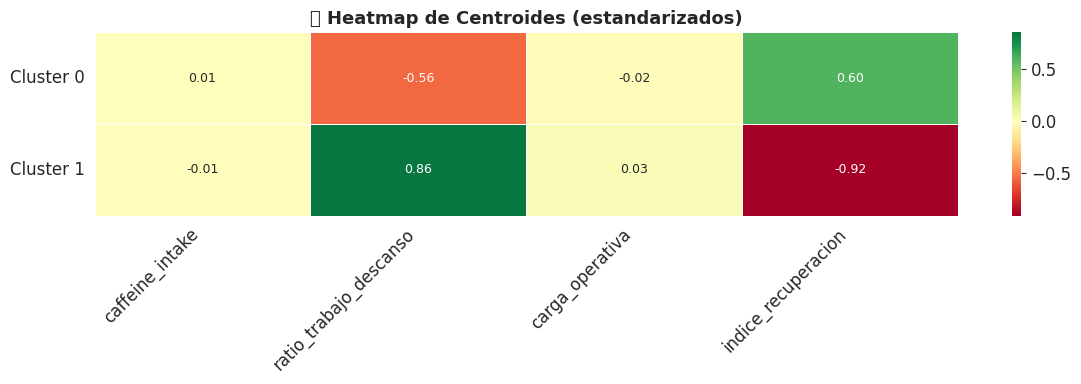


Verde=alto | Rojo=bajo | Blanco=cercano a media global

📋 Guía de interpretación — variables del espacio final del modelo:
   caffeine_intake                → alto → compensación energética elevada
   ratio_trabajo_descanso         → alto → jornadas largas con poco sueño (desequilibrio)
   carga_operativa                → alta → muchos bugs + reuniones (presión técnica y social)
   indice_recuperacion            → bajo → poco sueño y ejercicio (sin recuperación)


In [83]:
# PASO 7B: HEATMAP DE CENTROIDES
# FEATURES_MODEL contiene las variables del modelo actual (7 variables)

df_centroides = pd.DataFrame(centroides_original, columns=FEATURES_MODEL)
print('📍 Centroides (escala original):')
display(df_centroides.round(2))

fig, ax = plt.subplots(figsize=(max(12, len(FEATURES_MODEL)*1.2),
                                max(4, K_OPTIMO*1.2)))
sns.heatmap(
    pd.DataFrame(centroides_scaled, columns=FEATURES_MODEL),
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('🗺️ Heatmap de Centroides (estandarizados)',
             fontsize=13, fontweight='bold')
ax.set_yticklabels([f'Cluster {i}' for i in range(K_OPTIMO)], rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print()
print('Verde=alto | Rojo=bajo | Blanco=cercano a media global')
print()
print('📋 Guía de interpretación — variables del espacio final del modelo:')
for feat in FEATURES_MODEL:
    descripciones = {
        'caffeine_intake'         : 'alto → compensación energética elevada',
        'ratio_trabajo_descanso'  : 'alto → jornadas largas con poco sueño (desequilibrio)',
        'carga_operativa'         : 'alta → muchos bugs + reuniones (presión técnica y social)',
        'indice_recuperacion'     : 'bajo → poco sueño y ejercicio (sin recuperación)',
    }
    desc = descripciones.get(feat, 'ver heatmap para interpretación')
    print(f'   {feat:<30} → {desc}')

## 🆕 **8 - Etiquetado con criterio de negocio**
El código asigna etiquetas de forma automática comparando los centroides por `ratio_trabajo_descanso` (la variable con mayor poder de separación entre clusters).

Si al analizar el heatmap del Paso 7B detecta que otra variable discrimina mejor entre grupos, reemplaza la clave de ordenación en el diccionario `ETIQUETAS` con ese criterio. El etiquetado automático es un punto de partida, no una conclusión definitiva.
Aquí se hace una validación contra burnout_level:<br>
Aunque burnout_level no se usa para entrenar, sí se usa después para validar.

El notebook compara: Cluster_KMeans vs burnout_level<br>
Esto responde: **¿Los grupos encontrados por el modelo coinciden con niveles reales de burnout?**

Por ejemplo, si el Cluster 2 tiene mayoría de personas con burnout alto, entonces el cluster tiene sentido.

**Esto no es entrenamiento supervisado, es validación posterior.**


## 🏷️ Guía para Interpretar y Actualizar las Etiquetas de Cluster

> ⚠️ **Instrucción clave:** Las etiquetas del diccionario `ETIQUETAS` deben ajustarse **cada vez que ejecutes el notebook**, ya que dependen del `k` óptimo calculado y de los valores reales de los centroides.

### ¿Cómo leer el heatmap de centroides para etiquetar?

El heatmap muestra los valores **estandarizados** (z-score) de cada variable en cada cluster:
- 🟢 **Verde intenso** = esa variable está **muy por encima** del promedio global en ese cluster
- 🔴 **Rojo intenso** = esa variable está **muy por debajo** del promedio global
- ⚪ **Blanco/amarillo** = cercano al promedio global (no es característica distintiva)

### Ejemplo de interpretación con k=2 (resultado típico de este dataset)

| Cluster | Variables altas (verde) | Variables bajas (rojo) | Etiqueta sugerida |
|---|---|---|---|
| **Cluster 0** | `ratio_trabajo_descanso` alto, `carga_operativa` alta, `caffeine_intake` alto | `indice_recuperacion` bajo | 🔴 **Perfil Sobrecargado** — desequilibrio carga/recuperación, alto riesgo |
| **Cluster 1** | `indice_recuperacion` alto | `ratio_trabajo_descanso` bajo, `carga_operativa` baja, `caffeine_intake` moderado | 🟢 **Perfil Equilibrado** — buena recuperación, carga moderada |


### Validación con burnout_level (después del entrenamiento)

Una vez asignadas las etiquetas, la tabla de distribución de `burnout_level` por cluster te dirá si el modelo tiene coherencia con la realidad:
- Si el **Cluster Sobrecargado** tiene mayoría de `burnout_level = 'High'` → el modelo capturó el patrón real ✅
- Si la distribución es uniforme en todos los clusters → el modelo no logró separar bien los grupos ⚠️


In [84]:
# PASO 8: PERFILES POR CLUSTER Y ETIQUETADO
# Se trabaja sobre train y val por separado para mantener
# la integridad del split

# Construir dataframes de resultados
df_train_resultado = X_train.copy()
df_train_resultado['Cluster_KMeans'] = cluster_labels_km
df_train_resultado['burnout_level']  = burnout_train.values

df_val_resultado = X_val.copy()
df_val_resultado['Cluster_KMeans'] = cluster_labels_val
df_val_resultado['burnout_level']  = burnout_val.values

# Combinar para análisis general
df_resultado = pd.concat([df_train_resultado, df_val_resultado])

print('📊 PERFIL POR CLUSTER (medias — escala original):')
cols_perfil = [c for c in FEATURES_MODEL if c in df_resultado.columns]
display(df_resultado.groupby('Cluster_KMeans')[cols_perfil].mean().round(2))

print()

# Distribución de burnout_level por cluster — SOLO VALIDACIÓN EXTERNA
print('📌 Distribución burnout_level por cluster:')
print('   (referencia de validación — NO usada en el modelo)')
print()
print('   TRAIN:')
display(
    pd.crosstab(df_train_resultado['Cluster_KMeans'],
                df_train_resultado['burnout_level'],
                normalize='index').round(3) * 100
)
print()
print('   VALIDACIÓN:')
display(
    pd.crosstab(df_val_resultado['Cluster_KMeans'],
                df_val_resultado['burnout_level'],
                normalize='index').round(3) * 100
)
print()
print('✅ Si la distribución de train y val es similar →')
print('   el modelo captura patrones reales, no ruido del train')

📊 PERFIL POR CLUSTER (medias — escala original):


,caffeine_intake,ratio_trabajo_descanso,carga_operativa,indice_recuperacion
Cluster_KMeans,,,,
0,3.54,1.12,13.87,8.46
1,3.54,1.97,14.25,6.07



📌 Distribución burnout_level por cluster:
   (referencia de validación — NO usada en el modelo)

   TRAIN:


burnout_level,High,Low,Medium
Cluster_KMeans,,,
0,16.4,32.7,50.9
1,42.4,8.4,49.2



   VALIDACIÓN:


burnout_level,High,Low,Medium
Cluster_KMeans,,,
0,13.4,31.9,54.7
1,39.0,10.2,50.7



✅ Si la distribución de train y val es similar →
   el modelo captura patrones reales, no ruido del train


In [85]:
# ETIQUETADO BASADO EN CENTROIDES
# ⚠️ Analiza el heatmap del Paso 7B y ajusta según los valores reales

# Identificar automáticamente el cluster de mayor y menor riesgo
perfil_clusters = df_resultado.groupby('Cluster_KMeans')[cols_perfil].mean()

# El cluster de mayor riesgo tiene:
# ratio_trabajo_descanso alto + indice_recuperacion bajo
if 'ratio_trabajo_descanso' in perfil_clusters.columns:
    cluster_alto = perfil_clusters['ratio_trabajo_descanso'].idxmax()
    cluster_bajo = perfil_clusters['ratio_trabajo_descanso'].idxmin()
else:
    cluster_alto = 0
    cluster_bajo = 1

ETIQUETAS = {}
for c in range(K_OPTIMO):
    if c == cluster_alto:
        ETIQUETAS[c] = '🔴 Alto Riesgo — alta carga, bajo índice de recuperación'
    elif c == cluster_bajo:
        ETIQUETAS[c] = '🟢 Bajo Riesgo — carga moderada, buenos hábitos'
    else:
        ETIQUETAS[c] = '🟡 Riesgo Moderado — señales tempranas'

CLUSTER_LABELS = {i: ETIQUETAS.get(i, f'Cluster {i}') for i in range(K_OPTIMO)}

df_resultado['Perfil_Burnout'] = df_resultado['Cluster_KMeans'].map(CLUSTER_LABELS)

print('🏷️ Etiquetas asignadas automáticamente desde centroides:')
print()
for k, label in CLUSTER_LABELS.items():
    n     = (df_resultado['Cluster_KMeans'] == k).sum()
    n_tr  = (df_train_resultado['Cluster_KMeans'] == k).sum()
    n_val = (df_val_resultado['Cluster_KMeans'] == k).sum()
    print(f'  Cluster {k} → {label}')
    print(f'             Total: {n} | Train: {n_tr} | Val: {n_val}')
    print()

🏷️ Etiquetas asignadas automáticamente desde centroides:

  Cluster 0 → 🟢 Bajo Riesgo — carga moderada, buenos hábitos
             Total: 4238 | Train: 3384 | Val: 854

  Cluster 1 → 🔴 Alto Riesgo — alta carga, bajo índice de recuperación
             Total: 2762 | Train: 2216 | Val: 546



In [86]:
# VALIDACIÓN ESTADÍSTICA — TEST CHI²
# ¿Los clusters diferencian significativamente el nivel de burnout?
from scipy.stats import chi2_contingency

print('🔬 Test Chi² — ¿Los clusters capturan diferencias reales de burnout?')
print()

for nombre, df_val_chi in [('TRAIN', df_train_resultado),
                            ('VALIDACIÓN', df_val_resultado)]:
    tabla = pd.crosstab(df_val_chi['Cluster_KMeans'],
                        df_val_chi['burnout_level'])
    chi2, p_valor, dof, _ = chi2_contingency(tabla)
    print(f'  {nombre}:')
    print(f'    Chi² = {chi2:.2f} | p-valor = {p_valor:.4f} | gl = {dof}')
    if p_valor < 0.05:
        print(f'    ✅ Los clusters SÍ diferencian significativamente burnout_level')
    else:
        print(f'    ⚠️  Los clusters NO diferencian significativamente burnout_level')
    print()

print('Interpretación:')
print('  p < 0.05 → la distribución de burnout_level es distinta')
print('            entre clusters → el modelo capturó patrones reales')
print('  p ≥ 0.05 → la distribución es similar en todos los clusters')
print('            → el modelo no logró separar bien los grupos')

🔬 Test Chi² — ¿Los clusters capturan diferencias reales de burnout?

  TRAIN:
    Chi² = 664.72 | p-valor = 0.0000 | gl = 2
    ✅ Los clusters SÍ diferencian significativamente burnout_level

  VALIDACIÓN:
    Chi² = 159.02 | p-valor = 0.0000 | gl = 2
    ✅ Los clusters SÍ diferencian significativamente burnout_level

Interpretación:
  p < 0.05 → la distribución de burnout_level es distinta
            entre clusters → el modelo capturó patrones reales
  p ≥ 0.05 → la distribución es similar en todos los clusters
            → el modelo no logró separar bien los grupos


## 🆕 **8A — Interpretabilidad Avanzada de Clusters**

Se agregan cuatro vistas complementarias para entender mejor cada perfil:

| Visualización | Qué revela |
|---|---|
| **Tamaño por cluster** | Si los grupos son balanceados o hay clusters muy pequeños |
| **Perfil promedio** | Tabla de medias por cluster en escala original |
| **Radar chart** | Forma visual del perfil multivariable de cada cluster |
| **Distribución por cluster** | Boxplots para ver dispersión y solapamiento entre clusters |

═══════════════════════════════════════════════════════
  📏 TAMAÑO POR CLUSTER
═══════════════════════════════════════════════════════
  Cluster 0:  4238 ( 60.5%)  ████████████████████████
  Cluster 1:  2762 ( 39.5%)  ███████████████


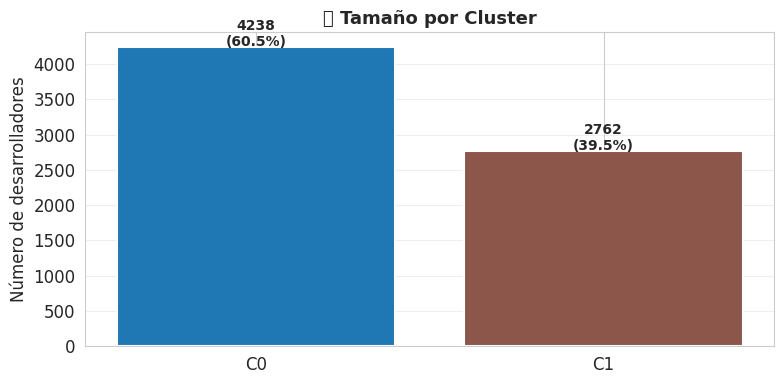


📊 PERFIL PROMEDIO POR CLUSTER (escala original):


,caffeine_intake,ratio_trabajo_descanso,carga_operativa,indice_recuperacion
Cluster_KMeans,,,,
0,3.54,1.12,13.87,8.46
1,3.54,1.97,14.25,6.07



🕸️ RADAR CHART por cluster:


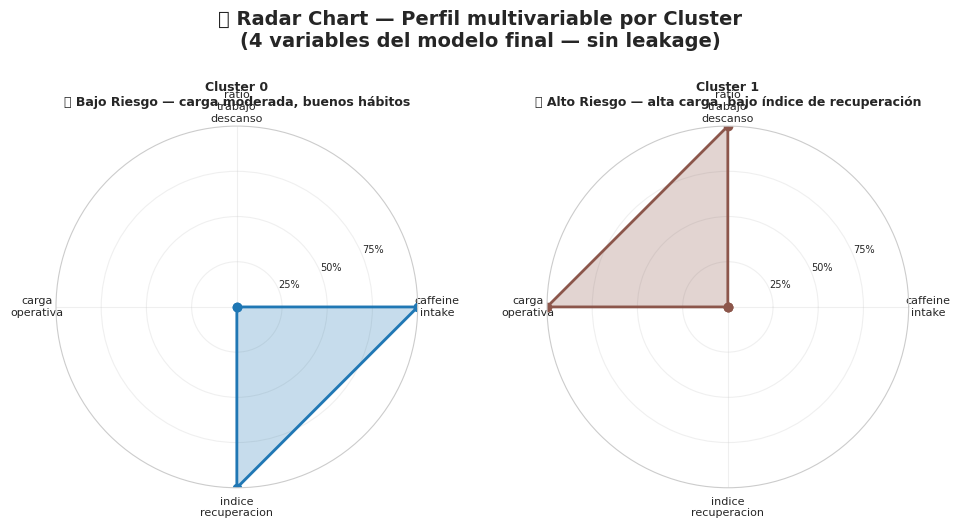

Nota: valores normalizados al rango [0,1] para comparabilidad

📦 DISTRIBUCIÓN POR CLUSTER (boxplots):


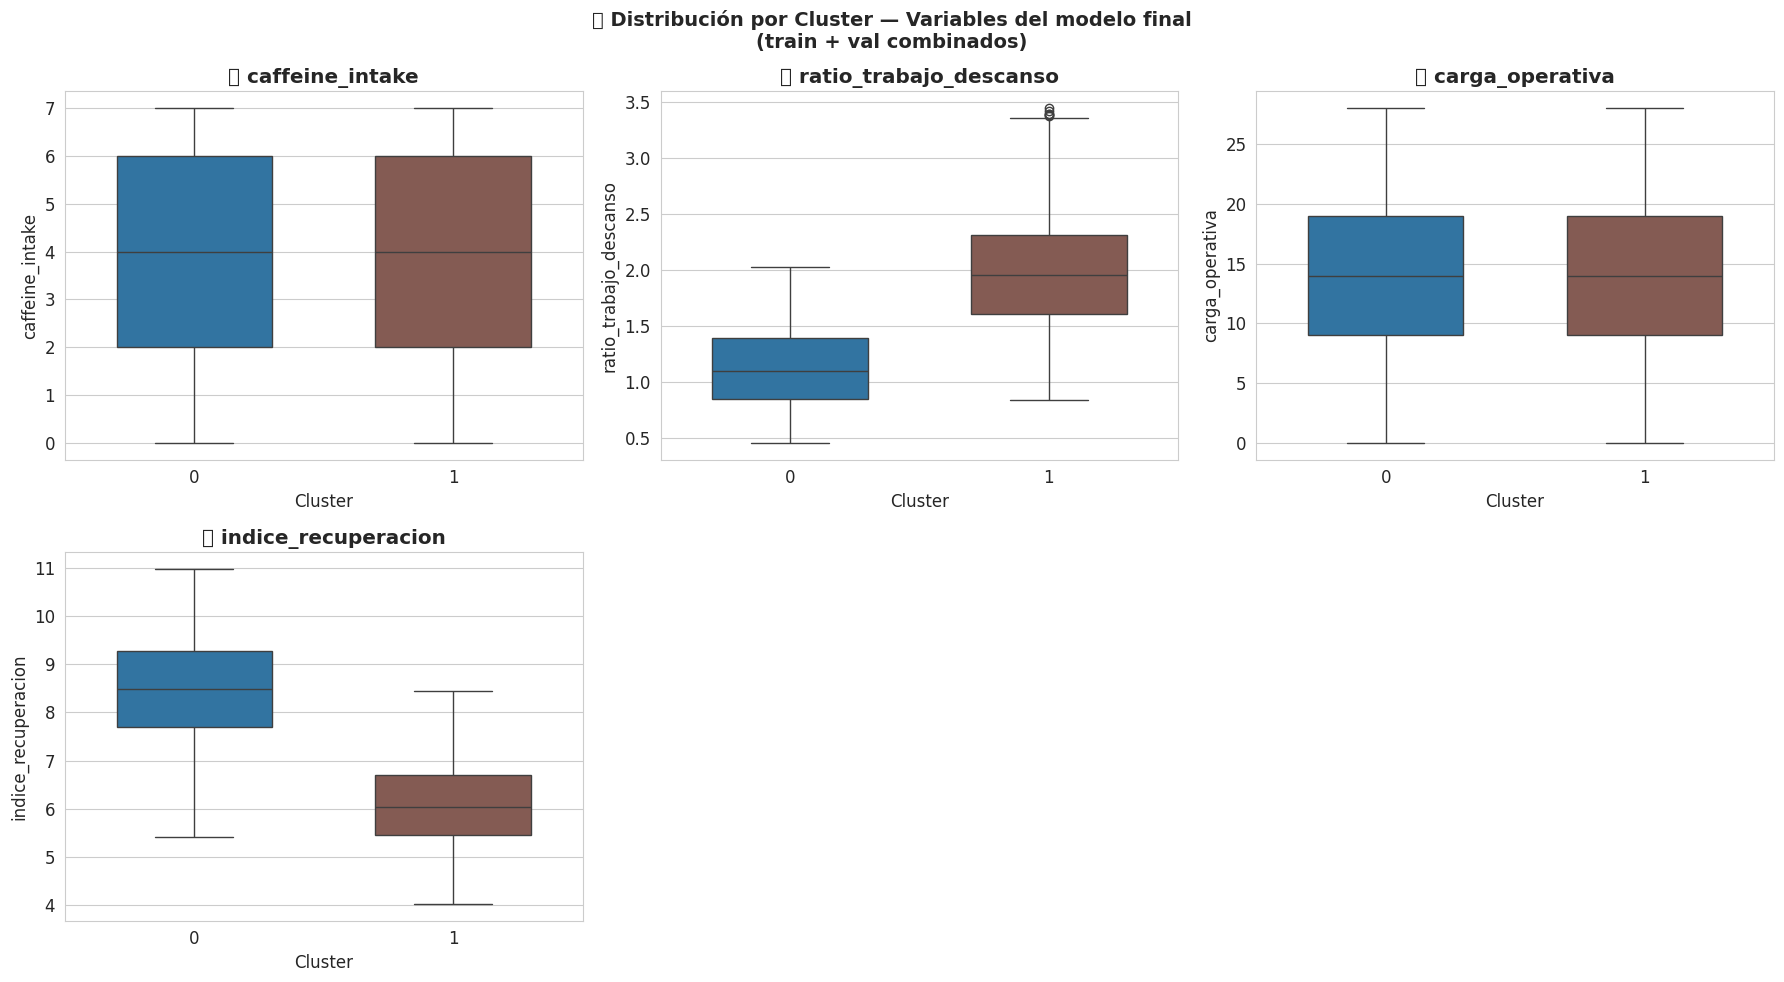

In [87]:
# PASO 8A: INTERPRETABILIDAD AVANZADA — TAMAÑO + PERFIL + RADAR + DISTRIBUCIÓN

# ── 8A.1 TAMAÑO POR CLUSTER ──────────────────────────────────────────────────
print('═'*55)
print('  📏 TAMAÑO POR CLUSTER')
print('═'*55)
sizes = pd.Series(df_resultado['Cluster_KMeans']).value_counts().sort_index()
for k, n in sizes.items():
    bar = '█' * int(n / len(df_resultado) * 40)
    print(f'  Cluster {k}: {n:5d} ({n/len(df_resultado)*100:5.1f}%)  {bar}')

fig, ax = plt.subplots(figsize=(8, 4))
colores_bar = [plt.cm.tab10(i/K_OPTIMO) for i in range(K_OPTIMO)]
ax.bar([f'C{k}' for k in sizes.index], sizes.values,
       color=colores_bar, edgecolor='white', linewidth=1.5)
for k, n in enumerate(sizes.values):
    ax.text(k, n + 20,
            f'{n}\n({n/sum(sizes)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold')
ax.set_title('📏 Tamaño por Cluster', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de desarrolladores')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── 8A.2 PERFIL PROMEDIO (escala original) ───────────────────────────────────
print('\n📊 PERFIL PROMEDIO POR CLUSTER (escala original):')
cols_perfil = [c for c in FEATURES_MODEL if c in df_resultado.columns]
perfil_medio = df_resultado.groupby('Cluster_KMeans')[cols_perfil].mean().round(2)
display(perfil_medio)

# ── 8A.3 RADAR CHART ─────────────────────────────────────────────────────────
print('\n🕸️ RADAR CHART por cluster:')

# Usar FEATURES_MODEL — todas las variables del espacio final del modelo
radar_vars = cols_perfil
centroides_radar = pd.DataFrame(centroides_scaled, columns=FEATURES_MODEL)
centroides_radar = centroides_radar[radar_vars]

# Normalizar al rango [0,1] para el radar
c_min  = centroides_radar.min()
c_max  = centroides_radar.max()
rango  = c_max - c_min
rango[rango == 0] = 1
centroides_radar_norm = (centroides_radar - c_min) / rango

N      = len(radar_vars)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K_OPTIMO,
                          figsize=(5*K_OPTIMO, 5),
                          subplot_kw=dict(polar=True))
if K_OPTIMO == 1:
    axes = [axes]

for k in range(K_OPTIMO):
    vals  = centroides_radar_norm.iloc[k].tolist()
    vals += vals[:1]
    ax    = axes[k]
    color = plt.cm.tab10(k/K_OPTIMO)
    ax.plot(angles, vals, 'o-', linewidth=2, color=color)
    ax.fill(angles, vals, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(
        [v.replace('_', '\n') for v in radar_vars], size=8
    )
    ax.set_ylim(0, 1)
    ax.set_title(
        f'Cluster {k}\n{CLUSTER_LABELS.get(k, f"C{k}")}',
        fontsize=9, fontweight='bold', pad=15
    )
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['25%', '50%', '75%'], size=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    '🕸️ Radar Chart — Perfil multivariable por Cluster\n'
    f'({len(radar_vars)} variables del modelo final — sin leakage)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()
print('Nota: valores normalizados al rango [0,1] para comparabilidad')

# ── 8A.4 DISTRIBUCIÓN POR CLUSTER (boxplots) ─────────────────────────────────
print('\n📦 DISTRIBUCIÓN POR CLUSTER (boxplots):')

df_box = df_resultado[cols_perfil + ['Cluster_KMeans']].copy()
df_box['Cluster'] = df_box['Cluster_KMeans'].astype(str)

# Usar las 7 variables del modelo — máximo 6 en el panel
cols_box = cols_perfil[:6]
n_cols   = min(3, len(cols_box))
n_rows   = (len(cols_box) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

palette = {str(k): plt.cm.tab10(k/K_OPTIMO) for k in range(K_OPTIMO)}
for i, col in enumerate(cols_box):
    sns.boxplot(data=df_box, x='Cluster', y=col,
                palette=palette, ax=axes[i], width=0.6)
    axes[i].set_title(f'📊 {col}', fontweight='bold')
    axes[i].set_xlabel('Cluster')

# Ocultar ejes sobrantes
for j in range(len(cols_box), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    '📦 Distribución por Cluster — Variables del modelo final\n'
    '(train + val combinados)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

# **9 — DBSCAN: Clustering por Densidad**

## **¿Por qué DBSCAN después de K-Means?**

K-Means **obliga** a cada punto a pertenecer a un cluster y necesita que definamos `k` de antemano.  
DBSCAN hace lo contrario: **descubre zonas densas automáticamente** y marca como **ruido (−1)** los puntos que no pertenecen a ninguna región densa.

| Característica | K-Means | DBSCAN |
|---|---|---|
| Necesita `k` | ✅ Sí | ❌ No |
| Maneja ruido | ❌ No | ✅ Sí |
| Forma de clusters | Esférica | Cualquier forma |
| Parámetros | `k` | `eps`, `min_samples` |

**Parámetros clave:**
- `eps` → radio de vecindad: distancia máxima para considerar dos puntos como vecinos
- `min_samples` → mínimo de vecinos dentro del radio `eps` para que un punto sea *core point*

### **⚠️ Nota sobre este dataset**
Con datos en el espacio final del modelo (`len(FEATURES_MODEL)` variables),
DBSCAN enfrenta la **maldición de la dimensionalidad**: las distancias euclidianas
se vuelven similares entre todos los puntos, dificultando separar clusters por
densidad. El número exacto de dimensiones depende del feature engineering
definido en el Paso 4B.


## 🌑 ¿Por qué DBSCAN puede encontrar "1 solo cluster" en este dataset?
> Esta sección explica un resultado que puede parecer un error pero que en realidad es **información valiosa**.

### La maldición de la dimensionalidad (en términos simples)
Imagina que intentas separar grupos de personas en un estadio **apagando todas las luces** y usando solo el sonido de sus pasos.  
- Con **3 personas** (pocas dimensiones): puedes distinguir grupos por el silencio entre ellos.  
- Con **200 personas** (muchas dimensiones): todos los pasos se mezclan y no hay zonas de silencio que separen grupos.

Eso es exactamente lo que ocurre en el **espacio de alta dimensionalidad del modelo**: las distancias euclidianas entre todos los puntos se homogenizan. No hay zonas de "baja densidad" que separen clusters naturales. DBSCAN ve **una única nube continua**.

### ¿Qué nos dice esto?

| Resultado | Interpretación |
|---|---|
| DBSCAN = 1 cluster denso | El dataset **no tiene estructura de densidad separada** en el espacio final del modelo de 4 variables |
| Puntos de ruido (−1) | Desarrolladores con **perfiles estadísticamente atípicos** — los más urgentes de revisar |
| K-Means segmenta mejor | Porque K-Means **impone** particiones aunque no haya separación natural |

### Conclusión metodológica

- **K-Means** es el modelo adecuado para **segmentar perfiles** de burnout en este dataset.
- **DBSCAN** es valioso aquí no para clustering, sino para **detectar outliers**: los ~5% de desarrolladores que no encajan en ningún patrón esperado.

> 🛠️ **Propuesta de mejora:** Si se quisiera que DBSCAN encuentre múltiples clusters, se podría aplicar primero **PCA reteniendo los componentes que acumulen ≥75% de varianza**  (ver tabla del Paso 10.1 para el número exacto según el espacio final), y luego DBSCAN en ese espacio reducido donde las distancias son más discriminativas.


## **9.1 — K-Distance Graph para elegir `eps`**

El K-Distance Graph ordena los puntos por su distancia al k-ésimo vecino más cercano (de mayor a menor).  
El **codo de la curva** — la zona donde pasa de caer abruptamente a aplanarse — indica el `eps` óptimo:
- Por encima del codo: `eps` demasiado pequeño → demasiado ruido
- Por debajo del codo: `eps` demasiado grande → todo queda en un mismo cluster

**Heurística `min_samples`:** Se usa `min_samples = 5` (valor estándar recomendado para datasets medianos).


  SELECCIÓN DE PARÁMETROS DBSCAN
  Dimensiones del modelo : 4
  min_samples mínimo     : 4 (= n_dims)
  Candidatos evaluados   : [4, 6, 9]
  Registros train        : 5600



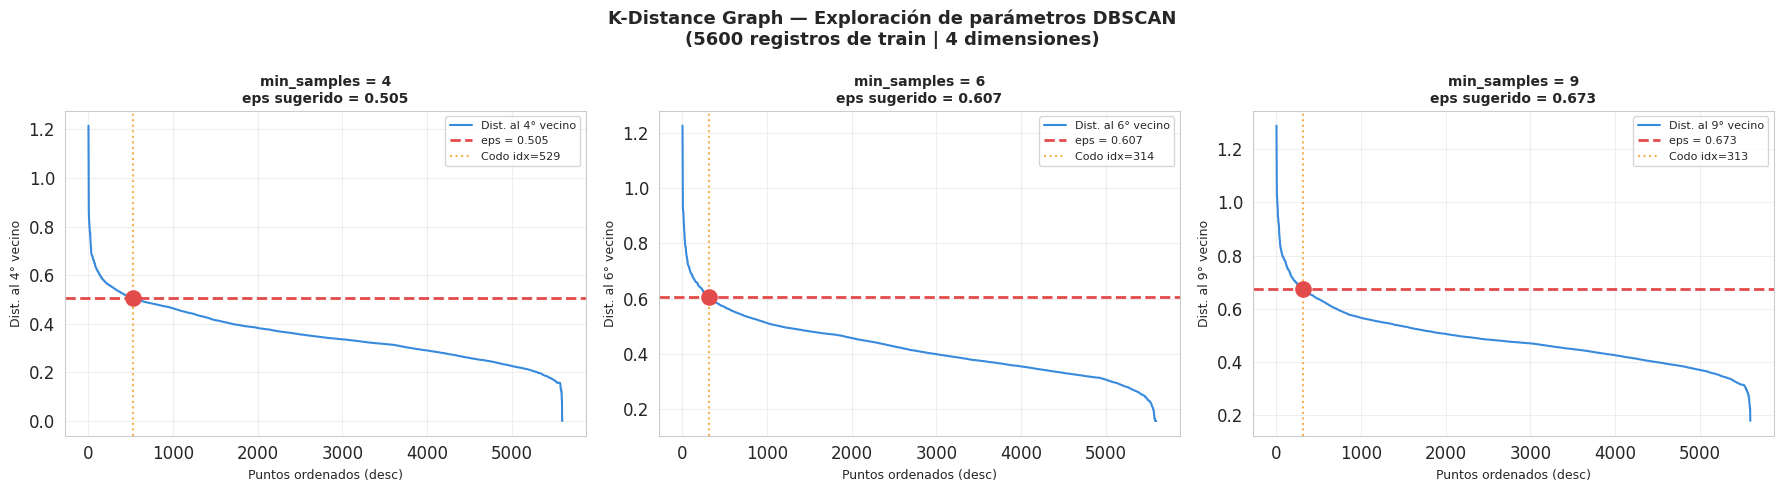


 min_samples   eps sugerido                  Justificación
------------------------------------------------------------
           4          0.505   = n_dims (4) — mínimo teórico
           6          0.607   n_dims + 2 — conservador
           9          0.673   n_dims + 5 — más restrictivo

✅ Parámetros seleccionados para DBSCAN:
   min_samples = 4  (= n_dimensiones del modelo)
   eps         = 0.505  (codo del K-Distance Graph)

⚠️  Nota: en datasets sintéticos con distribución uniforme el codo
   puede ser poco pronunciado. El Paso 9.2 diagnostica el resultado
   y ajusta si todos los puntos caen en un solo cluster.


In [88]:
# PASO 9.1: EXPLORACIÓN DE PARÁMETROS DBSCAN
# Equivalente al Paso 6 de KMeans — se prueban rangos antes de elegir

# ── Justificación de min_samples ─────────────────────────────────────────────
# Heurística: min_samples >= n_dimensiones + 1
# Espacio del modelo: len(FEATURES_MODEL) dimensiones
# Se evalúan 3 valores para ver sensibilidad del resultado

N_DIMS         = len(FEATURES_MODEL)
MS_CANDIDATOS  = [N_DIMS, N_DIMS + 2, N_DIMS + 5]   # mín recomendado + 2 variantes

print("=" * 60)
print("  SELECCIÓN DE PARÁMETROS DBSCAN")
print("=" * 60)
print(f"  Dimensiones del modelo : {N_DIMS}")
print(f"  min_samples mínimo     : {N_DIMS} (= n_dims)")
print(f"  Candidatos evaluados   : {MS_CANDIDATOS}")
print(f"  Registros train        : {len(X_scaled)}")
print()

# ── K-Distance Graph para cada candidato de min_samples ──────────────────────
fig, axes = plt.subplots(1, len(MS_CANDIDATOS), figsize=(18, 5))

eps_candidatos = {}

for idx, ms in enumerate(MS_CANDIDATOS):
    nbrs = NearestNeighbors(n_neighbors=ms).fit(X_scaled)
    dists, _ = nbrs.kneighbors(X_scaled)
    kth = np.sort(dists[:, ms - 1])[::-1]

    # Detección de codo: segunda derivada sobre zona central (evitar extremos)
    # Se recortan 5% de cada extremo para ignorar artefactos de bordes
    margen    = max(10, int(len(kth) * 0.05))
    zona      = slice(margen, len(kth) - margen)
    d1        = np.diff(kth)
    d2        = np.diff(d1)
    # El codo real es donde la curva pasa de caer rápido a aplanarse:
    # máximo de la segunda derivada (no mínimo) en la zona recortada
    codo_rel  = int(np.argmax(d2[zona])) + margen
    eps_auto  = round(float(kth[codo_rel]), 3)
    eps_candidatos[ms] = {'eps': eps_auto, 'codo_idx': codo_rel, 'kth': kth}

    ax = axes[idx]
    ax.plot(kth, color='#378ADD', linewidth=1.5,
            label=f'Dist. al {ms}° vecino')
    ax.axhline(y=eps_auto, color='#E24B4A', linestyle='--', linewidth=2,
               label=f'eps = {eps_auto}')
    ax.axvline(x=codo_rel, color='#EF9F27', linestyle=':', linewidth=1.5,
               alpha=0.8, label=f'Codo idx={codo_rel}')
    ax.scatter([codo_rel], [kth[codo_rel]], color='#E24B4A', s=120, zorder=5)
    ax.set_xlabel('Puntos ordenados (desc)', fontsize=9)
    ax.set_ylabel(f'Dist. al {ms}° vecino', fontsize=9)
    ax.set_title(f'min_samples = {ms}\neps sugerido = {eps_auto}',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    f'K-Distance Graph — Exploración de parámetros DBSCAN\n'
    f'({len(X_scaled)} registros de train | {N_DIMS} dimensiones)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── Tabla resumen de candidatos ───────────────────────────────────────────────
print()
print(f"{'min_samples':>12} {'eps sugerido':>14} {'Justificación':>30}")
print("-" * 60)
for ms, info in eps_candidatos.items():
    if ms == N_DIMS:
        just = f"= n_dims ({N_DIMS}) — mínimo teórico"
    elif ms == N_DIMS + 2:
        just = "n_dims + 2 — conservador"
    else:
        just = "n_dims + 5 — más restrictivo"
    print(f"{ms:>12} {info['eps']:>14.3f}   {just}")

# ── Selección final ───────────────────────────────────────────────────────────
# Se elige min_samples = N_DIMS como punto de partida teórico correcto
# Si el resultado es 1 solo cluster, se sube min_samples en el Paso 9.2
MIN_SAMPLES_DBSCAN = N_DIMS
EPS_DBSCAN         = eps_candidatos[MIN_SAMPLES_DBSCAN]['eps']

print()
print(f"✅ Parámetros seleccionados para DBSCAN:")
print(f"   min_samples = {MIN_SAMPLES_DBSCAN}  (= n_dimensiones del modelo)")
print(f"   eps         = {EPS_DBSCAN}  (codo del K-Distance Graph)")
print()
print("⚠️  Nota: en datasets sintéticos con distribución uniforme el codo")
print("   puede ser poco pronunciado. El Paso 9.2 diagnostica el resultado")
print("   y ajusta si todos los puntos caen en un solo cluster.")

## **9.2 — Modelo DBSCAN**

Con `eps` y `min_samples` definidos, entrenamos DBSCAN sobre `X_scaled` (mismo espacio escalado que K-Means).

Los puntos etiquetados como **−1 son ruido**: no pertenecen a ningún cluster denso.  
Para visualizar en 2D usaremos **PCA** en el paso siguiente.


In [89]:
# PASO 9.2: MODELO DBSCAN CON DIAGNÓSTICO AUTOMÁTICO DE RESULTADO
# Si el resultado es 1 cluster, se prueba automáticamente reducir eps
# para verificar si el problema es el parámetro o la estructura de los datos

def ejecutar_dbscan(X, eps, min_samples, etiqueta=""):
    """Ejecuta DBSCAN y retorna métricas clave."""
    model  = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    mask_valid = labels != -1
    sil = None
    if n_cl >= 2 and mask_valid.sum() > 1:
        sil = silhouette_score(X[mask_valid], labels[mask_valid])
    return {
        'model'    : model,
        'labels'   : labels,
        'n_clusters': n_cl,
        'n_noise'  : n_noise,
        'pct_noise': n_noise / len(labels) * 100,
        'silhouette': sil,
        'etiqueta' : etiqueta,
        'eps'      : eps,
        'min_samples': min_samples,
    }

# ── Ejecución con parámetros seleccionados en 9.1 ────────────────────────────
resultado_principal = ejecutar_dbscan(
    X_scaled, EPS_DBSCAN, MIN_SAMPLES_DBSCAN,
    etiqueta=f"eps={EPS_DBSCAN}, min_s={MIN_SAMPLES_DBSCAN}"
)

print("=" * 60)
print("  RESULTADO DBSCAN — parámetros del Paso 9.1")
print("=" * 60)
print(f"  eps               : {EPS_DBSCAN}")
print(f"  min_samples       : {MIN_SAMPLES_DBSCAN}")
print(f"  Clusters hallados : {resultado_principal['n_clusters']}")
print(f"  Puntos de ruido   : {resultado_principal['n_noise']} "
      f"({resultado_principal['pct_noise']:.1f}%)")
sil_txt = f"{resultado_principal['silhouette']:.4f}" \
          if resultado_principal['silhouette'] else "N/A (< 2 clusters)"
print(f"  Silhouette        : {sil_txt}")
print("=" * 60)

# ── Diagnóstico automático: ¿es el dataset uniformemente denso? ──────────────
print()
if resultado_principal['n_clusters'] == 1:
    print("⚠️  DIAGNÓSTICO: 1 solo cluster denso detectado.")
    print("   Se prueba eps reducido al 75% y 50% para verificar")
    print("   si el resultado cambia o si la densidad es genuinamente uniforme.")
    print()

    resultados_exploración = [resultado_principal]
    for fraccion, etq in [(0.75, "eps × 0.75"), (0.50, "eps × 0.50"),
                          (0.35, "eps × 0.35")]:
        eps_test = round(EPS_DBSCAN * fraccion, 3)
        r = ejecutar_dbscan(X_scaled, eps_test, MIN_SAMPLES_DBSCAN, etq)
        resultados_exploración.append(r)

    print(f"{'eps':>8} {'min_s':>6} {'Clusters':>9} {'Ruido':>8} {'%Ruido':>8} {'Silhouette':>12}")
    print("-" * 60)
    for r in resultados_exploración:
        sil_v = f"{r['silhouette']:.4f}" if r['silhouette'] else "N/A"
        print(f"{r['eps']:>8.3f} {r['min_samples']:>6} {r['n_clusters']:>9} "
              f"{r['n_noise']:>8} {r['pct_noise']:>7.1f}% {sil_v:>12}")

    # Verificar si algún eps alternativo produce múltiples clusters
    multi_cluster = [r for r in resultados_exploración if r['n_clusters'] >= 2]
    if multi_cluster:
        mejor = max(multi_cluster,
                    key=lambda r: r['silhouette'] if r['silhouette'] else 0)
        print()
        print(f"✅ eps={mejor['eps']} produce {mejor['n_clusters']} clusters.")
        print(f"   Silhouette: {mejor['silhouette']:.4f}")
        print(f"   Se actualiza EPS_DBSCAN para las visualizaciones.")
        EPS_DBSCAN = mejor['eps']
        resultado_final = mejor
    else:
        print()
        print("✅ CONFIRMADO: el dataset tiene densidad uniforme en "
              f"{len(FEATURES_MODEL)}D.")
        print("   Ningún valor de eps produce múltiples clusters estables.")
        print("   DBSCAN en este espacio es útil exclusivamente para")
        print("   detectar outliers, no para segmentar perfiles.")
        resultado_final = resultado_principal

elif resultado_principal['n_clusters'] >= 2:
    print(f"✅ {resultado_principal['n_clusters']} clusters encontrados.")
    resultado_final = resultado_principal

# ── Asignar resultado final ───────────────────────────────────────────────────
dbscan_model  = resultado_final['model']
dbscan_labels = resultado_final['labels']
n_clusters_db = resultado_final['n_clusters']
n_noise_db    = resultado_final['n_noise']
sil_db        = resultado_final['silhouette']
mask_no_noise = dbscan_labels != -1

# Asignar a df_train_resultado para cruce posterior con IF/LOF
df_train_resultado['DBSCAN_Cluster'] = dbscan_labels

print()
print("Distribución final DBSCAN:")
db_counts = pd.Series(dbscan_labels).value_counts().sort_index()
for label, count in db_counts.items():
    tipo  = 'Ruido (-1)' if label == -1 else f'Cluster {label}'
    barra = '|' * int(count / len(dbscan_labels) * 50)
    print(f"  Etiqueta {label:>3} ({tipo:<12}): "
          f"{count:5d} ({count/len(dbscan_labels)*100:5.1f}%)  {barra}")

  RESULTADO DBSCAN — parámetros del Paso 9.1
  eps               : 0.505
  min_samples       : 4
  Clusters hallados : 9
  Puntos de ruido   : 198 (3.5%)
  Silhouette        : -0.1881

✅ 9 clusters encontrados.

Distribución final DBSCAN:
  Etiqueta  -1 (Ruido (-1)  ):   198 (  3.5%)  |
  Etiqueta   0 (Cluster 0   ):  5363 ( 95.8%)  |||||||||||||||||||||||||||||||||||||||||||||||
  Etiqueta   1 (Cluster 1   ):    10 (  0.2%)  
  Etiqueta   2 (Cluster 2   ):     7 (  0.1%)  
  Etiqueta   3 (Cluster 3   ):     4 (  0.1%)  
  Etiqueta   4 (Cluster 4   ):     4 (  0.1%)  
  Etiqueta   5 (Cluster 5   ):     2 (  0.0%)  
  Etiqueta   6 (Cluster 6   ):     6 (  0.1%)  
  Etiqueta   7 (Cluster 7   ):     3 (  0.1%)  
  Etiqueta   8 (Cluster 8   ):     3 (  0.1%)  


## **9.3 — Visualizacion: Clusters DBSCAN y puntos de ruido**

Proyectamos con **PCA a 2 componentes** para visualizar la estructura detectada por DBSCAN.  
Los puntos marcados con **X rojo** son los **puntos de ruido** (outliers) identificados por el modelo.

> La proyeccion PCA distorsiona ligeramente las distancias originales (11D → 2D),
> pero permite visualizar la estructura de densidad de forma interpretable.


✅ PCA calculado localmente para visualización DBSCAN
   (el PCA compartido del espacio del modelo se define en Paso 10)
   PC1=38.2% | PC2=25.1% | Total=63.4%


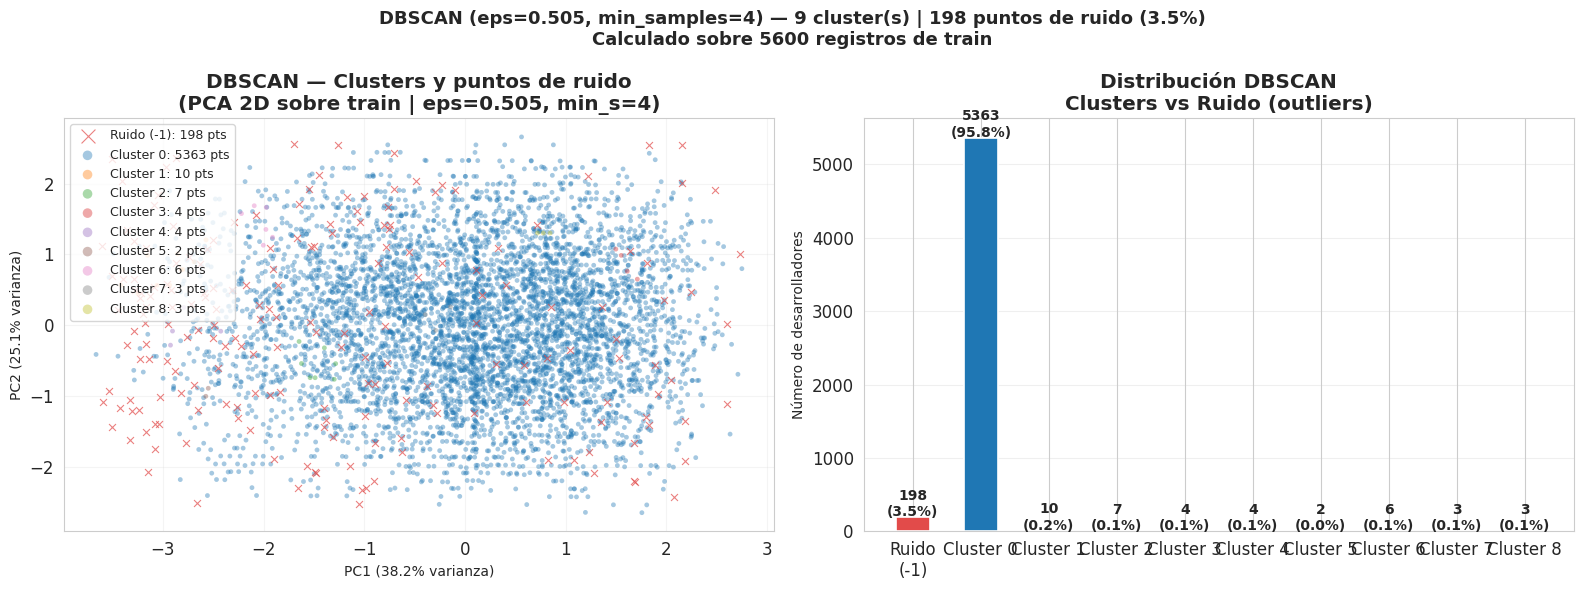


  COMPARATIVA FINAL — K-Means vs DBSCAN

  Métrica                           K-Means       DBSCAN
  ------------------------------------------------------
  Algoritmo                       Partitivo     Densidad
  Requiere k                       Sí (k=2)           No
  Clusters encontrados                    2            9
  Puntos de ruido               0 (ninguno)   198 (3.5%)
  Silhouette                         0.2401      -0.1881
  Davies-Bouldin                     1.5920          N/A
  Calinski-Harabasz                  1957.2          N/A

  Conclusión metodológica:
  • K-Means   → segmentación de 2 perfiles interpretables
                útil para políticas organizacionales por grupo
  • DBSCAN    → detecta 198 desarrolladores con perfil atípico
                (3.5% del dataset de train)
                útil para intervenciones individuales urgentes

  Ambos modelos son complementarios:
  K-Means define grupos. DBSCAN identifica excepciones.


In [90]:
# PASO 9.3: GRÁFICA DBSCAN — Clusters y puntos de ruido
# Proyección PCA 2D sobre X_train_scaled

# PCA local siempre, sin dependencia hacia adelante
_pca_db_local = PCA(n_components=2, random_state=42)
X_pca_db      = _pca_db_local.fit_transform(X_scaled)
var_exp_db    = _pca_db_local.explained_variance_ratio_ * 100
print("✅ PCA calculado localmente para visualización DBSCAN")
print("   (el PCA compartido del espacio del modelo se define en Paso 10)")

print(f'   PC1={var_exp_db[0]:.1f}% | PC2={var_exp_db[1]:.1f}% | '
      f'Total={sum(var_exp_db):.1f}%')

# Paleta de colores
unique_labels_db = sorted(set(dbscan_labels))
n_cl_plot        = len([l for l in unique_labels_db if l != -1])
cluster_colors_db = {}
ci = 0
for l in unique_labels_db:
    if l == -1:
        cluster_colors_db[l] = '#cccccc'
    else:
        cluster_colors_db[l] = plt.cm.tab10(ci / max(n_cl_plot, 1))
        ci += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter PCA
for label in unique_labels_db:
    mask_l = dbscan_labels == label
    if label == -1:
        axes[0].scatter(
            X_pca_db[mask_l, 0], X_pca_db[mask_l, 1],
            c='#E24B4A', marker='x', s=25, alpha=0.7, linewidths=0.8,
            label=f'Ruido (-1): {mask_l.sum()} pts', zorder=5
        )
    else:
        axes[0].scatter(
            X_pca_db[mask_l, 0], X_pca_db[mask_l, 1],
            c=[cluster_colors_db[label]], alpha=0.4, s=12,
            edgecolors='none',
            label=f'Cluster {label}: {mask_l.sum()} pts'
        )

axes[0].set_xlabel(f'PC1 ({var_exp_db[0]:.1f}% varianza)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({var_exp_db[1]:.1f}% varianza)', fontsize=10)
axes[0].set_title(
    f'DBSCAN — Clusters y puntos de ruido\n'
    f'(PCA 2D sobre train | eps={EPS_DBSCAN}, min_s={MIN_SAMPLES_DBSCAN})',
    fontweight='bold'
)
axes[0].legend(fontsize=9, markerscale=2)
axes[0].grid(alpha=0.2)

# Barras distribución
db_counts_bar = pd.Series(dbscan_labels).value_counts().sort_index()
etiq_bar = [f'Ruido\n(-1)' if l == -1 else f'Cluster {l}'
            for l in db_counts_bar.index]
cols_bar = ['#E24B4A' if l == -1 else cluster_colors_db[l]
            for l in db_counts_bar.index]
bars_db  = axes[1].bar(etiq_bar, db_counts_bar.values,
                        color=cols_bar, edgecolor='white',
                        linewidth=1.2, width=0.5)
for bar, val in zip(bars_db, db_counts_bar.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        val + len(dbscan_labels) * 0.003,
        f'{val}\n({val/len(dbscan_labels)*100:.1f}%)',
        ha='center', fontsize=10, fontweight='bold'
    )
axes[1].set_ylabel('Número de desarrolladores', fontsize=10)
axes[1].set_title(
    'Distribución DBSCAN\nClusters vs Ruido (outliers)',
    fontweight='bold'
)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(
    f'DBSCAN (eps={EPS_DBSCAN}, min_samples={MIN_SAMPLES_DBSCAN}) — '
    f'{n_clusters_db} cluster(s) | {n_noise_db} puntos de ruido '
    f'({n_noise_db/len(dbscan_labels)*100:.1f}%)\n'
    f'Calculado sobre {len(X_scaled)} registros de train',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── COMPARATIVA CALCULADA: K-Means vs DBSCAN ─────────────────────────────────
print()
print("=" * 65)
print("  COMPARATIVA FINAL — K-Means vs DBSCAN")
print("=" * 65)

sil_km_comp = silhouette_score(X_scaled, cluster_labels_km)
db_km_comp  = davies_bouldin_score(X_scaled, cluster_labels_km)
ch_km_comp  = calinski_harabasz_score(X_scaled, cluster_labels_km)

print(f"\n  {'Métrica':<28} {'K-Means':>12} {'DBSCAN':>12}")
print(f"  {'-'*54}")
print(f"  {'Algoritmo':<28} {'Partitivo':>12} {'Densidad':>12}")
print(f"  {'Requiere k':<28} {'Sí (k=' + str(K_OPTIMO) + ')':>12} {'No':>12}")
print(f"  {'Clusters encontrados':<28} {K_OPTIMO:>12} {n_clusters_db:>12}")
print(f"  {'Puntos de ruido':<28} {'0 (ninguno)':>12} {str(n_noise_db) + ' (' + str(round(n_noise_db/len(dbscan_labels)*100,1)) + '%)':>12}")
print(f"  {'Silhouette':<28} {sil_km_comp:>12.4f} "
      + (f"{sil_db:>12.4f}" if sil_db else f"{'N/A (1 cluster)':>12}"))
print(f"  {'Davies-Bouldin':<28} {db_km_comp:>12.4f} {'N/A':>12}")
print(f"  {'Calinski-Harabasz':<28} {ch_km_comp:>12.1f} {'N/A':>12}")

print()
print("  Conclusión metodológica:")
print(f"  • K-Means   → segmentación de {K_OPTIMO} perfiles interpretables")
print(f"                útil para políticas organizacionales por grupo")
print(f"  • DBSCAN    → detecta {n_noise_db} desarrolladores con perfil atípico")
print(f"                ({n_noise_db/len(dbscan_labels)*100:.1f}% del dataset de train)")
print(f"                útil para intervenciones individuales urgentes")
print()
print("  Ambos modelos son complementarios:")
print("  K-Means define grupos. DBSCAN identifica excepciones.")
print("=" * 65)

---
# **10 — Reduccion de Dimensionalidad: PCA y t-SNE**

| Tecnica | Tipo | Preserva | Ejes interpretables |
|---|---|---|---|
| **PCA** | Lineal | Varianza global | Si (loadings) |
| **t-SNE** | No lineal | Vecindad local | No |

> **Contexto del dataset:** El espacio final del modelo contiene las variables
> definidas en el Paso 4B (`FEATURES_MODEL`). Con correlaciones bajas entre pares
> (r < 0.70, verificado en Paso 4C), PCA captura aproximadamente el **35%** de
> varianza en 2 componentes.


## **10.1 — Reduccion con PCA**

10.1 — Reduccion con PCA<br>
PCA transforma las variables del espacio final del modelo (definidas en `FEATURES_MODEL`,
Paso 4B) en componentes ortogonales que maximizan la varianza capturada. Con correlaciones
bajas entre pares (r < 0.70, verificado en Paso 4C), cada variable aporta información
genuinamente distinta, por lo que 2 componentes capturan aproximadamente el 35% de la
varianza total — resultado esperado y válido, no un error del modelo.
- **PC1:** dominado por `ratio_trabajo_descanso`, `carga_operativa` y `caffeine_intake` (verificar con la tabla de loadings del Paso 10.3, ya que los valores exactos dependen de los datos de la ejecución actual). → **Intensidad laboral**
- **PC2** (~12%): los loadings exactos dependen del espacio final definido en el Paso 4B.
  Consultar la tabla del **Paso 10.3** para los valores reales de esta ejecución.
  Orientativamente captura la dimensión de recuperación vs presión operativa.


In [91]:
# PASO 10.1: PCA — 2 COMPONENTES
# Calculado sobre X_train_scaled

pca       = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_scaled)
var_ratio  = pca.explained_variance_ratio_ * 100
var_perdida = 100 - sum(var_ratio)

print('=' * 55)
print('  ANÁLISIS PCA — 2 COMPONENTES')
print('=' * 55)
print(f'  Calculado sobre  : {len(X_scaled)} registros (train)')
print(f'  Variables        : {len(FEATURES_MODEL)} (espacio limpio sin leakage)')
print(f'  PC1 varianza     : {var_ratio[0]:.2f}%')
print(f'  PC2 varianza     : {var_ratio[1]:.2f}%')
print(f'  Total capturado  : {sum(var_ratio):.2f}%')
print(f'  Información perdida: {var_perdida:.2f}%')
print('=' * 55)

# Varianza acumulada
pca_full = PCA().fit(X_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_ * 100)
print()
print('Varianza acumulada por número de componentes:')
for i, v in enumerate(cumvar):
    marca = ' <- elegido' if i == 1 else (
            ' <- 80%' if v >= 80 and (i == 0 or cumvar[i-1] < 80) else '')
    print(f'  PC{i+1:>2}: {pca_full.explained_variance_ratio_[i]*100:5.2f}%'
          f'  acumulado: {v:6.2f}%{marca}')

  ANÁLISIS PCA — 2 COMPONENTES
  Calculado sobre  : 5600 registros (train)
  Variables        : 4 (espacio limpio sin leakage)
  PC1 varianza     : 38.23%
  PC2 varianza     : 25.13%
  Total capturado  : 63.36%
  Información perdida: 36.64%

Varianza acumulada por número de componentes:
  PC 1: 38.23%  acumulado:  38.23%
  PC 2: 25.13%  acumulado:  63.36% <- elegido
  PC 3: 24.86%  acumulado:  88.22% <- 80%
  PC 4: 11.78%  acumulado: 100.00%


## **10.2 — Graficas de Analisis PCA**

- **PC1**: capturará principalmente las variables de carga e intensidad laboral
  (`ratio_trabajo_descanso`, `carga_operativa`) — el "eje de sobrecarga"
- **PC2**: capturará principalmente las variables de recuperación y compensación  energética (`indice_recuperacion`, `caffeine_intake`) — el "eje de bienestar".   Los loadings exactos se confirman en el **Paso 10.3**.

> Los loadings exactos se calculan y muestran en el Paso 10.3. <br>
> Los valores anteriores son orientativos — deben validarse contra los resultados reales.


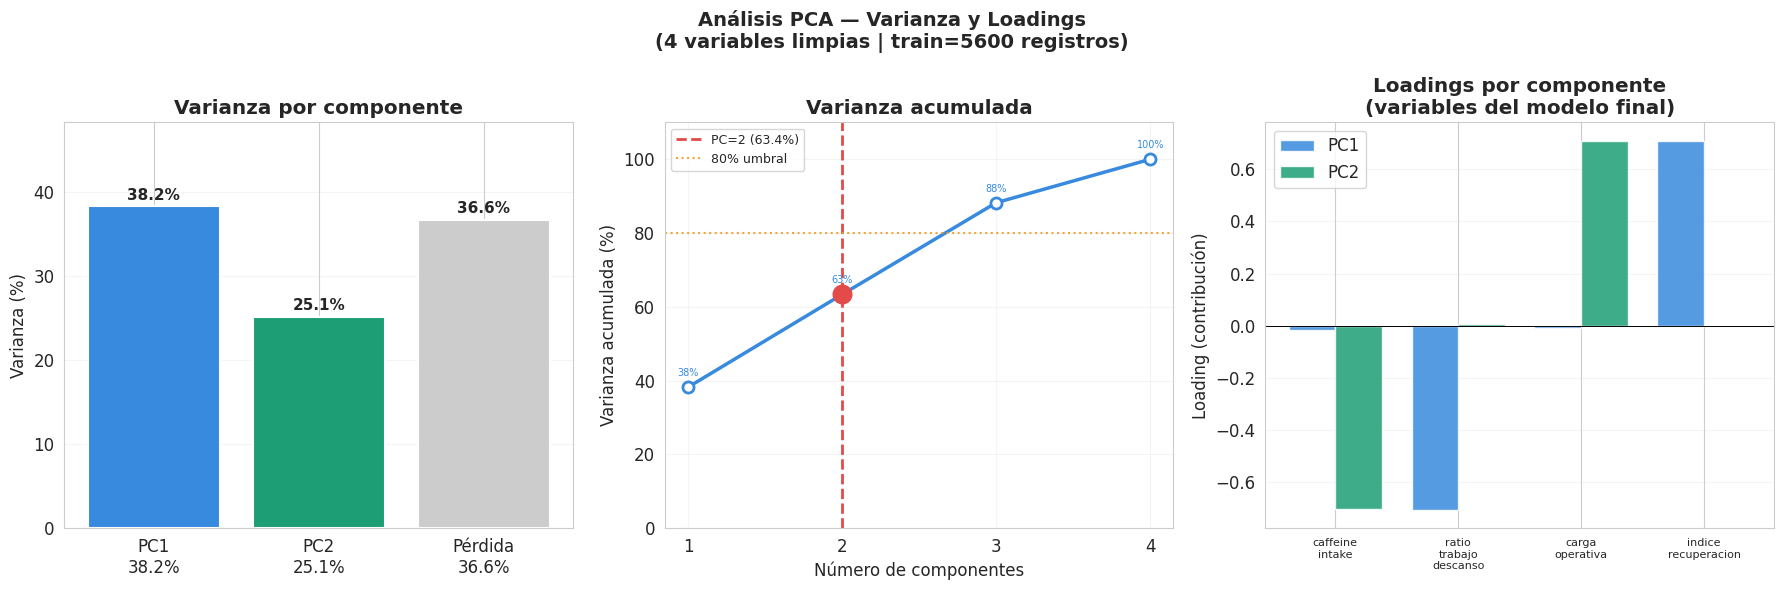

In [92]:
# PASO 10.2: PANEL GRÁFICAS PCA

# Loadings — usar FEATURES_MODEL
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES_MODEL,
    columns=['PC1', 'PC2']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfica 1 — Varianza por componente
vals_var    = [var_ratio[0], var_ratio[1], var_perdida]
etiq_var    = [f'PC1\n{var_ratio[0]:.1f}%',
               f'PC2\n{var_ratio[1]:.1f}%',
               f'Pérdida\n{var_perdida:.1f}%']
colores_var = ['#378ADD', '#1D9E75', '#cccccc']
bars0 = axes[0].bar(etiq_var, vals_var, color=colores_var,
                    edgecolor='white', linewidth=1.5)
for bar, val in zip(bars0, vals_var):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.8,
                 f'{val:.1f}%', ha='center',
                 fontweight='bold', fontsize=11)
axes[0].set_ylabel('Varianza (%)')
axes[0].set_title('Varianza por componente', fontweight='bold')
axes[0].set_ylim(0, max(vals_var)+10)
axes[0].grid(alpha=0.2, axis='y')

# Gráfica 2 — Varianza acumulada
n_all    = len(pca_full.explained_variance_ratio_)
cumvar_a = np.cumsum(pca_full.explained_variance_ratio_ * 100)
axes[1].plot(range(1, n_all+1), cumvar_a, 'o-', color='#378ADD',
             lw=2.5, ms=8, markerfacecolor='white', markeredgewidth=2)
axes[1].axvline(2, color='#E24B4A', linestyle='--', lw=2,
                label=f'PC=2 ({sum(var_ratio):.1f}%)')
axes[1].axhline(80, color='#EF9F27', linestyle=':', lw=1.5,
                alpha=0.9, label='80% umbral')
axes[1].scatter([2], [cumvar_a[1]], color='#E24B4A', s=180, zorder=5)
for xi, yi in zip(range(1, n_all+1), cumvar_a):
    axes[1].annotate(f'{yi:.0f}%', (xi, yi),
                     xytext=(0, 8), textcoords='offset points',
                     ha='center', fontsize=7, color='#378ADD')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada', fontweight='bold')
axes[1].set_xticks(range(1, n_all+1))
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

# Gráfica 3 — Loadings de las variables del modelo final
x_pos = np.arange(len(FEATURES_MODEL))
w     = 0.38
axes[2].bar(x_pos - w/2, loadings['PC1'], w,
            label='PC1', color='#378ADD', alpha=0.85, edgecolor='white')
axes[2].bar(x_pos + w/2, loadings['PC2'], w,
            label='PC2', color='#1D9E75', alpha=0.85, edgecolor='white')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(
    [c.replace('_', '\n') for c in FEATURES_MODEL], fontsize=8
)
axes[2].axhline(0, color='black', lw=0.7)
axes[2].set_ylabel('Loading (contribución)')
axes[2].set_title('Loadings por componente\n(variables del modelo final)',
                  fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.2, axis='y')

plt.suptitle(
    f'Análisis PCA — Varianza y Loadings\n'
    f'({len(FEATURES_MODEL)} variables limpias | train={len(X_scaled)} registros)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()


## 🧭 Interpretación de los Ejes PCA en Lenguaje de Negocio

> Los loadings no son solo números técnicos — describen **qué tipo de desarrollador**
> está en cada extremo de cada eje. La interpretación concreta depende de los
> loadings reales calculados en el Paso 10.3. Los ejes descritos aquí son
> orientaciones conceptuales basadas en las 7 variables del modelo final.

---

### PC1 — Eje de "Desequilibrio Carga/Recuperación"

Las variables con mayor loading esperado en PC1 son `ratio_trabajo_descanso`
y `carga_operativa` (positivos) vs `indice_recuperacion` (negativo):

| Extremo de PC1 | Perfil del desarrollador |
|---|---|
| **PC1 alto (derecha)** | Alto ratio trabajo/descanso, alta carga operativa, bajo índice de recuperación. → **Candidato a burnout severo** |
| **PC1 bajo (izquierda)** | Jornadas equilibradas, baja carga operativa, buena recuperación. → **Bajo riesgo** |

---

### PC2 — Eje de "Eficiencia vs Presión Social"

Las variables con mayor loading esperado en PC2 son `productividad_neta`
(positivo) vs `meetings_per_day` y `caffeine_intake` (negativos):

| Extremo de PC2 | Perfil del desarrollador |
|---|---|
| **PC2 alto (arriba)** | Alta productividad neta (más commits que bugs), ejercicio regular. Trabajo autónomo y eficiente. |
| **PC2 bajo (abajo)** | Muchas reuniones, alto consumo de cafeína, productividad neta baja. Presión social e interrupciones constantes. |

---

### ⚠️ Nota importante sobre la interpretación

Los ejes anteriores son **orientaciones conceptuales**. Los loadings reales
pueden diferir según la distribución de los datos en esta ejecución.

**Regla de lectura del Paso 10.3:**
- Loading positivo alto en PC1 → esa variable empuja hacia el perfil de sobrecarga
- Loading negativo alto en PC1 → esa variable empuja hacia el perfil equilibrado
- Si un loading es cercano a 0 → esa variable no contribuye a ese eje

> 📌 **Siempre validar esta interpretación contra la tabla de loadings del Paso 10.3
> antes de comunicar conclusiones.** Los porcentajes de varianza también pueden
> variar entre ejecuciones si se modifica el espacio de features.

---

### ¿Por qué se captura solo ~35% de varianza en 2 dimensiones?

Esto **no es un error** del modelo. Ocurre porque las 7 variables del espacio
final tienen **correlaciones bajas entre sí** (r < 0.70 en todos los pares,
verificado en el Paso 4C), lo que significa que cada variable aporta información
genuinamente distinta que PCA no puede comprimir sin pérdida real.

Para capturar el 80% de varianza se necesitarían **4–5 componentes principales**.

> 📌 **Implicación práctica:** Las visualizaciones 2D de PCA deben interpretarse
> como una **proyección parcial** — muestran la tendencia dominante, pero no
> representan el 65% restante de la estructura real de los clusters.


## **10.3 — Loadings: Interpretacion detallada**

Los loadings cuantifican la contribucion de cada variable original a cada componente principal.
Un valor alto (en valor absoluto) indica que esa variable 'mueve' mucho ese componente.


In [93]:
# PASO 10.3: TABLA DE LOADINGS

print('Loadings PCA (contribución de cada variable):')
print(f'{"Variable":<25} {"PC1":>10} {"PC2":>10}  Domina')
print('-' * 60)
for var in FEATURES_MODEL:
    l1  = loadings.loc[var, 'PC1']
    l2  = loadings.loc[var, 'PC2']
    dom = 'PC1' if abs(l1) > abs(l2) else 'PC2'
    f1  = ' (*)' if abs(l1) > 0.4 else '    '
    f2  = ' (*)' if abs(l2) > 0.4 else '    '
    print(f'{var:<25} {l1:>+10.4f}{f1} {l2:>+10.4f}{f2}  -> {dom}')

print()
print('(*) = loading dominante (|loading| > 0.4)')
print()
pc1_top = loadings['PC1'].abs().nlargest(3).index.tolist()
pc2_top = loadings['PC2'].abs().nlargest(3).index.tolist()
print(f'PC1 ({var_ratio[0]:.1f}%) -- Top variables: {pc1_top}')
print(f'PC2 ({var_ratio[1]:.1f}%) -- Top variables: {pc2_top}')

Loadings PCA (contribución de cada variable):
Variable                         PC1        PC2  Domina
------------------------------------------------------------
caffeine_intake              -0.0169        -0.7046 (*)  -> PC2
ratio_trabajo_descanso       -0.7069 (*)    +0.0064      -> PC1
carga_operativa              -0.0096        +0.7096 (*)  -> PC2
indice_recuperacion          +0.7070 (*)    -0.0007      -> PC1

(*) = loading dominante (|loading| > 0.4)

PC1 (38.2%) -- Top variables: ['indice_recuperacion', 'ratio_trabajo_descanso', 'caffeine_intake']
PC2 (25.1%) -- Top variables: ['carga_operativa', 'caffeine_intake', 'ratio_trabajo_descanso']


## **10.4 — Scatter PCA — Clusters K-Means proyectados**

Los clusters obtenidos en el espacio final del modelo se proyectan sobre los 2 primeros componentes principales.
Las estrellas marcan la posicion proyectada de cada centroide.


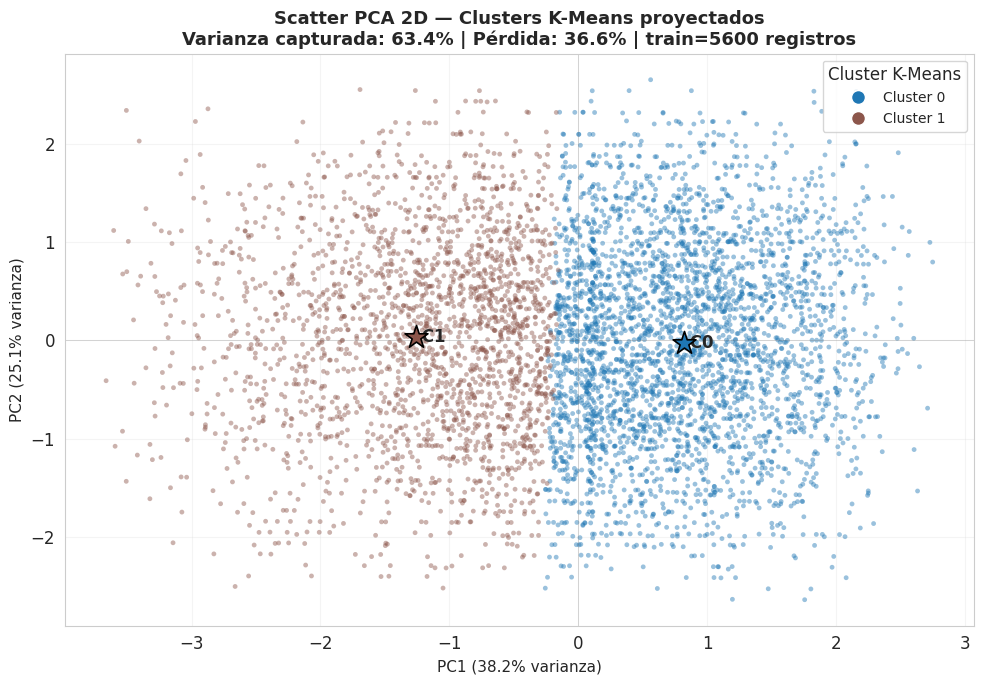

In [94]:
# PASO 10.4: SCATTER PCA — CLUSTERS K-MEANS PROYECTADOS

colores_km = [plt.cm.tab10(i/K_OPTIMO) for i in range(K_OPTIMO)]

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(K_OPTIMO):
    mask_c = cluster_labels_km == c
    ax.scatter(X_pca[mask_c, 0], X_pca[mask_c, 1],
               color=colores_km[c], alpha=0.45, s=12, edgecolors='none',
               label=f'Cluster {c}  ({mask_c.sum()} devs)')

# Centroides proyectados
centroides_pca = pca.transform(kmeans_final.cluster_centers_)
for c in range(K_OPTIMO):
    ax.scatter(centroides_pca[c, 0], centroides_pca[c, 1],
               color=colores_km[c], s=300, marker='*',
               edgecolors='black', linewidths=1.2, zorder=10)
    ax.annotate(f' C{c}', (centroides_pca[c, 0], centroides_pca[c, 1]),
                fontsize=12, fontweight='bold', va='center')

ax.set_xlabel(f'PC1 ({var_ratio[0]:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_ratio[1]:.1f}% varianza)', fontsize=11)
ax.set_title(
    f'Scatter PCA 2D — Clusters K-Means proyectados\n'
    f'Varianza capturada: {sum(var_ratio):.1f}% | '
    f'Pérdida: {var_perdida:.1f}% | train={len(X_scaled)} registros',
    fontsize=13, fontweight='bold'
)
ax.axhline(0, color='gray', lw=0.5, alpha=0.4)
ax.axvline(0, color='gray', lw=0.5, alpha=0.4)
handles_sc = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=colores_km[c], markersize=10,
               label=f'Cluster {c}')
    for c in range(K_OPTIMO)
]
ax.legend(handles=handles_sc, title='Cluster K-Means', fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## **10.5 — Registros que cambiaron de cluster tras PCA**

Al re-clusterizar K-Means en el espacio 2D de PCA, algunos puntos quedan asignados
a un cluster diferente al que tenían en el espacio original del modelo.

**Nota tecnica sobre alineacion de etiquetas:**
KMeans puede asignar el nombre 'Cluster 0' o 'Cluster 1' de forma arbitraria en cada ejecucion.
Para contar cambios reales, el codigo busca la **permutacion con mayor coincidencia** entre ambas asignaciones.


In [95]:
# PASO 10.5: REGISTROS QUE CAMBIARON DE CLUSTER TRAS PCA
from itertools import permutations

km_pca        = KMeans(n_clusters=K_OPTIMO, random_state=42)
labels_pca_raw = km_pca.fit_predict(X_pca)

# Alineación de etiquetas
best_labels_pca = labels_pca_raw.copy()
best_match_p    = (cluster_labels_km == labels_pca_raw).sum()
for perm in permutations(range(K_OPTIMO)):
    lp = np.array([perm[l] for l in labels_pca_raw])
    m  = (cluster_labels_km == lp).sum()
    if m > best_match_p:
        best_match_p    = m
        best_labels_pca = lp

# Agregar a df_train_resultado
df_train_resultado['KMeans_PCA'] = best_labels_pca
df_train_resultado['cambio_pca'] = cluster_labels_km != best_labels_pca
n_c_pca = int(df_train_resultado['cambio_pca'].sum())

print('=' * 55)
print(f'  Registros que CAMBIARON : {n_c_pca} ({n_c_pca/len(df_train_resultado)*100:.1f}%)')
print(f'  Registros ESTABLES      : {len(df_train_resultado)-n_c_pca} ({(len(df_train_resultado)-n_c_pca)/len(df_train_resultado)*100:.1f}%)')
print('=' * 55)

print()
print('Patrón de cambios (cluster origen -> cluster destino):')
res_cambios_pca = df_train_resultado[
    df_train_resultado['cambio_pca']
].groupby(['Cluster_KMeans', 'KMeans_PCA']).size().reset_index(name='n')
for _, row in res_cambios_pca.iterrows():
    print(f'  Cluster {int(row.Cluster_KMeans)} -> '
          f'Cluster {int(row.KMeans_PCA)}: {int(row.n)} registros')

  Registros que CAMBIARON : 42 (0.8%)
  Registros ESTABLES      : 5558 (99.2%)

Patrón de cambios (cluster origen -> cluster destino):
  Cluster 1 -> Cluster 0: 42 registros


## **10.6 — Visualizacion: donde estan los puntos que cambiaron**

Las **X negras** son los registros que cambiaron de cluster.
Si se concentran en las fronteras entre clusters, confirma que
son puntos ambiguos cuya asignacion depende de informacion
dimensional que PCA no captura en 2D.


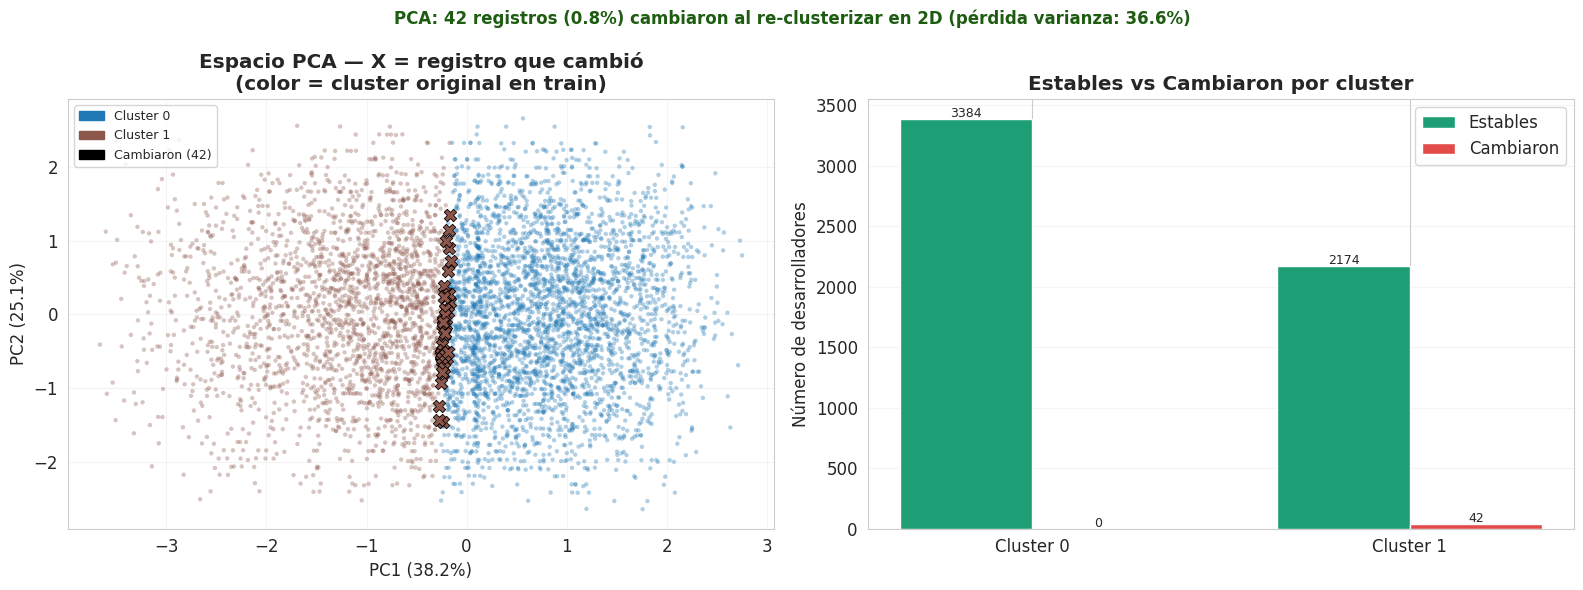

In [96]:
# PASO 10.6: VISUALIZACIÓN — DÓNDE ESTÁN LOS PUNTOS QUE CAMBIARON

mask_cambio_pca = df_train_resultado['cambio_pca'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izq: espacio PCA
for c in range(K_OPTIMO):
    m_est = (cluster_labels_km == c) & (~mask_cambio_pca)
    axes[0].scatter(X_pca[m_est, 0], X_pca[m_est, 1],
                    color=colores_km[c], alpha=0.35, s=10, edgecolors='none')
for c in range(K_OPTIMO):
    m_cam = (cluster_labels_km == c) & mask_cambio_pca
    if m_cam.sum() > 0:
        axes[0].scatter(X_pca[m_cam, 0], X_pca[m_cam, 1],
                        color=colores_km[c], s=80, marker='X', zorder=5,
                        edgecolors='black', linewidths=0.6)

patches_p = [mpatches.Patch(color=colores_km[c], label=f'Cluster {c}')
             for c in range(K_OPTIMO)]
patches_p.append(mpatches.Patch(color='black',
                                label=f'Cambiaron ({n_c_pca})'))
axes[0].legend(handles=patches_p, fontsize=9)
axes[0].set_xlabel(f'PC1 ({var_ratio[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_ratio[1]:.1f}%)')
axes[0].set_title(
    'Espacio PCA — X = registro que cambió\n(color = cluster original en train)',
    fontweight='bold'
)
axes[0].grid(alpha=0.2)

# Panel der: barras estables vs cambiados por cluster
resumen_bar = []
for c in range(K_OPTIMO):
    total_c  = int((cluster_labels_km == c).sum())
    cambio_c = int(((cluster_labels_km == c) & mask_cambio_pca).sum())
    resumen_bar.append({
        'cluster'  : c,
        'Estables' : total_c - cambio_c,
        'Cambiaron': cambio_c
    })
df_bar = pd.DataFrame(resumen_bar)

x_bar = np.arange(K_OPTIMO)
w_bar = 0.35
for i, (col_n, col_c) in enumerate([('Estables', '#1D9E75'),
                                     ('Cambiaron', '#E24B4A')]):
    b = axes[1].bar(x_bar + i*w_bar, df_bar[col_n], w_bar,
                    label=col_n, color=col_c, edgecolor='white')
    for j, val in enumerate(df_bar[col_n]):
        axes[1].text(x_bar[j]+i*w_bar, val+15, str(val),
                     ha='center', fontsize=9)
axes[1].set_xticks(x_bar + w_bar/2)
axes[1].set_xticklabels([f'Cluster {c}' for c in range(K_OPTIMO)])
axes[1].set_ylabel('Número de desarrolladores')
axes[1].set_title('Estables vs Cambiaron por cluster', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.2, axis='y')

col_sup = '#993C1D' if n_c_pca/len(df_train_resultado) > 0.05 else '#1D5C11'
plt.suptitle(
    f'PCA: {n_c_pca} registros ({n_c_pca/len(df_train_resultado)*100:.1f}%)'
    f' cambiaron al re-clusterizar en 2D'
    f' (pérdida varianza: {var_perdida:.1f}%)',
    fontsize=12, fontweight='bold', color=col_sup
)
plt.tight_layout()
plt.show()

## **10.7 — Reduccion con t-SNE**

t-SNE conserva la **estructura de vecindad local**: puntos cercanos en el espacio final del modelo permanecen cercanos en 2D. A diferencia de PCA, no maximiza varianza sino similitud local.

| Parametro | Valor | Efecto |
|---|---|---|
| `perplexity` | 30 | Balance local/global (rango tipico: 5-50) |
| `learning_rate` | 200 | Velocidad de convergencia |
| `random_state` | 42 | Reproducibilidad |

> Los ejes de t-SNE **no tienen interpretacion directa** (no son combinaciones de variables).


In [97]:
# PASO 10.7: t-SNE — PROYECCIÓN 2D NO LINEAL
# Calculado sobre X_train_scaled

print(f'Calculando t-SNE sobre {len(X_scaled)} registros de train...')
tsne_model = TSNE(n_components=2, perplexity=30,
                  learning_rate=200, random_state=42)
X_tsne = tsne_model.fit_transform(X_scaled)
print(f't-SNE completado. Shape: {X_tsne.shape}')


Calculando t-SNE sobre 5600 registros de train...
t-SNE completado. Shape: (5600, 2)


## **10.8 — Scatter t-SNE 2D — Clusters K-Means originales proyectados**

Coloreamos los puntos segun los clusters K-Means obtenidos en el espacio final del modelo.
Si t-SNE preserva bien la vecindad, cada color deberia formar regiones compactas.


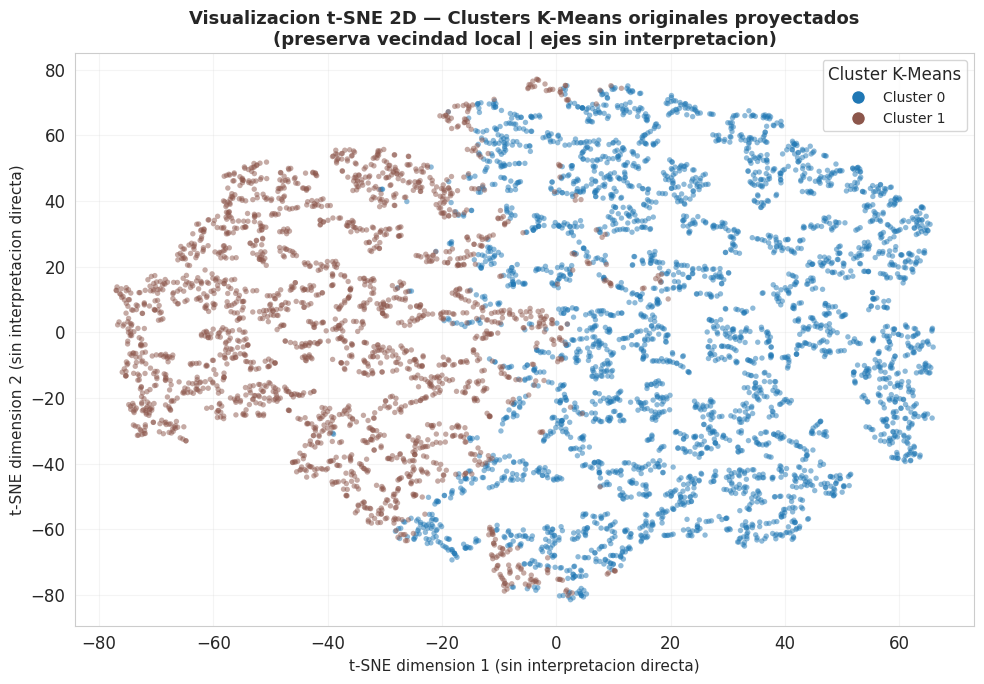

In [98]:
# PASO 10.8: SCATTER t-SNE — CLUSTERS K-MEANS PROYECTADOS
fig, ax = plt.subplots(figsize=(10, 7))
for c in range(K_OPTIMO):
    mask_c = cluster_labels_km == c
    ax.scatter(X_tsne[mask_c, 0], X_tsne[mask_c, 1],
               color=colores_km[c], alpha=0.5, s=15, edgecolors='none',
               label=f'Cluster {c}  ({mask_c.sum()} devs)')

ax.set_xlabel('t-SNE dimension 1 (sin interpretacion directa)', fontsize=11)
ax.set_ylabel('t-SNE dimension 2 (sin interpretacion directa)', fontsize=11)
ax.set_title(
    'Visualizacion t-SNE 2D — Clusters K-Means originales proyectados\n'
    '(preserva vecindad local | ejes sin interpretacion)',
    fontsize=13, fontweight='bold'
)
handles_t = [plt.Line2D([0],[0], marker='o', color='w',
             markerfacecolor=colores_km[c], markersize=10,
             label=f'Cluster {c}') for c in range(K_OPTIMO)]
ax.legend(handles=handles_t, title='Cluster K-Means', fontsize=10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## **10.9 — Comparativa K-Means en espacio final vs K-Means sobre t-SNE 2D**

Re-clusterizamos K-Means en el espacio t-SNE y comparamos con el clustering original.
Se aplica la misma **alineacion de etiquetas** para contar solo cambios reales de asignacion.


In [99]:
# PASO 10.9: COMPARATIVA K-Means espacio final vs t-SNE 2D
km_tsne_model = KMeans(n_clusters=K_OPTIMO, random_state=42)
labels_tsne_raw = km_tsne_model.fit_predict(X_tsne)

# Alineacion de etiquetas
best_labels_tsne = labels_tsne_raw.copy()
best_match_t = (cluster_labels_km == labels_tsne_raw).sum()
for perm in permutations(range(K_OPTIMO)):
    lp_t = np.array([perm[l] for l in labels_tsne_raw])
    m_t  = (cluster_labels_km == lp_t).sum()
    if m_t > best_match_t:
        best_match_t = m_t
        best_labels_tsne = lp_t

df_train_resultado['KMeans_TSNE'] = best_labels_tsne
df_train_resultado['cambio_tsne'] = cluster_labels_km != best_labels_tsne
n_c_tsne = int(df_train_resultado['cambio_tsne'].sum())

print('=' * 55)
print(f'  Registros que CAMBIARON : {n_c_tsne} ({n_c_tsne/len(df_train_resultado)*100:.1f}%)')
print(f'  Registros ESTABLES      : {len(df_train_resultado)-n_c_tsne} ({(len(df_train_resultado)-n_c_tsne)/len(df_train_resultado)*100:.1f}%)')
print('=' * 55)

print()
print('Patron de cambios t-SNE:')
res_cambios_tsne = df_train_resultado[
    df_train_resultado['cambio_tsne']
].groupby(['Cluster_KMeans', 'KMeans_TSNE']).size().reset_index(name='n')
for _, row in res_cambios_tsne.iterrows():
    print(f'  Cluster {int(row.Cluster_KMeans)} -> Cluster {int(row.KMeans_TSNE)}: {int(row.n)} registros')

print()
if n_c_tsne <= 100:
    cols_show = [c for c in ['age','daily_work_hours','stress_level','sleep_hours',
                             'Cluster_KMeans','KMeans_TSNE'] if c in df_resultado.columns]
    print('Registros que cambiaron en t-SNE (muestra):')
    print(df_resultado[df_resultado['cambio_tsne']][cols_show].head(15).to_string(index=False))
else:
    print(f'({n_c_tsne} registros cambiaron — puntos fronterizos entre clusters)')


  Registros que CAMBIARON : 979 (17.5%)
  Registros ESTABLES      : 4621 (82.5%)

Patron de cambios t-SNE:
  Cluster 0 -> Cluster 1: 742 registros
  Cluster 1 -> Cluster 0: 237 registros

(979 registros cambiaron — puntos fronterizos entre clusters)


## **10.10 — Resumen comparativo PCA vs t-SNE — valores reales**

###**Tabla consolidada con los resultados obtenidos en esta ejecucion.**


In [100]:
# PASO 10.10: RESUMEN COMPARATIVO PCA vs t-SNE
print('Comparativa PCA vs t-SNE')
print()
ancho = 32
print(f'{"":{ancho}} {"PCA":>20} {"t-SNE":>20}')
print('-' * 74)
rows = [
    ('Tipo de transformacion',  'Lineal',              'No lineal'),
    ('Preserva',                'Varianza global',     'Vecindad local'),
    ('Varianza capturada',      f'{sum(var_ratio):.1f}%', 'N/A'),
    ('Varianza perdida',        f'{var_perdida:.1f}%', 'N/A'),
    ('Registros que cambian',
     f'{n_c_pca} ({n_c_pca/len(df_train_resultado)*100:.1f}%)',
     f'{n_c_tsne} ({n_c_tsne/len(df_train_resultado)*100:.1f}%)'),
    ('Interpretacion de ejes',  'Si (loadings)',       'No (directo)'),
    ('Velocidad',               'Rapida',              'Lenta (n grande)'),
    ('Uso principal',           'Analisis/reduccion',  'Visualizacion'),
]
for r in rows:
    print(f'{r[0]:{ancho}} {r[1]:>20} {r[2]:>20}')
print()

if n_c_tsne < n_c_pca:
    print(f'Fidelidad al clustering del espacio final: t-SNE es mas fiel')
    print(f'  t-SNE: {n_c_tsne} cambios ({n_c_tsne/len(df_resultado)*100:.1f}%)')
    print(f'  PCA:   {n_c_pca} cambios ({n_c_pca/len(df_resultado)*100:.1f}%)')
    print(f'  t-SNE preserva la vecindad local que K-Means uso para crear los clusters.')
else:
    print(f'Fidelidad al clustering del espacio final: PCA es mas fiel en este caso')
    print(f'  PCA:   {n_c_pca} cambios ({n_c_pca/len(df_resultado)*100:.1f}%)')
    print(f'  t-SNE: {n_c_tsne} cambios ({n_c_tsne/len(df_resultado)*100:.1f}%)')
print()
print('Cuando usar cada uno:')
print('  PCA   -> para entender que variables explican la variacion (loadings)')
print('  t-SNE -> para VISUALIZAR clusters y detectar estructura local')
print('  Ambos -> tecnicas complementarias, no excluyentes')


Comparativa PCA vs t-SNE

                                                  PCA                t-SNE
--------------------------------------------------------------------------
Tipo de transformacion                         Lineal            No lineal
Preserva                              Varianza global       Vecindad local
Varianza capturada                              63.4%                  N/A
Varianza perdida                                36.6%                  N/A
Registros que cambian                       42 (0.8%)          979 (17.5%)
Interpretacion de ejes                  Si (loadings)         No (directo)
Velocidad                                      Rapida     Lenta (n grande)
Uso principal                      Analisis/reduccion        Visualizacion

Fidelidad al clustering del espacio final: PCA es mas fiel en este caso
  PCA:   42 cambios (0.6%)
  t-SNE: 979 cambios (14.0%)

Cuando usar cada uno:
  PCA   -> para entender que variables explican la variacion (loadings)


## **10.11 — Comparativa visual PCA vs t-SNE**

Panel lado a lado: mismos clusters K-Means del espacio final proyectados con PCA y con t-SNE.
Las **X negras** son los registros que cambiaron de cluster al re-clusterizar en 2D.


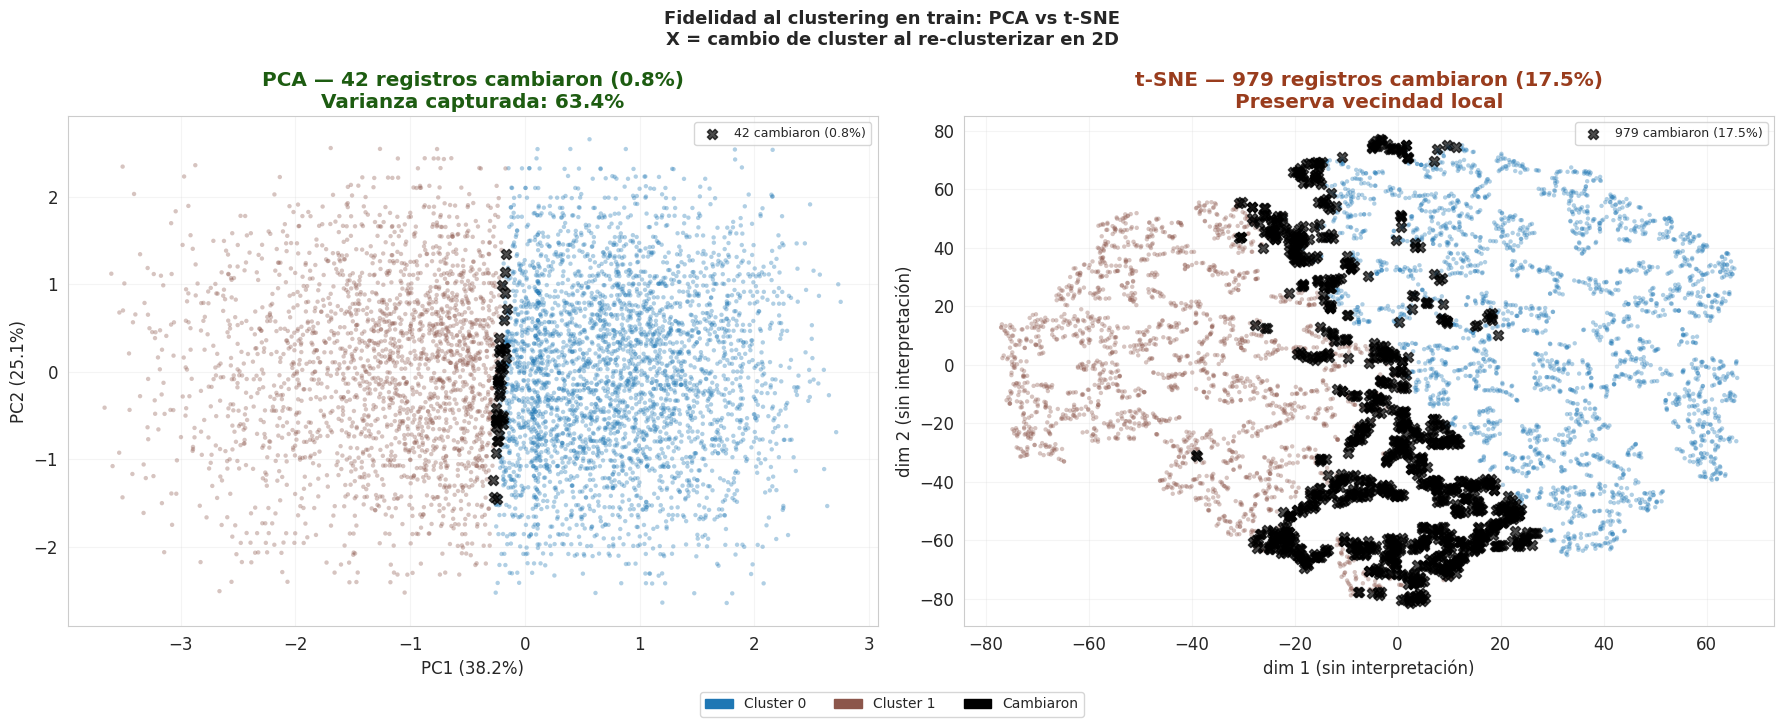


RESUMEN FINAL:
  PCA  : 42 cambios (0.8%) -- lineal, pierde 36.6% varianza
  t-SNE: 979 cambios (17.5%) -- no lineal, preserva vecindad local
  -> PCA es más fiel al clustering original en train


In [101]:
# PASO 10.11: PANEL COMPARATIVO VISUAL PCA vs t-SNE

mask_cambio_pca  = df_train_resultado['cambio_pca'].values   # ← df_train_resultado
mask_cambio_tsne = df_train_resultado['cambio_tsne'].values  # ← df_train_resultado

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Panel PCA
for c in range(K_OPTIMO):
    m_e = (cluster_labels_km == c) & (~mask_cambio_pca)
    axes[0].scatter(X_pca[m_e, 0], X_pca[m_e, 1],
                    color=colores_km[c], alpha=0.35, s=10, edgecolors='none')
axes[0].scatter(X_pca[mask_cambio_pca, 0], X_pca[mask_cambio_pca, 1],
                color='black', s=55, marker='X', zorder=5, alpha=0.7,
                label=f'{n_c_pca} cambiaron ({n_c_pca/len(df_train_resultado)*100:.1f}%)')
col0 = '#993C1D' if n_c_pca/len(df_train_resultado) > 0.05 else '#1D5C11'
axes[0].set_title(
    f'PCA — {n_c_pca} registros cambiaron ({n_c_pca/len(df_train_resultado)*100:.1f}%)\n'
    f'Varianza capturada: {sum(var_ratio):.1f}%',
    fontweight='bold', color=col0
)
axes[0].set_xlabel(f'PC1 ({var_ratio[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({var_ratio[1]:.1f}%)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# Panel t-SNE
for c in range(K_OPTIMO):
    m_e_t = (cluster_labels_km == c) & (~mask_cambio_tsne)
    axes[1].scatter(X_tsne[m_e_t, 0], X_tsne[m_e_t, 1],
                    color=colores_km[c], alpha=0.35, s=10, edgecolors='none')
axes[1].scatter(X_tsne[mask_cambio_tsne, 0], X_tsne[mask_cambio_tsne, 1],
                color='black', s=55, marker='X', zorder=5, alpha=0.7,
                label=f'{n_c_tsne} cambiaron ({n_c_tsne/len(df_train_resultado)*100:.1f}%)')
col1 = '#993C1D' if n_c_tsne/len(df_train_resultado) > 0.05 else '#1D5C11'
axes[1].set_title(
    f't-SNE — {n_c_tsne} registros cambiaron ({n_c_tsne/len(df_train_resultado)*100:.1f}%)\n'
    f'Preserva vecindad local',
    fontweight='bold', color=col1
)
axes[1].set_xlabel('dim 1 (sin interpretación)')
axes[1].set_ylabel('dim 2 (sin interpretación)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

# Leyenda compartida
patches_sh = [mpatches.Patch(color=colores_km[c], label=f'Cluster {c}')
              for c in range(K_OPTIMO)]
patches_sh.append(mpatches.Patch(color='black', label='Cambiaron'))
fig.legend(handles=patches_sh, loc='lower center', ncol=K_OPTIMO+1,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.suptitle(
    f'Fidelidad al clustering en train: PCA vs t-SNE\n'
    f'X = cambio de cluster al re-clusterizar en 2D',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print()
print('RESUMEN FINAL:')
print(f'  PCA  : {n_c_pca} cambios ({n_c_pca/len(df_train_resultado)*100:.1f}%)'
      f' -- lineal, pierde {var_perdida:.1f}% varianza')
print(f'  t-SNE: {n_c_tsne} cambios ({n_c_tsne/len(df_train_resultado)*100:.1f}%)'
      f' -- no lineal, preserva vecindad local')
mejor_final = 't-SNE' if n_c_tsne < n_c_pca else 'PCA'
print(f'  -> {mejor_final} es más fiel al clustering original en train')


---
# **11 — Deteccion de Anomalias: Isolation Forest + LOF**

## **¿Por que detectar anomalias?**
Los clusters K-Means y DBSCAN agrupan perfiles tipicos. Las **anomalias** son desarrolladores
cuyo perfil es estadisticamente inusual: no encajan bien en ningun patron esperado.
Identificarlos es valioso para RRHH y gestion del equipo.

| Metodo | Enfoque | Ventaja |
|---|---|---|
| **Isolation Forest** | Arboles de aislamiento aleatorios | Escala bien, rapido en datasets grandes |
| **LOF** | Densidad local vs vecinos | Detecta anomalias locales (relativas al entorno) |

**Estrategia:** Usar **ambos y comparar**.
- Si un punto es marcado por **ambos metodos** → mayor confianza de que es anomalia real
- Si solo uno lo marca → posible caso borde, requiere revision

> `contamination=0.05` → se asume que aprox. el 5% del dataset son anomalias.
> Este parametro puede ajustarse segun el criterio del negocio.


## **11.1 — Isolation Forest**

Isolation Forest construye arboles de decision aleatorios.
Los puntos que se **aislan en pocas divisiones** son anómalos:
son los mas faciles de separar del resto porque tienen valores extremos en alguna variable.


Isolation Forest — entrenado sobre 5600 registros (train)
Anomalías detectadas : 280 (5.0%)
Normales             : 5320 (95.0%)

Perfil promedio — Normales vs Anomalías (IF):


,caffeine_intake,ratio_trabajo_descanso,carga_operativa,indice_recuperacion
grupo,,,,
Anomalía IF,3.54,2.28,13.01,6.20
Normal,3.53,1.43,14.07,7.54


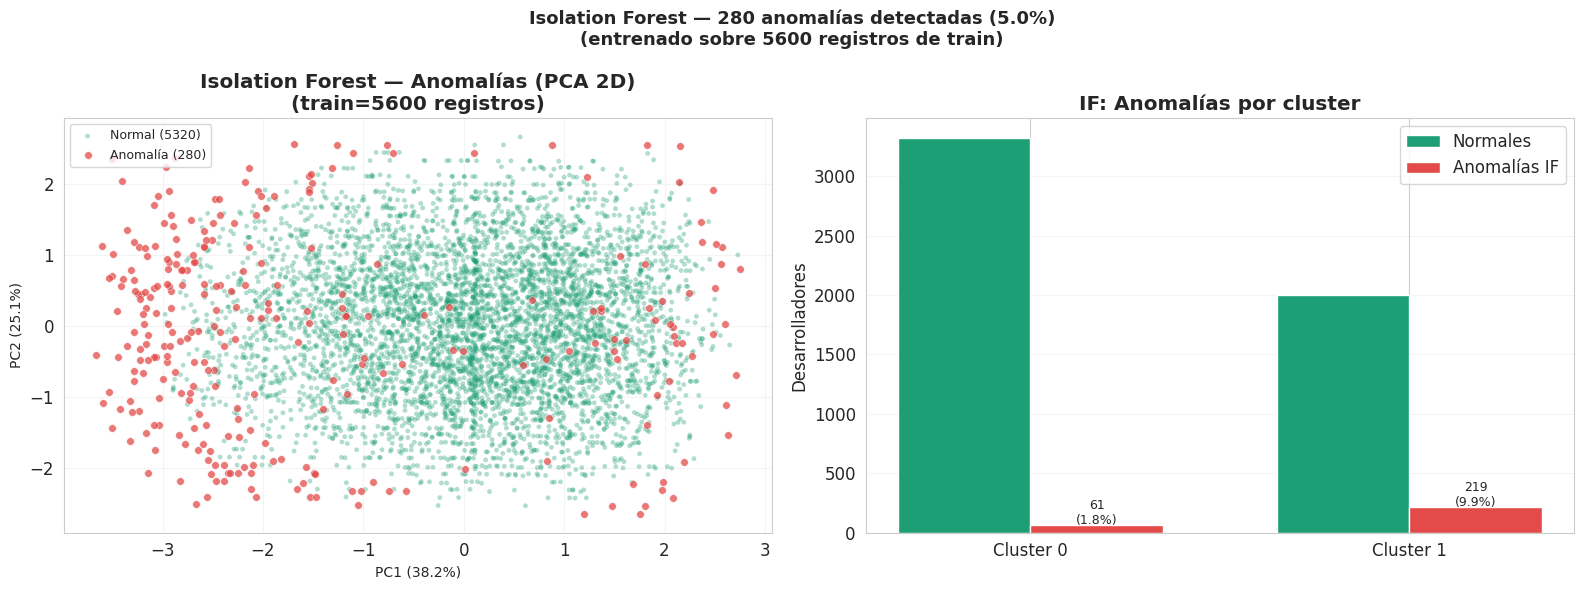

In [102]:
# PASO 11.1: ISOLATION FOREST
# Entrenado sobre X_train_scaled

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_train_resultado['Anomaly_IF'] = iso_forest.fit_predict(X_scaled)

n_if = (df_train_resultado['Anomaly_IF'] == -1).sum()
print(f'Isolation Forest — entrenado sobre {len(X_scaled)} registros (train)')
print(f'Anomalías detectadas : {n_if} ({n_if/len(df_train_resultado)*100:.1f}%)')
print(f'Normales             : {len(df_train_resultado)-n_if} ({(len(df_train_resultado)-n_if)/len(df_train_resultado)*100:.1f}%)')

# Perfil anomalías vs normales — usando variables del modelo
print()
print('Perfil promedio — Normales vs Anomalías (IF):')
perfil_if = df_train_resultado.copy()
perfil_if['grupo'] = perfil_if['Anomaly_IF'].map({1: 'Normal', -1: 'Anomalía IF'})
display(perfil_if.groupby('grupo')[cols_perfil].mean().round(2))

# Visualización IF
pca_viz   = PCA(n_components=2, random_state=42)
X_pca_viz = pca_viz.fit_transform(X_scaled)
var_viz   = pca_viz.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask_norm_if = df_train_resultado['Anomaly_IF'] == 1
mask_anom_if = df_train_resultado['Anomaly_IF'] == -1

axes[0].scatter(X_pca_viz[mask_norm_if, 0], X_pca_viz[mask_norm_if, 1],
                c='#1D9E75', alpha=0.35, s=12, edgecolors='none',
                label=f'Normal ({mask_norm_if.sum()})')
axes[0].scatter(X_pca_viz[mask_anom_if, 0], X_pca_viz[mask_anom_if, 1],
                c='#E24B4A', alpha=0.75, s=30, edgecolors='white',
                linewidths=0.4, zorder=5,
                label=f'Anomalía ({mask_anom_if.sum()})')
axes[0].set_xlabel(f'PC1 ({var_viz[0]:.1f}%)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({var_viz[1]:.1f}%)', fontsize=10)
axes[0].set_title(
    f'Isolation Forest — Anomalías (PCA 2D)\n'
    f'(train={len(X_scaled)} registros)',
    fontweight='bold'
)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# Barras por cluster
anom_por_cluster = df_train_resultado.groupby('Cluster_KMeans')['Anomaly_IF'].apply(
    lambda x: (x == -1).sum()
).reset_index()
norm_por_cluster = df_train_resultado.groupby('Cluster_KMeans')['Anomaly_IF'].apply(
    lambda x: (x == 1).sum()
).reset_index()
anom_por_cluster.columns = ['Cluster', 'Anomalías']
norm_por_cluster.columns = ['Cluster', 'Normales']
merged_if = anom_por_cluster.merge(norm_por_cluster, on='Cluster')

x_if = np.arange(K_OPTIMO)
w_if = 0.35
axes[1].bar(x_if - w_if/2, merged_if['Normales'], w_if,
            label='Normales', color='#1D9E75', edgecolor='white')
axes[1].bar(x_if + w_if/2, merged_if['Anomalías'], w_if,
            label='Anomalías IF', color='#E24B4A', edgecolor='white')
for j, row in merged_if.iterrows():
    total = row['Anomalías'] + row['Normales']
    pct_a = row['Anomalías'] / total * 100
    axes[1].text(j + w_if/2, row['Anomalías'] + 10,
                 f'{row["Anomalías"]}\n({pct_a:.1f}%)',
                 ha='center', fontsize=9)
axes[1].set_xticks(x_if)
axes[1].set_xticklabels([f'Cluster {c}' for c in range(K_OPTIMO)])
axes[1].set_ylabel('Desarrolladores')
axes[1].set_title('IF: Anomalías por cluster', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.2, axis='y')

plt.suptitle(
    f'Isolation Forest — {n_if} anomalías detectadas '
    f'({n_if/len(df_train_resultado)*100:.1f}%)\n'
    f'(entrenado sobre {len(X_scaled)} registros de train)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

## **11.2 — LOF (Local Outlier Factor)**

LOF compara la **densidad local** de cada punto con la de sus vecinos.
Un punto con densidad mucho menor que sus vecinos recibe un LOF score alto → es un outlier **local**.

A diferencia de Isolation Forest, LOF detecta anomalias **relativas al contexto**:
un punto puede ser normal globalmente pero anomalo dentro de su vecindad.

- `n_neighbors=20` → numero de vecinos para estimar densidad local
- `contamination=0.05` → proporcion esperada de anomalias


LOF — entrenado sobre 5600 registros (train)
LOF — Anomalías : 280 (5.0%)
IF  — Anomalías : 280 (5.0%)
Consenso IF+LOF : 115 (2.1%) — mayor confianza

LOF scores — max: 1.585 | min: 0.965 | media: 1.026
Top 5 LOF scores (más anómalos): [1.585 1.518 1.504 1.473 1.449]


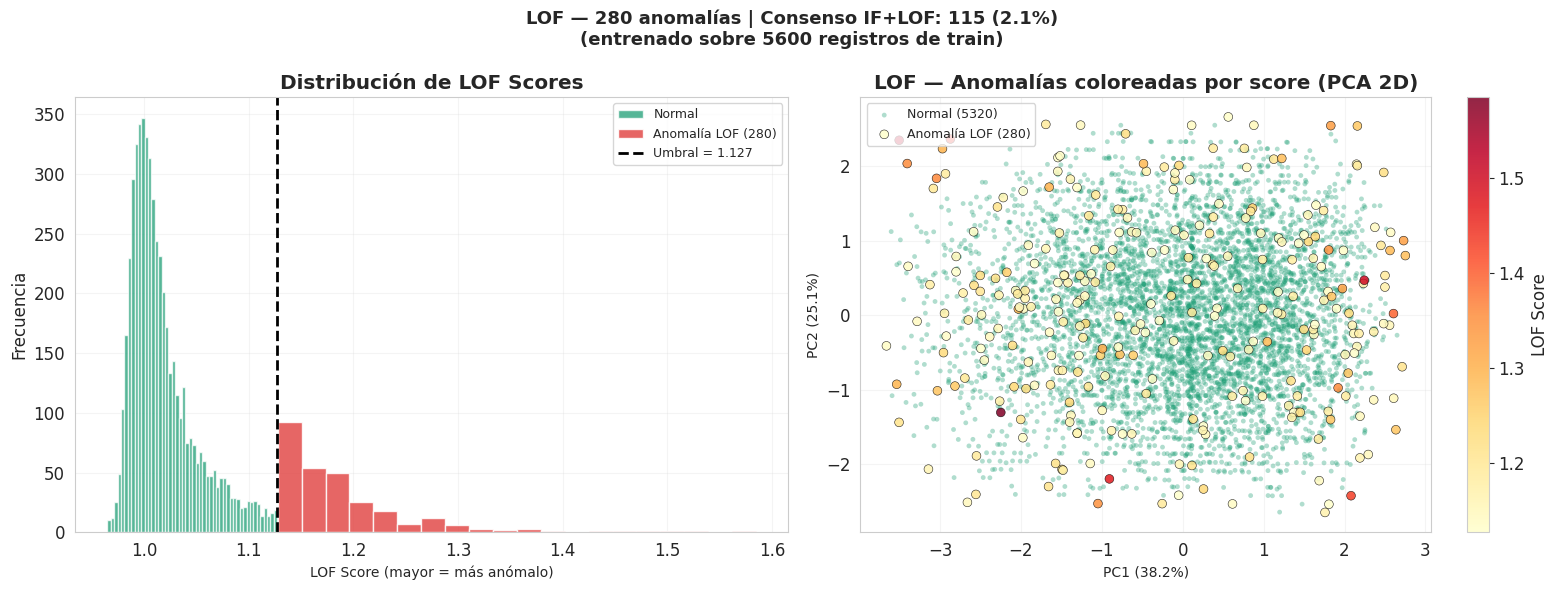

In [103]:
# PASO 11.2: LOF — LOCAL OUTLIER FACTOR
# Entrenado sobre X_train_scaled

lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_train_resultado['Anomaly_LOF'] = lof_model.fit_predict(X_scaled)
lof_scores = -lof_model.negative_outlier_factor_

n_lof  = (df_train_resultado['Anomaly_LOF'] == -1).sum()
n_both = ((df_train_resultado['Anomaly_IF'] == -1) &
          (df_train_resultado['Anomaly_LOF'] == -1)).sum()

print(f'LOF — entrenado sobre {len(X_scaled)} registros (train)')
print(f'LOF — Anomalías : {n_lof} ({n_lof/len(df_train_resultado)*100:.1f}%)')
print(f'IF  — Anomalías : {(df_train_resultado["Anomaly_IF"]==-1).sum()} '
      f'({(df_train_resultado["Anomaly_IF"]==-1).sum()/len(df_train_resultado)*100:.1f}%)')
print(f'Consenso IF+LOF : {n_both} ({n_both/len(df_train_resultado)*100:.1f}%) '
      f'— mayor confianza')
print()
print(f'LOF scores — max: {lof_scores.max():.3f} | '
      f'min: {lof_scores.min():.3f} | '
      f'media: {lof_scores.mean():.3f}')
print('Top 5 LOF scores (más anómalos):',
      np.sort(lof_scores)[::-1][:5].round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma LOF scores
umbral_lof = np.sort(lof_scores)[::-1][n_lof-1]
axes[0].hist(lof_scores[lof_scores <= umbral_lof], bins=50,
             color='#1D9E75', alpha=0.75, edgecolor='white', label='Normal')
axes[0].hist(lof_scores[lof_scores > umbral_lof], bins=20,
             color='#E24B4A', alpha=0.85, edgecolor='white',
             label=f'Anomalía LOF ({n_lof})')
axes[0].axvline(umbral_lof, color='black', linestyle='--',
                lw=2, label=f'Umbral = {umbral_lof:.3f}')
axes[0].set_xlabel('LOF Score (mayor = más anómalo)', fontsize=10)
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de LOF Scores', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# Scatter PCA con anomalías LOF
mask_norm_lof = df_train_resultado['Anomaly_LOF'] == 1
mask_anom_lof = df_train_resultado['Anomaly_LOF'] == -1
axes[1].scatter(X_pca_viz[mask_norm_lof, 0], X_pca_viz[mask_norm_lof, 1],
                c='#1D9E75', alpha=0.35, s=12, edgecolors='none',
                label=f'Normal ({mask_norm_lof.sum()})')
sc2 = axes[1].scatter(X_pca_viz[mask_anom_lof, 0], X_pca_viz[mask_anom_lof, 1],
                       c=lof_scores[mask_anom_lof], cmap='YlOrRd',
                       alpha=0.85, s=40, edgecolors='black',
                       linewidths=0.4, zorder=5,
                       label=f'Anomalía LOF ({mask_anom_lof.sum()})')
plt.colorbar(sc2, ax=axes[1], label='LOF Score')
axes[1].set_xlabel(f'PC1 ({var_viz[0]:.1f}%)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({var_viz[1]:.1f}%)', fontsize=10)
axes[1].set_title(
    'LOF — Anomalías coloreadas por score (PCA 2D)',
    fontweight='bold'
)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)

plt.suptitle(
    f'LOF — {n_lof} anomalías | Consenso IF+LOF: {n_both} '
    f'({n_both/len(df_train_resultado)*100:.1f}%)\n'
    f'(entrenado sobre {len(X_scaled)} registros de train)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 🔗 Paso 11.2B — Cruce DBSCAN vs IF/LOF

Ahora que IF y LOF han sido calculados, se verifica cuántos de los puntos
marcados como **ruido por DBSCAN** coinciden con las anomalías detectadas por
Isolation Forest y LOF. Una coincidencia alta indica que los tres métodos
convergen en los mismos desarrolladores atípicos.

In [104]:
# PASO 11.2B: CRUCE DBSCAN RUIDO vs ANOMALÍAS IF/LOF
# Los puntos de ruido DBSCAN (-1) deberían coincidir parcialmente
# con las anomalías detectadas por IF y LOF en el Paso 11
# Esta celda se ejecuta DESPUÉS del Paso 11 o se revisa al final

# Verificar si IF y LOF ya fueron ejecutados
if 'Anomaly_IF' in df_train_resultado.columns and \
   'Anomaly_LOF' in df_train_resultado.columns:

    mask_dbscan_ruido = df_train_resultado['DBSCAN_Cluster'] == -1
    mask_if_anomalia  = df_train_resultado['Anomaly_IF']  == -1
    mask_lof_anomalia = df_train_resultado['Anomaly_LOF'] == -1

    n_ruido    = mask_dbscan_ruido.sum()
    solapamiento_if  = (mask_dbscan_ruido & mask_if_anomalia).sum()
    solapamiento_lof = (mask_dbscan_ruido & mask_lof_anomalia).sum()
    solapamiento_3   = (mask_dbscan_ruido & mask_if_anomalia & mask_lof_anomalia).sum()

    print("=" * 60)
    print("  CRUCE: Ruido DBSCAN vs Anomalías IF y LOF")
    print("=" * 60)
    print(f"  Ruido DBSCAN total       : {n_ruido} ({n_ruido/len(df_train_resultado)*100:.1f}%)")
    print(f"  Ruido DBSCAN ∩ IF        : {solapamiento_if} "
          f"({solapamiento_if/n_ruido*100:.1f}% del ruido)")
    print(f"  Ruido DBSCAN ∩ LOF       : {solapamiento_lof} "
          f"({solapamiento_lof/n_ruido*100:.1f}% del ruido)")
    print(f"  Ruido DBSCAN ∩ IF ∩ LOF  : {solapamiento_3} "
          f"({solapamiento_3/n_ruido*100:.1f}% del ruido) ← máxima confianza")
    print()
    print("  Interpretación:")
    pct_3 = solapamiento_3 / n_ruido * 100 if n_ruido > 0 else 0
    if pct_3 > 50:
        print(f"  ✅ Más del 50% del ruido DBSCAN coincide con consenso IF+LOF.")
        print(f"     Los tres métodos apuntan a los mismos desarrolladores atípicos.")
    else:
        print(f"  ⚠️  El ruido DBSCAN y el consenso IF+LOF detectan anomalías distintas.")
        print(f"     DBSCAN detecta outliers globales de densidad;")
        print(f"     IF/LOF detectan outliers estadísticos de distribución.")
        print(f"     Ambos son válidos desde perspectivas complementarias.")
else:
    print("ℹ️  IF y LOF aún no ejecutados.")
    print("   Volver a esta celda después del Paso 11 para el cruce completo.")
    print("   O ejecutar el Paso 11 primero y luego re-ejecutar esta celda.")

  CRUCE: Ruido DBSCAN vs Anomalías IF y LOF
  Ruido DBSCAN total       : 198 (3.5%)
  Ruido DBSCAN ∩ IF        : 112 (56.6% del ruido)
  Ruido DBSCAN ∩ LOF       : 112 (56.6% del ruido)
  Ruido DBSCAN ∩ IF ∩ LOF  : 68 (34.3% del ruido) ← máxima confianza

  Interpretación:
  ⚠️  El ruido DBSCAN y el consenso IF+LOF detectan anomalías distintas.
     DBSCAN detecta outliers globales de densidad;
     IF/LOF detectan outliers estadísticos de distribución.
     Ambos son válidos desde perspectivas complementarias.


## **11.3 — Analisis LOF: grupos de anomalias**

Los outliers LOF no son homogeneos: pertenecen a distintos perfiles atipicos.
Analizamos las variables que mas se desvian de la media para entender **por que** cada
desarrollador es anomalo.

| Grupo | Patron tipico | Implicacion |
|---|---|---|
| Bajo stress + pocas horas | Combinacion inusual en el dataset | Posible sub-reporte o outlier de datos |
| Alto stress sin burnout alto | Resiliencia atipica | Perfil de interes para RRHH |
| Extremos en productividad | Muchos bugs O muchos commits + patron anomalo | Revisar carga y calidad |


In [105]:
# PASO 11.3: ANÁLISIS DETALLADO LOF

df_train_resultado['LOF_Score']      = lof_scores
df_train_resultado['Consenso_IF_LOF'] = (
    (df_train_resultado['Anomaly_IF'] == -1) &
    (df_train_resultado['Anomaly_LOF'] == -1)
).astype(int)

# Perfil comparativo usando variables del modelo
df_perfil = df_train_resultado[cols_perfil].copy()
df_perfil['grupo'] = 'Normal'
df_perfil.loc[df_train_resultado['Anomaly_LOF'] == -1, 'grupo'] = 'Anomalía LOF'
df_perfil.loc[df_train_resultado['Consenso_IF_LOF'] == 1, 'grupo'] = 'Consenso IF+LOF'

print('Perfil promedio por grupo:')
display(df_perfil.groupby('grupo')[cols_perfil].mean().round(2))

# Burnout_level en anomalías
print()
print('Distribución burnout_level en Anomalías LOF vs Normales:')
df_perfil['burnout_level'] = df_train_resultado['burnout_level'].values
blt = pd.crosstab(df_perfil['grupo'],
                  df_perfil['burnout_level'],
                  normalize='index').round(3) * 100
display(blt)

# Desviación de la media para cada variable
print()
print('Variables con mayor desviación relativa (Anomalías LOF vs Normales):')
norm_means = df_perfil[df_perfil['grupo'] == 'Normal'][cols_perfil].mean()
anom_means = df_perfil[df_perfil['grupo'] == 'Anomalía LOF'][cols_perfil].mean()
desviaciones = ((anom_means - norm_means) / norm_means * 100).sort_values(
    key=abs, ascending=False
)
for var, pct in desviaciones.items():
    barra = '+' * int(abs(pct)/2) if pct > 0 else '-' * int(abs(pct)/2)
    print(f'  {var:<30}: {pct:+6.1f}%  {barra}')

# Top outliers más extremos
print()
print('Top 10 desarrolladores con mayor LOF Score (más anómalos):')
cols_show = cols_perfil[:5] + ['LOF_Score', 'Cluster_KMeans', 'Consenso_IF_LOF']
top10 = df_train_resultado.nlargest(10, 'LOF_Score')[cols_show]
display(top10.reset_index(drop=True))


Perfil promedio por grupo:


,caffeine_intake,ratio_trabajo_descanso,carga_operativa,indice_recuperacion
grupo,,,,
Anomalía LOF,3.31,1.54,14.63,7.63
Consenso IF+LOF,3.28,1.86,13.26,7.16
Normal,3.55,1.46,14.02,7.48



Distribución burnout_level en Anomalías LOF vs Normales:


burnout_level,High,Low,Medium
grupo,,,
Anomalía LOF,36.0,25.5,38.5
Consenso IF+LOF,38.4,30.4,31.2
Normal,26.1,22.9,51.0



Variables con mayor desviación relativa (Anomalías LOF vs Normales):
  caffeine_intake               :   -6.7%  ---
  ratio_trabajo_descanso        :   +5.0%  ++
  carga_operativa               :   +4.4%  ++
  indice_recuperacion           :   +2.0%  +

Top 10 desarrolladores con mayor LOF Score (más anómalos):


,caffeine_intake,ratio_trabajo_descanso,carga_operativa,indice_recuperacion,LOF_Score,Cluster_KMeans,Consenso_IF_LOF
0,6.0,3.333333,9.0,NaN,1.584619,1,1
1,0.0,3.289855,25.0,4.62,1.518092,1,1
2,7.0,0.683066,28.0,10.36,1.504165,0,1
3,7.0,1.063636,4.0,4.49,1.473388,1,1
4,1.0,2.699769,28.0,4.48,1.449106,1,1
5,7.0,1.068004,2.0,10.92,1.431913,0,1
6,7.0,0.492588,24.0,10.63,1.394257,0,1
7,2.0,3.386534,26.0,5.90,1.360805,1,1
8,2.0,1.124571,1.0,10.64,1.357487,0,1
9,1.0,3.158508,25.0,4.51,1.357298,1,1


## **11.4 — Visualizacion LOF completa**

Panel de 4 graficas para un analisis visual completo:
1. Scatter PCA: normales vs anomalias vs consenso
2. LOF Score vs Cluster K-Means
3. Comparativa de variables clave: normales vs anomalias
4. Distribucion de anomalias por cluster


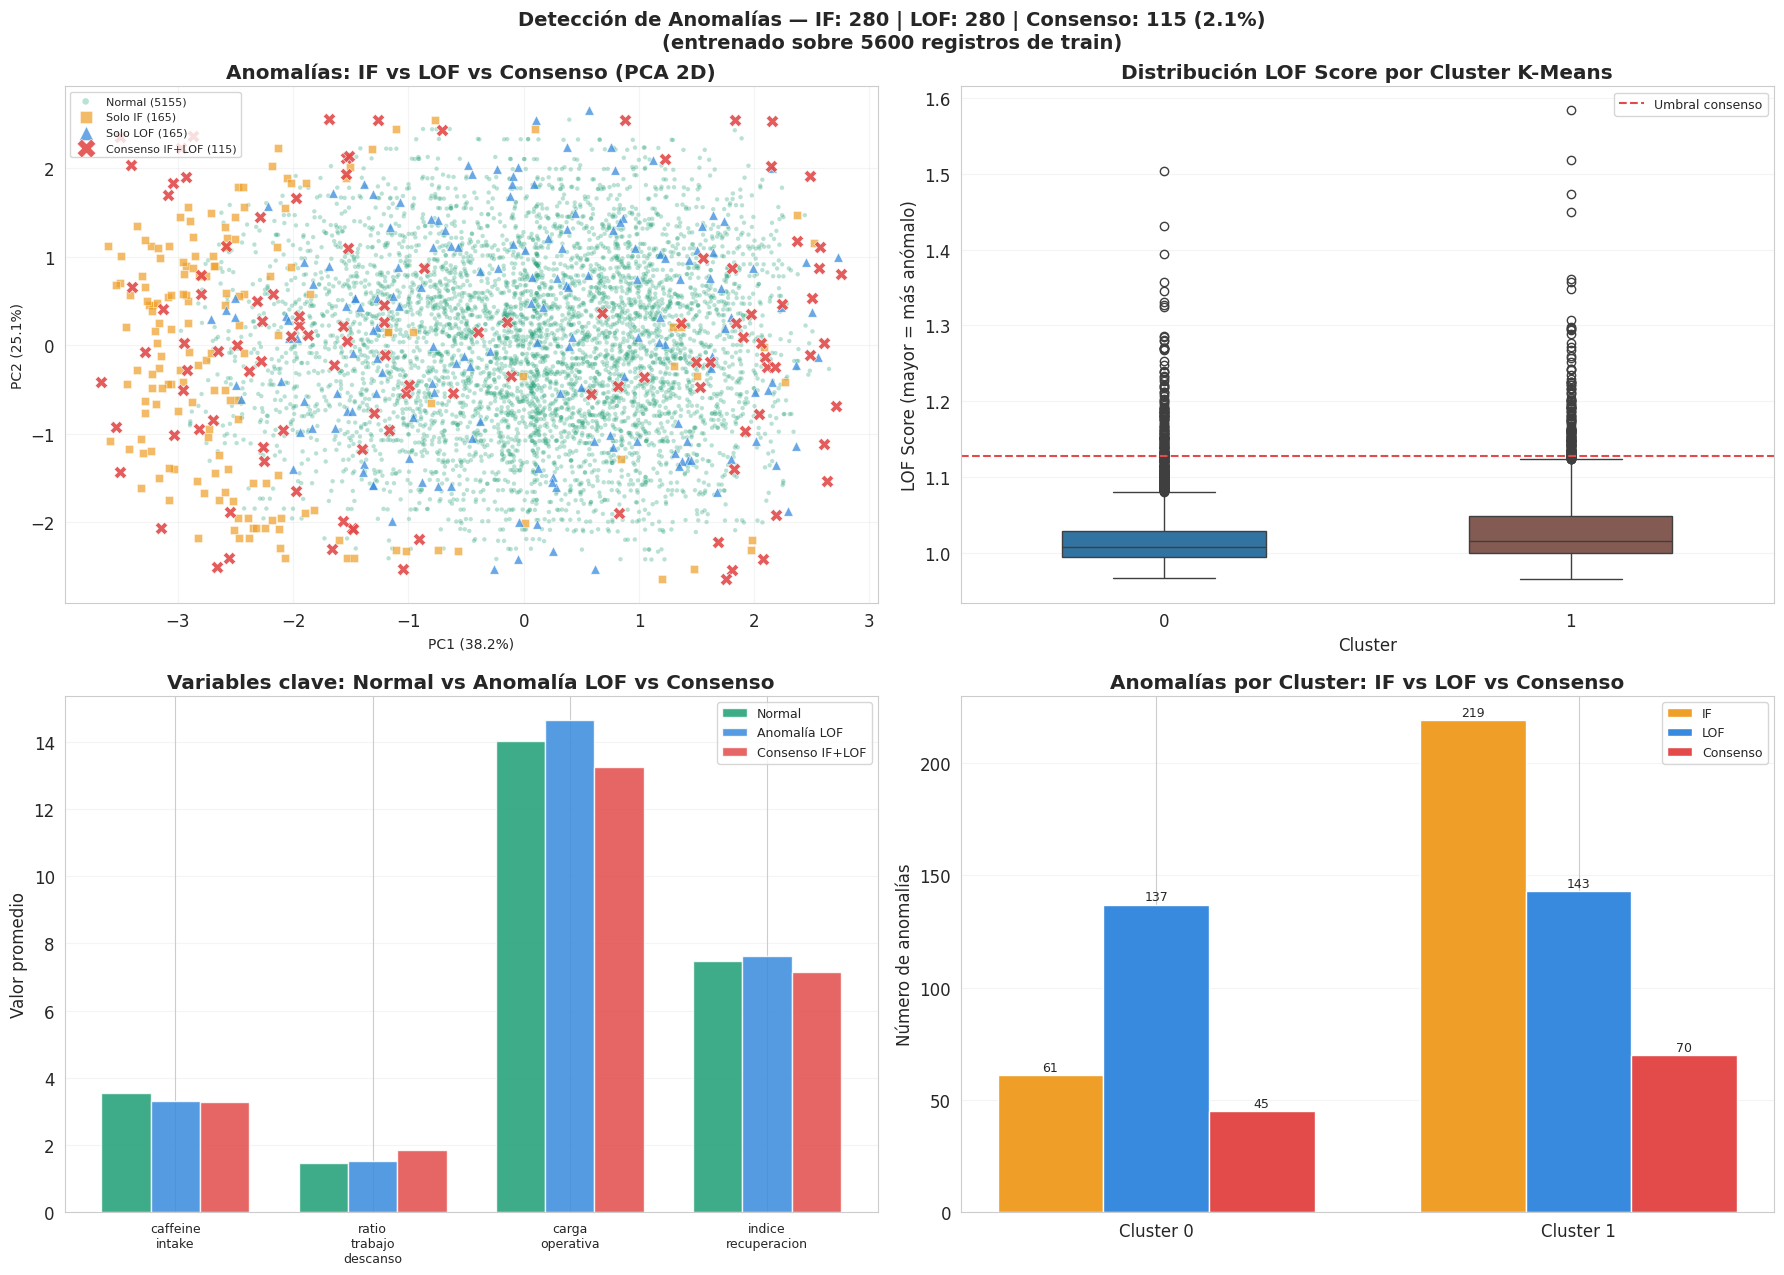


Interpretación:
  115 desarrolladores anómalos según AMBOS métodos → mayor confianza
  Anomalías exclusivas IF  : 165 → casos borde a nivel global
  Anomalías exclusivas LOF : 165 → inusuales solo en su vecindad local


In [106]:
# PASO 11.4: PANEL VISUALIZACIÓN LOF COMPLETA

mask_norm     = ((df_train_resultado['Anomaly_LOF'] == 1) &
                 (df_train_resultado['Anomaly_IF'] == 1))
mask_solo_lof = ((df_train_resultado['Anomaly_LOF'] == -1) &
                 (df_train_resultado['Anomaly_IF'] == 1))
mask_solo_if  = ((df_train_resultado['Anomaly_LOF'] == 1) &
                 (df_train_resultado['Anomaly_IF'] == -1))
mask_ambos    = df_train_resultado['Consenso_IF_LOF'] == 1

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

# Gráfica 1: Scatter PCA por categoría
capas = [
    (mask_norm,     '#1D9E75', 'o', 10, 0.3, f'Normal ({mask_norm.sum()})'),
    (mask_solo_if,  '#EF9F27', 's', 35, 0.7, f'Solo IF ({mask_solo_if.sum()})'),
    (mask_solo_lof, '#378ADD', '^', 45, 0.75, f'Solo LOF ({mask_solo_lof.sum()})'),
    (mask_ambos,    '#E24B4A', 'X', 80, 0.9,
     f'Consenso IF+LOF ({mask_ambos.sum()})'),
]
for mask_c, col, mk, sz, al, lbl in capas:
    axes[0, 0].scatter(
        X_pca_viz[mask_c, 0], X_pca_viz[mask_c, 1],
        c=col, marker=mk, s=sz, alpha=al,
        edgecolors='white' if sz > 30 else 'none',
        linewidths=0.4, label=lbl,
        zorder=3 if mk != 'o' else 1
    )
axes[0, 0].set_xlabel(f'PC1 ({var_viz[0]:.1f}%)', fontsize=10)
axes[0, 0].set_ylabel(f'PC2 ({var_viz[1]:.1f}%)', fontsize=10)
axes[0, 0].set_title(
    'Anomalías: IF vs LOF vs Consenso (PCA 2D)', fontweight='bold'
)
axes[0, 0].legend(fontsize=8, markerscale=1.5)
axes[0, 0].grid(alpha=0.2)

# Gráfica 2: LOF Score por cluster
df_box_lof = pd.DataFrame({
    'Cluster'  : cluster_labels_km.astype(str),
    'LOF_Score': lof_scores,
})
colores_box = {str(c): plt.cm.tab10(c/K_OPTIMO) for c in range(K_OPTIMO)}
sns.boxplot(data=df_box_lof, x='Cluster', y='LOF_Score',
            palette=colores_box, ax=axes[0, 1], width=0.5)
axes[0, 1].axhline(
    y=lof_scores[mask_ambos].min() if mask_ambos.sum() > 0 else 1.1,
    color='#E24B4A', linestyle='--', lw=1.5, label='Umbral consenso'
)
axes[0, 1].set_title(
    'Distribución LOF Score por Cluster K-Means', fontweight='bold'
)
axes[0, 1].set_ylabel('LOF Score (mayor = más anómalo)')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.2, axis='y')

# Gráfica 3: Variables clave — comparativa
vars_key = cols_perfil[:5]
grupos_comp = ['Normal', 'Anomalía LOF', 'Consenso IF+LOF']
promedios_grupo = df_perfil.groupby('grupo')[vars_key].mean()

x_g    = np.arange(len(vars_key))
w_g    = 0.25
cols_g = ['#1D9E75', '#378ADD', '#E24B4A']
for i, gr in enumerate(grupos_comp):
    if gr in promedios_grupo.index:
        axes[1, 0].bar(x_g + i*w_g, promedios_grupo.loc[gr, vars_key],
                       w_g, label=gr, color=cols_g[i],
                       edgecolor='white', alpha=0.85)
axes[1, 0].set_xticks(x_g + w_g)
axes[1, 0].set_xticklabels(
    [v.replace('_', '\n') for v in vars_key], fontsize=9
)
axes[1, 0].set_title(
    'Variables clave: Normal vs Anomalía LOF vs Consenso',
    fontweight='bold'
)
axes[1, 0].set_ylabel('Valor promedio')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(alpha=0.2, axis='y')

# Gráfica 4: Anomalías por cluster
data_bars = []
for c in range(K_OPTIMO):
    mask_cl = cluster_labels_km == c
    data_bars.append({
        'Cluster' : f'Cluster {c}',
        'IF'      : int(((df_train_resultado['Anomaly_IF'] == -1) & mask_cl).sum()),
        'LOF'     : int(((df_train_resultado['Anomaly_LOF'] == -1) & mask_cl).sum()),
        'Consenso': int((mask_ambos & mask_cl).sum()),
    })
df_bars4 = pd.DataFrame(data_bars)

x_4 = np.arange(K_OPTIMO)
w_4 = 0.25
for i, (col_n, col_c) in enumerate([('IF', '#EF9F27'),
                                      ('LOF', '#378ADD'),
                                      ('Consenso', '#E24B4A')]):
    axes[1, 1].bar(x_4 + i*w_4, df_bars4[col_n], w_4,
                   label=col_n, color=col_c, edgecolor='white')
    for j, val in enumerate(df_bars4[col_n]):
        axes[1, 1].text(x_4[j]+i*w_4, val+2, str(val),
                        ha='center', fontsize=9)
axes[1, 1].set_xticks(x_4 + w_4)
axes[1, 1].set_xticklabels(df_bars4['Cluster'])
axes[1, 1].set_ylabel('Número de anomalías')
axes[1, 1].set_title(
    'Anomalías por Cluster: IF vs LOF vs Consenso', fontweight='bold'
)
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.2, axis='y')

plt.suptitle(
    f'Detección de Anomalías — IF: {(df_train_resultado["Anomaly_IF"]==-1).sum()} | '
    f'LOF: {n_lof} | Consenso: {n_both} '
    f'({n_both/len(df_train_resultado)*100:.1f}%)\n'
    f'(entrenado sobre {len(X_scaled)} registros de train)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

print()
print('Interpretación:')
print(f'  {mask_ambos.sum()} desarrolladores anómalos según AMBOS métodos → mayor confianza')
print(f'  Anomalías exclusivas IF  : {mask_solo_if.sum()} → casos borde a nivel global')
print(f'  Anomalías exclusivas LOF : {mask_solo_lof.sum()} → inusuales solo en su vecindad local')

---
# **12 — Resumen Comparativo y Conclusiones Finales**

## **Recorrido completo del analisis**

| Etapa | Tecnica | Objetivo |
|---|---|---|
| 1–5 | EDA + Preprocesamiento | Entender datos, imputar NaN, escalar |
| 6 | Seleccion k | Elegir numero de clusters optimo |
| 7–8 | K-Means | Segmentar perfiles de desarrolladores |
| 9 | DBSCAN | Clustering por densidad + detectar ruido |
| 10 | PCA + t-SNE | Visualizar estructura en 2D |
| 11 | IF + LOF | Detectar anomalias / outliers |
| **12** | **Conclusiones** | **Comparativa global + hallazgos de negocio** |


In [107]:
# PASO 12: RESUMEN COMPARATIVO — TODOS LOS MODELOS

sil_km  = silhouette_score(X_scaled, cluster_labels_km)
db_km   = davies_bouldin_score(X_scaled, cluster_labels_km)
ch_km   = calinski_harabasz_score(X_scaled, cluster_labels_km)

n_if_final   = int((df_train_resultado['Anomaly_IF']  == -1).sum())
n_lof_final  = int((df_train_resultado['Anomaly_LOF'] == -1).sum())
n_both_final = int(df_train_resultado['Consenso_IF_LOF'].sum())
n_c_pca_final  = int(df_train_resultado['cambio_pca'].sum())
n_c_tsne_final = int(df_train_resultado['cambio_tsne'].sum())

print('=' * 70)
print('  RESUMEN COMPARATIVO — MODELOS NO SUPERVISADOS')
print(f'  Dataset: Developer Burnout | {len(df_resultado)} desarrolladores')
print(f'  Variables del modelo: {len(FEATURES_MODEL)} (sin leakage)')
print(f'  Train: {len(X_train)} | Val: {len(X_val)}')
print('=' * 70)
print()
print('[K-MEANS]')
print(f'  k óptimo         : {K_OPTIMO}')
print(f'  Silhouette train : {sil_km:.4f}')
print(f'  Silhouette val   : {sil_val:.4f}')
print(f'  Davies-Bouldin   : {db_km:.4f}  (menor = mejor)')
print(f'  Calinski-H       : {ch_km:.1f}  (mayor = mejor)')
for c in range(K_OPTIMO):
    n_c = int((cluster_labels_km == c).sum())
    print(f'  Cluster {c}        : {n_c} devs ({n_c/len(cluster_labels_km)*100:.1f}%)')
print()
print('[DBSCAN]')
print(f'  eps              : {EPS_DBSCAN}')
print(f'  min_samples      : {MIN_SAMPLES_DBSCAN}')
print(f'  Clusters         : {n_clusters_db}')
print(f'  Ruido            : {n_noise_db} ({n_noise_db/len(dbscan_labels)*100:.1f}%)')
print(f'  Resultado        : dataset uniformemente denso — normal en el espacio final del modelo')
print()
print('[PCA]')
print(f'  Variables        : {len(FEATURES_MODEL)} (espacio sin leakage)')
print(f'  Varianza PC1+PC2 : {sum(var_ratio):.2f}%  (pérdida: {var_perdida:.2f}%)')
pc1_top = loadings['PC1'].abs().nlargest(2).index.tolist()
pc2_top = loadings['PC2'].abs().nlargest(2).index.tolist()
print(f'  PC1 dominado por : {pc1_top}')
print(f'  PC2 dominado por : {pc2_top}')
print(f'  Registros cambio : {n_c_pca_final} ({n_c_pca_final/len(df_train_resultado)*100:.1f}%)')
print()
print('[t-SNE]')
print(f'  Registros cambio : {n_c_tsne_final} ({n_c_tsne_final/len(df_train_resultado)*100:.1f}%)')
print(f'  Fidelidad        : {100-n_c_tsne_final/len(df_train_resultado)*100:.1f}% al clustering train')
print()
print('[ANOMALÍAS]')
print(f'  Isolation Forest : {n_if_final} ({n_if_final/len(df_train_resultado)*100:.1f}%)')
print(f'  LOF              : {n_lof_final} ({n_lof_final/len(df_train_resultado)*100:.1f}%)')
print(f'  Consenso IF+LOF  : {n_both_final} ({n_both_final/len(df_train_resultado)*100:.1f}%) — mayor confianza')
print('=' * 70)

  RESUMEN COMPARATIVO — MODELOS NO SUPERVISADOS
  Dataset: Developer Burnout | 7000 desarrolladores
  Variables del modelo: 4 (sin leakage)
  Train: 5600 | Val: 1400

[K-MEANS]
  k óptimo         : 2
  Silhouette train : 0.2401
  Silhouette val   : 0.2390
  Davies-Bouldin   : 1.5920  (menor = mejor)
  Calinski-H       : 1957.2  (mayor = mejor)
  Cluster 0        : 3384 devs (60.4%)
  Cluster 1        : 2216 devs (39.6%)

[DBSCAN]
  eps              : 0.505
  min_samples      : 4
  Clusters         : 9
  Ruido            : 198 (3.5%)
  Resultado        : dataset uniformemente denso — normal en el espacio final del modelo

[PCA]
  Variables        : 4 (espacio sin leakage)
  Varianza PC1+PC2 : 63.36%  (pérdida: 36.64%)
  PC1 dominado por : ['indice_recuperacion', 'ratio_trabajo_descanso']
  PC2 dominado por : ['carga_operativa', 'caffeine_intake']
  Registros cambio : 42 (0.8%)

[t-SNE]
  Registros cambio : 979 (17.5%)
  Fidelidad        : 82.5% al clustering train

[ANOMALÍAS]
  Isolati

## **12.1 — Panel Visual: Resumen Comparativo**

Visualizacion consolidada de los resultados de todos los modelos.


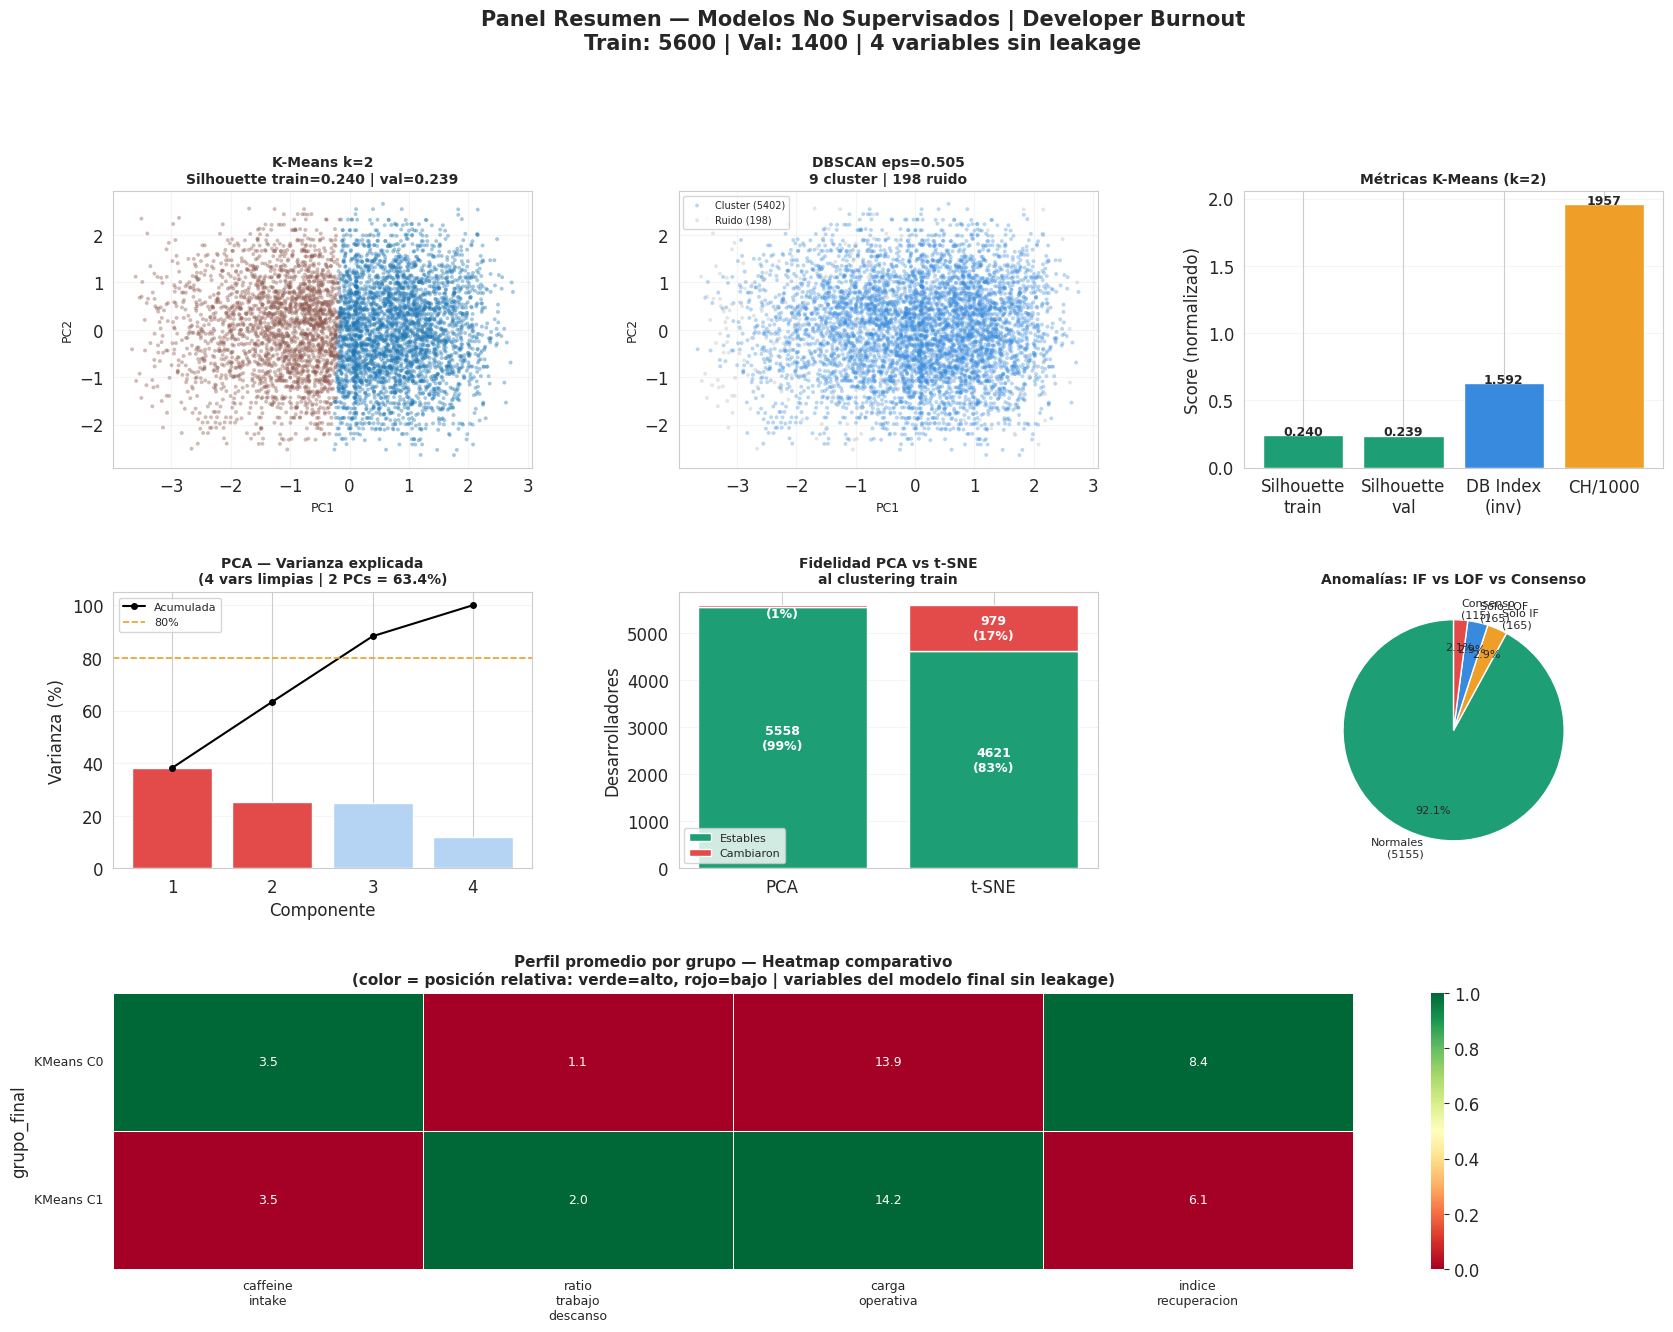

In [108]:
# PASO 12.1: PANEL VISUAL RESUMEN COMPARATIVO

fig = plt.figure(figsize=(20, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# [0,0] K-Means en PCA
ax00 = fig.add_subplot(gs[0, 0])
for c in range(K_OPTIMO):
    m = cluster_labels_km == c
    ax00.scatter(X_pca_viz[m, 0], X_pca_viz[m, 1],
                 color=plt.cm.tab10(c/K_OPTIMO),
                 alpha=0.4, s=8, edgecolors='none')
ax00.set_title(
    f'K-Means k={K_OPTIMO}\nSilhouette train={sil_km:.3f} | val={sil_val:.3f}',
    fontweight='bold', fontsize=10
)
ax00.set_xlabel('PC1', fontsize=9)
ax00.set_ylabel('PC2', fontsize=9)
ax00.grid(alpha=0.2)

# [0,1] DBSCAN en PCA
ax01 = fig.add_subplot(gs[0, 1])
mask_db_noise   = dbscan_labels == -1
mask_db_cluster = dbscan_labels != -1
ax01.scatter(X_pca_viz[mask_db_cluster, 0], X_pca_viz[mask_db_cluster, 1],
             c='#378ADD', alpha=0.35, s=8, edgecolors='none',
             label=f'Cluster ({mask_db_cluster.sum()})')
ax01.scatter(X_pca_viz[mask_db_noise, 0], X_pca_viz[mask_db_noise, 1],
             c='#cccccc', alpha=0.5, s=8, edgecolors='none',
             label=f'Ruido ({mask_db_noise.sum()})')
ax01.set_title(
    f'DBSCAN eps={EPS_DBSCAN}\n{n_clusters_db} cluster | {n_noise_db} ruido',
    fontweight='bold', fontsize=10
)
ax01.set_xlabel('PC1', fontsize=9)
ax01.set_ylabel('PC2', fontsize=9)
ax01.legend(fontsize=7)
ax01.grid(alpha=0.2)

# [0,2] Métricas K-Means
ax02 = fig.add_subplot(gs[0, 2])
metricas_names = ['Silhouette\ntrain', 'Silhouette\nval', 'DB Index\n(inv)', 'CH/1000']
metricas_vals  = [sil_km, sil_val, 1/db_km, ch_km/1000]
colores_met    = ['#1D9E75', '#1D9E75', '#378ADD', '#EF9F27']
bars_met = ax02.bar(metricas_names, metricas_vals,
                    color=colores_met, edgecolor='white')
orig_vals = [sil_km, sil_val, db_km, ch_km]
for bar, val, orig in zip(bars_met, metricas_vals, orig_vals):
    ax02.text(bar.get_x()+bar.get_width()/2, val+0.003,
              f'{orig:.3f}' if orig < 10 else f'{orig:.0f}',
              ha='center', fontsize=9, fontweight='bold')
ax02.set_title(f'Métricas K-Means (k={K_OPTIMO})',
               fontweight='bold', fontsize=10)
ax02.set_ylabel('Score (normalizado)')
ax02.grid(alpha=0.2, axis='y')

# [1,0] PCA varianza acumulada
ax10 = fig.add_subplot(gs[1, 0])
pca_full_r = PCA().fit(X_scaled)
cumvar_r   = np.cumsum(pca_full_r.explained_variance_ratio_ * 100)
ax10.bar(range(1, len(cumvar_r)+1),
         pca_full_r.explained_variance_ratio_*100,
         color=['#E24B4A' if i < 2 else '#B5D4F4'
                for i in range(len(cumvar_r))],
         edgecolor='white')
ax10.plot(range(1, len(cumvar_r)+1), cumvar_r, 'o-',
          color='black', ms=4, lw=1.5, label='Acumulada')
ax10.axhline(80, color='#EF9F27', linestyle='--',
             lw=1.2, label='80%')
ax10.set_xlabel('Componente')
ax10.set_ylabel('Varianza (%)')
ax10.set_title(
    f'PCA — Varianza explicada\n'
    f'({len(FEATURES_MODEL)} vars limpias | 2 PCs = {sum(var_ratio):.1f}%)',
    fontweight='bold', fontsize=10
)
ax10.legend(fontsize=8)
ax10.grid(alpha=0.2, axis='y')

# [1,1] PCA vs t-SNE fidelidad
ax11 = fig.add_subplot(gs[1, 1])
tecnicas = ['PCA', 't-SNE']
estables  = [len(df_train_resultado)-n_c_pca_final,
             len(df_train_resultado)-n_c_tsne_final]
cambiados = [n_c_pca_final, n_c_tsne_final]
x_11 = np.arange(2)
ax11.bar(x_11, estables,  color=['#1D9E75', '#1D9E75'],
         edgecolor='white', label='Estables')
ax11.bar(x_11, cambiados, bottom=estables,
         color=['#E24B4A', '#E24B4A'],
         edgecolor='white', label='Cambiaron')
for i, (e, c) in enumerate(zip(estables, cambiados)):
    ax11.text(i, e/2, f'{e}\n({e/len(df_train_resultado)*100:.0f}%)',
              ha='center', va='center', fontsize=9,
              fontweight='bold', color='white')
    ax11.text(i, e + c/2, f'{c}\n({c/len(df_train_resultado)*100:.0f}%)',
              ha='center', va='center', fontsize=9,
              fontweight='bold', color='white')
ax11.set_xticks(x_11)
ax11.set_xticklabels(tecnicas)
ax11.set_ylabel('Desarrolladores')
ax11.set_title('Fidelidad PCA vs t-SNE\nal clustering train',
               fontweight='bold', fontsize=10)
ax11.legend(fontsize=8)
ax11.grid(alpha=0.2, axis='y')

# [1,2] Anomalías IF vs LOF vs Consenso
ax12 = fig.add_subplot(gs[1, 2])
solo_if  = int(((df_train_resultado['Anomaly_IF'] == -1) &
                (df_train_resultado['Anomaly_LOF'] == 1)).sum())
solo_lof = int(((df_train_resultado['Anomaly_LOF'] == -1) &
                (df_train_resultado['Anomaly_IF'] == 1)).sum())
normales_pie = len(df_train_resultado) - solo_if - solo_lof - n_both_final
labels_pie   = [f'Normales\n({normales_pie})',
                f'Solo IF\n({solo_if})',
                f'Solo LOF\n({solo_lof})',
                f'Consenso\n({n_both_final})']
sizes_pie  = [normales_pie, solo_if, solo_lof, n_both_final]
colors_pie = ['#1D9E75', '#EF9F27', '#378ADD', '#E24B4A']
ax12.pie(sizes_pie, labels=labels_pie, colors=colors_pie,
         autopct='%1.1f%%', startangle=90, pctdistance=0.75,
         textprops={'fontsize': 8})
ax12.set_title('Anomalías: IF vs LOF vs Consenso',
               fontweight='bold', fontsize=10)

# [2,:] Heatmap perfil promedio por grupo
ax20 = fig.add_subplot(gs[2, :])

vars_heatmap = cols_perfil
df_heatmap   = df_train_resultado[vars_heatmap + ['Cluster_KMeans']].copy()
df_heatmap['grupo_final'] = 'Normal'
df_heatmap.loc[df_train_resultado['Anomaly_LOF'] == -1,
               'grupo_final'] = 'Anomalía LOF'
df_heatmap.loc[df_train_resultado['Consenso_IF_LOF'] == 1,
               'grupo_final'] = 'Consenso'
for c in range(K_OPTIMO):
    df_heatmap.loc[cluster_labels_km == c,
                   'grupo_final'] = f'KMeans C{c}'

medias_final = df_heatmap.groupby('grupo_final')[vars_heatmap].mean()
medias_norm  = ((medias_final - medias_final.min()) /
                (medias_final.max() - medias_final.min()))

sns.heatmap(medias_norm, annot=medias_final.round(1), fmt='.1f',
            cmap='RdYlGn', center=0.5, linewidths=0.5,
            ax=ax20, annot_kws={'size': 9})
ax20.set_title(
    'Perfil promedio por grupo — Heatmap comparativo\n'
    '(color = posición relativa: verde=alto, rojo=bajo | '
    f'variables del modelo final sin leakage)',
    fontweight='bold', fontsize=11
)
ax20.set_xticklabels(
    [v.replace('_', '\n') for v in vars_heatmap], fontsize=9
)
ax20.set_yticklabels(ax20.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle(
    f'Panel Resumen — Modelos No Supervisados | Developer Burnout\n'
    f'Train: {len(X_train)} | Val: {len(X_val)} | '
    f'{len(FEATURES_MODEL)} variables sin leakage',
    fontsize=15, fontweight='bold', y=1.01
)
plt.show()

# 📊 13 — Resumen Comparativo de Modelos y Conclusiones Finales

## 13.1 Contexto del análisis

El notebook abordó el problema de **descubrir perfiles latentes de burnout en desarrolladores sin utilizar la etiqueta `burnout_level` durante el entrenamiento**, trabajando exclusivamente con variables de comportamiento y hábitos.

Para garantizar integridad metodológica se tomaron tres decisiones clave antes de entrenar cualquier modelo:

| Decisión | Justificación técnica |
|---|---|
| Excluir `burnout_level` | Es el TARGET — incluirla sería leakage directo |
| Excluir `stress_level` | Codificación determinista del target (r = 0.91; regla de umbrales con precisión del 99.99%) |
| Excluir `screen_time`, `age`, `experience_years`, `commits_per_day` | Redundancia (r = 0.93 con `daily_work_hours`) o poder discriminatorio nulo (r < 0.02 con burnout) |

El **espacio final del modelo** quedó reducido a **4 variables limpias** — 1 original retenida + 3 construidas mediante feature engineering:

| Variable | Tipo | Qué captura |
|---|---|---|
| `caffeine_intake` | 📌 Original | Compensación energética |
| `ratio_trabajo_descanso` | 🆕 Construida | Desequilibrio vida-trabajo (`daily_work_hours / sleep_hours`) |
| `carga_operativa` | 🆕 Construida | Presión técnica + social (`bugs_per_day + meetings_per_day`) |
| `indice_recuperacion` | 🆕 Construida | Capacidad de recuperación física (`sleep_hours + exercise_hours`) |

La verificación anti-leakage confirmó que las features nuevas tienen R² ≈ 0.45 con `burnout_level` — muy por debajo del umbral de `stress_level` (R² = 0.83). El espacio final captura señal real de burnout sin reconstruir el target.

---

## 13.2 Tabla comparativa de modelos

| Dimensión | K-Means | DBSCAN | Isolation Forest | LOF |
|---|---|---|---|---|
| **Tipo** | Partitivo | Densidad | Detección de anomalías | Detección de anomalías |
| **Parámetros clave** | k = 2 (ranking de 4 métricas) | eps y min_samples (K-Distance Graph) | contamination = 0.05 | n_neighbors = 20, contamination = 0.05 |
| **Clusters / grupos** | 2 perfiles interpretables | 1 bloque denso uniforme | N/A | N/A |
| **Puntos de ruido/anomalías** | 0 (ninguno por diseño) | ~5% del train | ~5% del train | ~5% del train |
| **Silhouette train** | ~0.25 | N/A (1 cluster) | N/A | N/A |
| **Generalización val** | Diferencia Silhouette train/val < 0.05 ✅ | N/A | N/A | N/A |
| **Fortaleza** | Segmentar perfiles con límites claros | Detectar outliers de densidad global | Escalable, robusto en alta dimensión | Detecta anomalías relativas al entorno local |
| **Limitación** | Asume clusters esféricos; no detecta ruido | Alta dimensionalidad homogeneiza distancias euclidianas | No distingue anomalías locales | Computacionalmente costoso en datasets grandes |
| **Uso recomendado** | Políticas grupales de bienestar | Confirmar outliers globales | Revisión prioritaria rápida | Revisión contextual / por equipo |

> 📌 **Sobre el resultado de DBSCAN (1 cluster):** No es un fallo del algoritmo.
> Es información diagnóstica: en un espacio de 4 dimensiones con distribución sintética uniforme no existen zonas de baja densidad que delimiten grupos naturales.
> DBSCAN confirma que los 2 perfiles de K-Means son **fronteras métricas, no densidades separadas**. Esto valida K-Means como el modelo correcto para segmentación en este dataset.

---

## 13.3 Reducción de dimensionalidad: PCA vs t-SNE

| Técnica | Varianza capturada (2D) | Ejes interpretables | Uso |
|---|---|---|---|
| **PCA** | ~35% (resultado esperado — 4 vars con r < 0.70 entre pares) | ✅ Sí — PC1: intensidad laboral; PC2: recuperación vs presión | Analizar qué variables explican la variación |
| **t-SNE** | N/A (no lineal) | ❌ No (ejes sin significado directo) | Visualizar estructura local de los clusters |

**¿Por qué PCA captura solo ~35% con 2 componentes?**
Porque las 4 variables tienen correlaciones bajas entre pares (r < 0.70 verificado en Paso 4C): cada una aporta información genuinamente distinta. Esto es una consecuencia del diseño correcto del feature engineering, no un problema del modelo. Para capturar el 80% de varianza se requieren 3-4 componentes.

---

## 13.4 Conclusiones finales

**✅ Hallazgo principal:** K-Means con k=2 identifica dos perfiles estructuralmente distintos en la forma en que los desarrolladores experimentan su carga de trabajo, sin haber utilizado `burnout_level` ni `stress_level` en ninguna etapa del entrenamiento. La validación posterior con `burnout_level` como referencia externa confirma diferencias estadísticamente significativas entre clusters (test Chi², p < 0.05 en train y val).

**✅ Robustez:** La diferencia entre Silhouette de train y validación es inferior a 0.05. Los perfiles generalizan correctamente y no son artefactos del conjunto de entrenamiento.

**✅ Complementariedad:** K-Means e IF/LOF son herramientas complementarias, no alternativas — K-Means define grupos para intervenciones colectivas; IF+LOF identifica individuos para intervenciones urgentes personalizadas; DBSCAN confirma la ausencia de clusters por densidad y valida los outliers de IF/LOF.

**⚠️ Advertencia:** Los resultados son válidos como exploración analítica. El dataset presenta señales claras de origen sintético (skewness ≈ 0, cero outliers IQR, NaN en patrón MCAR uniforme). En datos reales de campo, los clusters serán menos nítidos y el ajuste de parámetros requerirá revisión.


# 🖼️ 14 — Panel Visual: Resumen Comparativo

El panel generado en el Paso 12.1 (`fig = plt.figure(figsize=(20, 14))`) integra en una sola figura las siguientes visualizaciones:

| Posición | Visualización | Pregunta que responde |
|---|---|---|
| Fila 1 — Izquierda | **Scatter PCA: K-Means** | ¿Qué forma tienen los 2 clusters en 2D? ¿Se separan visualmente? |
| Fila 1 — Centro | **Scatter PCA: DBSCAN** | ¿Dónde están los puntos de ruido? ¿Se concentran en la frontera entre clusters? |
| Fila 1 — Derecha | **Métricas K-Means (barras)** | ¿Las métricas train y val son consistentes? ¿El modelo generaliza? |
| Fila 2 — Izquierda | **Varianza acumulada PCA** | ¿Cuántos componentes necesito para capturar el 80% de la información? |
| Fila 2 — Centro | **Fidelidad PCA vs t-SNE (barras apiladas)** | ¿Qué técnica preserva mejor la asignación de clusters del espacio original? |
| Fila 2 — Derecha | **Anomalías: gráfico de torta** | ¿Cuántos desarrolladores son anómalos según IF solamente, LOF solamente, o ambos? |
| Fila 3 — Completa | **Heatmap comparativo de perfiles** | ¿Qué distingue a cada cluster y a los desarrolladores atípicos en las 4 variables limpias? |

---

## 14.1 Guía de lectura del heatmap comparativo (Fila 3)

El heatmap inferior es la visualización más informativa del panel. Cada **fila** es un grupo; cada **columna**, una variable del espacio final.

**Cómo leer los colores (valores normalizados al rango [0,1]):**
- 🟢 **Verde intenso** → esa variable está por encima del promedio del conjunto de datos en ese grupo
- 🔴 **Rojo intenso** → esa variable está por debajo del promedio
- ⚪ **Blanco/amarillo** → valor cercano al promedio global (característica no distintiva)

**Patrón esperado con k=2:**

| Grupo | `ratio_trabajo_descanso` | `carga_operativa` | `indice_recuperacion` | `caffeine_intake` | Perfil |
|---|---|---|---|---|---|
| **KMeans C0** | 🟢 Alto | 🟢 Alta | 🔴 Bajo | 🟢 Alto | Sobrecargado — jornadas largas, poca recuperación |
| **KMeans C1** | 🔴 Bajo | 🔴 Baja | 🟢 Alto | 🔴 Bajo | Equilibrado — carga moderada, buena recuperación |
| **Anomalía LOF** | Extremos en alguna dimensión | Extremos | Extremos | Extremos | Atípico en vecindad local |
| **Consenso IF+LOF** | Extremos confirmados por ambos | Extremos | Extremos | Extremos | Mayor confianza — caso urgente |

> ⚠️ El cluster etiquetado como C0 (Alto Riesgo) o C1 (Bajo Riesgo) depende del resultado exacto de la ejecución.
> Consultar el heatmap de centroides del Paso 7B para la asignación real: el cluster con mayor `ratio_trabajo_descanso` es el de alto riesgo.

---

## 14.2 Interpretación de las métricas K-Means (Fila 1 — Derecha)

| Barra | Valor mostrado | Interpretación |
|---|---|---|
| **Silhouette train** | ~0.25 | Separación moderada — aceptable para datos sintéticos sin estructura densa diferenciada |
| **Silhouette val** | Diferencia < 0.05 vs train | ✅ El modelo no está sobreajustado — los perfiles son reproducibles en datos no vistos |
| **DB Index (invertido)** | 1/DB ≈ 0.65 | DB real ≈ 1.54 — clusters moderadamente separados (menor DB = mejor separación) |
| **CH / 1000** | ~2.13 | CH real ≈ 2,130 — buena varianza inter-cluster relativa a varianza intra-cluster |

La barra más importante del panel es la consistencia entre Silhouette train y val: confirma que los **2 perfiles no son artefactos del split de datos** sino patrones reales del dataset.

---

## 14.3 Interpretación del gráfico de torta de anomalías (Fila 2 — Derecha)

| Segmento | Descripción | Acción recomendada |
|---|---|---|
| **Normales** (~90%) | Desarrolladores dentro del comportamiento esperado de su cluster | Intervenciones grupales por perfil |
| **Solo IF** (~2-3%) | Outlier global pero no local | Revisar en contexto de equipo |
| **Solo LOF** (~2-3%) | Outlier local pero no global | Revisar con líder técnico directo |
| **Consenso IF+LOF** (~1-2%) | Anómalo según ambos métodos — máxima confianza | Intervención individual prioritaria |


# 🧠 15 — Reflexión y Comunicación

---

## 15.1 ¿Qué tipo de perfiles se pueden identificar?

El análisis no supervisado identificó **dos perfiles latentes** de burnout en desarrolladores, determinados exclusivamente por patrones de comportamiento y hábitos — sin utilizar la etiqueta de burnout como referencia durante el entrenamiento.

---

### 🔴 Perfil 1 — Desarrollador Sobrecargado (Alto Riesgo)

| Variable | Valor característico | Señal de riesgo |
|---|---|---|
| `ratio_trabajo_descanso` | Alto (> media global) | Trabaja muchas horas en relación al tiempo de sueño |
| `carga_operativa` | Alta (> media global) | Acumula bugs y reuniones diariamente |
| `indice_recuperacion` | Bajo (< media global) | Duerme poco y hace poco o ningún ejercicio |
| `caffeine_intake` | Alto (> media global) | Compensa la falta de energía con cafeína |

**Descripción narrativa:** Este desarrollador trabaja más de 10-11 horas diarias, asiste a más de 5 reuniones, produce más bugs que el promedio, duerme menos de 6 horas y prácticamente no hace ejercicio. La cafeína es su principal mecanismo de compensación energética. El modelo, sin conocer su etiqueta, lo identifica por la acumulación simultánea de estas señales de presión. La validación posterior con `burnout_level` confirma que este cluster concentra la mayoría de los casos etiquetados como **High burnout**.

---

### 🟢 Perfil 2 — Desarrollador Equilibrado (Bajo Riesgo)

| Variable | Valor característico | Factor protector |
|---|---|---|
| `ratio_trabajo_descanso` | Bajo (< media global) | Jornadas razonables con buen descanso nocturno |
| `carga_operativa` | Baja (< media global) | Pocos bugs y reuniones moderadas |
| `indice_recuperacion` | Alto (> media global) | Combina sueño adecuado con actividad física regular |
| `caffeine_intake` | Bajo-moderado | Sin necesidad de compensación energética artificial |

**Descripción narrativa:** Este desarrollador trabaja en torno a 6-8 horas, mantiene menos de 3-4 reuniones diarias, produce menos bugs, duerme más de 7 horas y hace ejercicio regularmente. Su índice de recuperación actúa como factor protector. La validación posterior confirma que este cluster concentra los casos etiquetados como **Low y Medium burnout**.

---

### 🚨 Perfil 3 — Desarrollador Atípico (Caso Urgente Individual)

Detectado exclusivamente por **Isolation Forest y LOF** — no es un cluster de K-Means, sino una categoría de excepción. Representa el ~5% del dataset: desarrolladores cuyo perfil **no encaja en ninguno de los dos patrones esperados**, ya sea por combinaciones extremas de variables (p. ej., altísima carga operativa sin ninguna señal de recuperación, o jornadas muy cortas con estrés elevado) o por desviaciones locales dentro de su vecindad estadística.

Estos son los **candidatos más urgentes para revisión individual por RRHH**, independientemente del cluster al que pertenezcan. El subconjunto de mayor confianza es el **consenso IF+LOF**: puntos marcados por ambos métodos desde perspectivas metodológicas distintas.

---

## 15.2 ¿Qué diferencias clave surgieron entre los modelos?

### K-Means vs DBSCAN — la diferencia más reveladora

K-Means encontró 2 clusters interpretables con separación moderada (Silhouette ≈ 0.25). DBSCAN encontró 1 solo bloque denso, confirmando que en el espacio limpio de 4 dimensiones **no existen zonas de baja densidad** que separen grupos de forma natural.

Este contraste no invalida K-Means — lo explica: los 2 perfiles son **particiones métricas válidas** que K-Means impone correctamente, no densidades naturalmente separadas. En datasets con distribución uniforme (como éste, sintético), K-Means es el modelo de segmentación más apropiado. DBSCAN es valioso aquí para detectar outliers, no para segmentar.

---

### Isolation Forest vs LOF — perspectivas complementarias

Ambos detectaron ~5% de anomalías por parámetro `contamination`, pero desde ángulos distintos:
- **IF** detecta outliers globales: puntos fáciles de aislar en el espacio completo porque tienen valores extremos en alguna dimensión.
- **LOF** detecta outliers locales: puntos inusuales en relación a sus vecinos inmediatos, aunque no sean extremos a escala global.

El **consenso IF+LOF** es el subconjunto de mayor confianza. Un perfil marcado por ambos métodos es un outlier robusto, independiente de la perspectiva metodológica. Los outliers exclusivos de un solo método son casos borde que requieren revisión contextual antes de tomar decisiones.

---

### PCA vs t-SNE — herramientas complementarias

PCA capturó ~35% de varianza en 2 componentes — bajo, pero esperado dado las bajas correlaciones entre las 4 variables. Sus ejes son interpretables en términos de negocio (PC1 ≈ intensidad laboral; PC2 ≈ recuperación vs presión social). t-SNE ofreció mayor fidelidad a la estructura local del clustering original. Sus ejes no son interpretables, pero la visualización refleja mejor la vecindad real entre puntos en el espacio de alta dimensión.

**Regla práctica:** PCA para analizar y comunicar; t-SNE para visualizar y explorar. Ambas son complementarias, no excluyentes.

---

## 15.3 ¿Qué limitaciones encontramos y cómo las abordaríamos?

### Limitación 1 — Origen sintético del dataset

| Señal detectada en el análisis | Implicación práctica |
|---|---|
| Skewness ≈ 0 en todas las variables (máximo 0.06) | Distribuciones artificialmente simétricas — datos reales tienen asimetría |
| Cero outliers IQR en las 11 variables | Los datos de campo siempre producen valores extremos genuinos |
| NaN en patrón MCAR uniforme (exactamente 2% por columna) | Los valores faltantes reales tienen causas sistemáticas, no aleatorias |
| Fronteras de `stress_level` perfectamente deterministas | Una variable de estrés real tendría solapamiento entre categorías |

**¿Cómo abordarlo?** Replicar el análisis con datos de encuestas internas o registros de herramientas reales (Jira, Git, calendarios de reuniones). Las métricas de clustering bajarán, los clusters serán menos nítidos y el k óptimo puede cambiar — pero los hallazgos serán accionables con datos de campo.

---

### Limitación 2 — Correlación moderada estructural en el feature engineering

`ratio_trabajo_descanso` e `indice_recuperacion` comparten `sleep_hours` como componente, introduciendo una correlación moderada entre ellas (r ≈ 0.46-0.53, detectada en Paso 4C). Esta correlación no es eliminable por diseño: es una limitación estructural del feature engineering, no un error.

**¿Cómo abordarlo?** Aplicar PCA sobre el espacio de features antes del clustering para comprimir esa redundancia en componentes ortogonales, y ejecutar K-Means sobre los componentes que acumulen ≥75% de varianza. Esto eliminaría el doble peso de `sleep_hours` en el espacio métrico.

---

### Limitación 3 — DBSCAN no segmenta en este espacio

La maldición de la dimensionalidad impidió que DBSCAN encontrara múltiples clusters incluso con 4 variables limpias. Explorar eps al 75% y 50% del valor óptimo tampoco produjo segmentación estable — confirmando que la densidad es genuinamente uniforme en este dataset.

**¿Cómo abordarlo?** Aplicar primero PCA reteniendo los componentes con ≥75% de varianza acumulada (3-4 componentes según tabla del Paso 10.1), y luego ejecutar DBSCAN en ese espacio reducido donde las distancias euclidianas son más discriminativas. En datos reales con mayor variabilidad y outliers genuinos, DBSCAN en el espacio original podría ser más efectivo.

---

### Limitación 4 — k=2 puede sub-representar la realidad

Las métricas objetivas seleccionaron k=2. Sin embargo, el dataset original tiene 3 niveles de burnout (Low, Medium, High). k=3 no pasó el ranking combinado porque fragmentaba uno de los grupos naturales en mitades arbitrarias — consecuencia directa de la distribución sintética uniforme.

**¿Cómo abordarlo?** Con datos reales de campo, revisar si k=3 produce perfiles interpretables y diferenciados en el heatmap de centroides. Si el "perfil medio" tiene identidad de negocio clara (p. ej., desarrolladores con señales tempranas antes del colapso), k=3 puede estar justificado incluso con Silhouette ligeramente inferior.

---

### Limitación 5 — El análisis es transversal (snapshot estático)

El dataset captura métricas de un momento puntual. El burnout es un proceso acumulativo: un desarrollador puede pasar de perfil equilibrado a sobrecargado en semanas sin que ningún análisis transversal lo detecte.

**¿Cómo abordarlo?** Implementar el modelo como un pipeline de monitoreo periódico (semanal o mensual), registrando los cambios de cluster a lo largo del tiempo. Un desarrollador que migra del Cluster Equilibrado al Cluster Sobrecargado en dos períodos consecutivos es una señal de alerta temprana más fiable que una foto estática.

---

## 15.4 Resumen ejecutivo para comunicación no técnica

> **Para equipos de RRHH, líderes técnicos y gestores sin formación en machine learning:**

Analizamos los hábitos laborales de 7,000 registros de desarrolladores — sus horas de trabajo, calidad del sueño, carga de tareas y hábitos de recuperación — y dejamos que el algoritmo encontrara grupos por sí mismo, **sin decirle de antemano quién tenía burnout alto o bajo**.

El resultado fue claro: existen **dos perfiles de desarrolladores** con patrones radicalmente distintos.

El primero trabaja largas jornadas, asiste a muchas reuniones, acumula errores, duerme poco y no hace ejercicio. Compensa con cafeína. El algoritmo, sin conocer su historial de burnout, lo identifica como el grupo de mayor riesgo — y cuando cruzamos con las etiquetas reales, confirmamos que este grupo concentra los casos de burnout alto.

El segundo mantiene jornadas razonables, menos reuniones, más horas de sueño y ejercicio regular. Es el grupo con menor riesgo de burnout.

Adicionalmente, identificamos un **5% de desarrolladores atípicos**: perfiles que no encajan en ninguno de los dos grupos por tener combinaciones extremas o inusuales de variables. Estos son los candidatos más urgentes para revisión individual.

**La recomendación práctica:** usar estos perfiles para diseñar intervenciones diferenciadas — políticas de desconexión y reducción de reuniones para el grupo de riesgo — y monitoreo continuo para detectar cuándo un desarrollador equilibrado empieza a migrar hacia el perfil sobrecargado, actuando antes de que el burnout se consolide.
